In [10]:
# ─────────────────────────────────────────────────────────────
# STANDARD IMPORT BLOCK
# Run this cell first at the start of every session
# ─────────────────────────────────────────────────────────────

# ── Data Manipulation ──────────────────────────────────────────
import pandas as pd          # pandas: loading, cleaning, and working with tabular data
import numpy as np           # numpy: numerical operations, arrays, and math

# ── Statistical Analysis ───────────────────────────────────────
import scipy.stats as stats  # scipy.stats: Z-scores, normality tests, statistical functions
import statsmodels.api as sm # statsmodels: detailed regression output with p-values and CIs

# ── Machine Learning (scikit-learn) ────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
    # LinearRegression: Models 1, 2, 3 (after polynomial features)
    # LogisticRegression: Model 6 (classification)

from sklearn.preprocessing import (
    PolynomialFeatures,   # Transforms features for polynomial regression (Model 3)
    LabelEncoder,         # Converts text categories to numbers (Step 3)
    StandardScaler,       # Standardizes features to mean=0, std=1 (Step 4)
    MinMaxScaler          # Normalizes features to a 0–1 range (Step 4)
)

from sklearn.tree import (
    DecisionTreeRegressor,  # Model 4: Decision Tree
    plot_tree               # Visualizes the decision tree structure
)

from sklearn.ensemble import RandomForestRegressor  # Model 5: Random Forest

from sklearn.model_selection import train_test_split, cross_val_score
    # train_test_split: Splits data into training and test sets
    # cross_val_score: Performs cross-validation for model reliability

from sklearn.metrics import (
    r2_score,                  # R² — how well the model explains variance
    mean_absolute_error,       # MAE — average size of prediction errors
    mean_squared_error,        # MSE — used to compute RMSE
    confusion_matrix,          # For evaluating the classification model
    classification_report,     # Precision, recall, F1 for classification
    accuracy_score             # Overall accuracy for classification
)

from sklearn.pipeline import Pipeline  # Chains steps together cleanly

# ── Data Loading ───────────────────────────────────────────────
import pyreadstat   # Reads SPSS .sav files into Python

# ── Visualization ──────────────────────────────────────────────
import matplotlib.pyplot as plt   # Base plotting library
import matplotlib.ticker as ticker
import seaborn as sns             # Statistical visualization (heatmaps, distributions, etc.)

# ── Display Settings ───────────────────────────────────────────
pd.set_option('display.max_columns', None)   # Show all columns (don't truncate wide DataFrames)
pd.set_option('display.float_format', '{:.4f}'.format)  # Show 4 decimal places for floats
%matplotlib inline  
plt.style.use('seaborn-v0_8')  # Clean, professional plot styling

print(" All libraries imported successfully!")



 All libraries imported successfully!
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [11]:
# ─────────────────────────────────────────────────────────────
# Load the Primary Dataset (CSV)
# ─────────────────────────────────────────────────────────────

# pd.read_csv() is pandas' function for reading comma-separated files
# We are passing it two things:
#   1. The file path (as a string) — adjust this to where YOUR file is saved
#   2. No extra parameters needed here — pandas auto-detects delimiters, headers, etc.

df = pd.read_csv("/Users/shivamthakkar/Desktop/DS Project/Data/ai_skepticism_dataset.csv")  
# 'df' stands for DataFrame — the standard variable name in data science
# A DataFrame is like a spreadsheet table: rows are observations, columns are variables

# Confirm it loaded correctly by printing a success message
print(f" Primary dataset loaded successfully!")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
# df.shape returns a tuple (rows, columns)
# df.shape[0] = number of rows, df.shape[1] = number of columns


 Primary dataset loaded successfully!
   Shape: 1000 rows × 23 columns


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 2: Load the Secondary Dataset (SPSS .sav)
# ─────────────────────────────────────────────────────────────

# pyreadstat.read_sav() reads SPSS binary files
# It returns TWO things at once (this is called tuple unpacking):
#   - df_sav: the actual data table (as a pandas DataFrame)
#   - meta:   metadata about the file (variable labels, value labels, etc.)
# We capture both using the syntax: df_sav, meta = ...

df_sav, meta = pyreadstat.read_sav("/Users/shivamthakkar/Desktop/DS Project/Data/Study 2 Data Syntax and Outputs/AI and Decision Making_FINAL_dataset.sav"
    # Again — adjust path if needed
)

# Immediately convert to a standard pandas DataFrame
# (pyreadstat already does this, but this line makes it explicit and clean)
df_sav = pd.DataFrame(df_sav)

print(f" Secondary dataset loaded successfully!")
print(f"   Shape: {df_sav.shape[0]} rows × {df_sav.shape[1]} columns")

# Let's also peek at what SPSS metadata was stored
# meta.column_names_to_labels is a dictionary: {column_name: label_description}
print(f"\n SPSS Variable Labels (first 10):")
for col, label in list(meta.column_names_to_labels.items())[:10]:
    print(f"   {col}: {label}")

 Secondary dataset loaded successfully!
   Shape: 521 rows × 158 columns

 SPSS Variable Labels (first 10):
   StartDate: Start Date
   EndDate: End Date
   IPAddress: IP Address
   Duration__in_seconds_: Duration (in seconds)
   RecordedDate: Recorded Date
   ResponseId: Response ID
   LocationLatitude: Location Latitude
   LocationLongitude: Location Longitude
   Q_RelevantIDDuplicate: Q_RelevantIDDuplicate
   Q_RelevantIDDuplicateScore: Q_RelevantIDDuplicateScore


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 3: View the first rows of each dataset
# ─────────────────────────────────────────────────────────────

# .head(n) shows the first n rows of your DataFrame
# Default is 5 rows if you don't pass a number
# This lets you visually confirm the data looks right

print("=" * 60)
print("PRIMARY DATASET — First 5 rows")
print("=" * 60)
display(df.head(5))
# display() is a Jupyter-specific function that renders DataFrames
# as a formatted HTML table (much prettier than plain print())

print("\n")
print("=" * 60)
print("SECONDARY DATASET — First 5 rows")
print("=" * 60)
display(df_sav.head(5))

PRIMARY DATASET — First 5 rows


,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,digital_literacy_score,ai_familiarity_level,decision_importance,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
0,Claude,math_calculation,93.2300,527,True,False,False,Moderate,45-54,Bachelors,Low,Intermediate,Low,Low,False,False,10.0000,True,Google Search,10.7000,80.1500,True,Moderate Trust
1,Llama,recipe_cooking,84.4700,581,False,False,False,Specific,55-64,PhD,Expert,First Time,High,NaN,False,True,7.9000,True,Asked Expert,44.3000,92.3300,True,Skeptical
2,Claude,general_knowledge,69.8200,484,True,True,False,Very Specific,35-44,High School,Medium,Intermediate,Critical,NaN,True,False,8.6000,True,Consulted Documentation,37.5000,67.3200,True,Moderate Trust
3,Claude,creative_writing,79.6100,73,True,True,False,Specific,45-54,Professional,Low,Advanced,High,NaN,NaN,False,8.9000,True,Checked Official Source,22.7000,73.1200,True,Moderate Trust
4,Claude,creative_writing,67.7100,146,False,True,False,Vague,55-64,Masters,Low,Expert,Low,NaN,True,True,9.0000,True,Academic Paper,43.7000,81.0500,True,Moderate Trust




SECONDARY DATASET — First 5 rows


,StartDate,EndDate,IPAddress,Duration__in_seconds_,RecordedDate,ResponseId,LocationLatitude,LocationLongitude,Q_RelevantIDDuplicate,Q_RelevantIDDuplicateScore,Q_RelevantIDLastStartDate,Sex,Age,Education,AI_use_experience,AITrust1,AITrust2,AITrust3,AITrust4,AITrust5,Task_Completion_Cont_1,Task_Completion_Cont_2,Task_Completion_Cont_3,Task_Completion_Cont_4,Task_Completion_Cont_5,Task_Completion_Cont_6,Task_Completion_Cont_7,Task_Completion_Cont_8,Task_Completion_Cont_9,Task_Completion_Cont_10,Task_Completion_Cont_11,Task_Completion_Cont_12,Task_Completion_Cont_13,Task_Completion_Cont_14,Task_Completion_Cont_15,Expertise1,Expertise2,Expertise3,Expertise4,Expertise4R,Complete_Again_Pos,Task_Completion_Pos_1,Task_Completion_Pos_2,Task_Completion_Pos_3,Task_Completion_Pos_4,Task_Completion_Pos_5,Task_Completion_Pos_6,Task_Completion_Pos_7,Task_Completion_Pos_8,Task_Completion_Pos_9,Task_Completion_Pos_10,Task_Completion_Pos_11,Task_Completion_Pos_12,Task_Completion_Pos_13,Task_Completion_Pos_14,Task_Completion_Pos_15,Complete_Again_Neg,Task_Completion_Neg_1,Task_Completion_Neg_2,Task_Completion_Neg_3,Task_Completion_Neg_4,Task_Completion_Neg_5,Task_Completion_Neg_6,Task_Completion_Neg_7,Task_Completion_Neg_8,Task_Completion_Neg_9,Task_Completion_Neg_10,Task_Completion_Neg_11,Task_Completion_Neg_12,Task_Completion_Neg_13,Task_Completion_Neg_14,Task_Completion_Neg_15,Motivation,Reasons_why_not_1,Reasons_why_not_2,Reasons_why_not_3,Reasons_why_not_4,Reasons_why_not_4_TEXT,Reasons_Why_1,Reasons_Why_2,Reasons_Why_4,Reasons_Why_8,Reasons_Why_9,Reasons_Why_10,Reasons_Why_10_TEXT,Use_of_ChatGPT,SC0,age.0,educationScore,Matches,Pistols,Milk,Binoculars,Compass,Silk,Heating,LifeRaft,Multitool,Flares,Food,Rope,StellarMap,FirstAidKit,FMReceiver,MatchesP,PistolsP,MilkP,BinocularsP,CompassP,SilkP,HeatingP,LifeRaftP,MultitoolP,FlaresP,FoodP,RopeP,StellarMapP,FirstAidKitP,FMReceiverP,MatchesN,PistolsN,MilkN,BinocularsN,CompassN,SilkN,HeatingN,LifeRaftN,MultitoolN,FlaresN,FoodN,RopeN,StellarMapN,FirstAidKitN,FMReceiverN,LunarScorePre,LunarScorePos,LunarScoreNeg,LunarScorePosttask,Female,CollegeDegree,EducationRecode4Level,AITrust,PerceivedExpertise,AnomalyIndex,Q_RecaptchaScore,AveDevExpertise,ProblematicCase,AI_Recommendations,CompleteAgain,LunarScoreFinal,filter_$,ConditionRevision,UseofAIInput,AITrustMC,ExpertiseMC,AITrustxCondition,ExpertisexCondition,AITrustxExpertise
0,2025-04-23 13:01:28,2025-04-23 13:12:19,73.10.104.201,650.0000,2025-04-23 13:12:20,R_1IjqSJSULFsDHA5,40.8022,-74.1914,,0.0000,1582-10-14 00:00:00,2.0000,3.0000,5.0000,2.0000,4.0000,4.0000,4.0000,4.0000,4.0000,NaN,1.0000,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,1.0000,3.0000,3.0000,3.0000,3.0000,3.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0000,1.0000,1.0000,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,59.0000,38,5,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,0.0000,0.0000,2.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,0.0000,0.0000,0.0000,1.0000,1.0000,3.0000,4.0000,3.0000,0.9717,1.0000,0.0000,0.0000,0.0000,0.0000,8.0000,NaN,4.0000,NaN,0.7781,0.0734,0.0000,0.0000,0.0571
1,2025-04-23 09:31:03,2025-04-23 09:33:50,108.14.3.58,166.0000,2025-04-23 09:33:50,R_5rpKpCcxWEXvt2V,40.6208,-74.0426,,0.0000,1582-10-14 00:00:00,1.0000,2.0000,3.0000,2.0000,4.0000,4.0000,4.0000,4.0000,4.0000,NaN,1.0000,1.0000,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,4.0000,4.0000,3.0000,2.0000,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0000,1.0000,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,56.0000,34,2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,2.0000,2.0000,0.0

In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 4: Understand the structure of both datasets
# ─────────────────────────────────────────────────────────────

# ── PRIMARY DATASET ──────────────────────────────────────────
print("=" * 60)
print("PRIMARY DATASET — Structure")
print("=" * 60)

print(f"\n Shape: {df.shape}")
# Returns (rows, columns) — confirms we have exactly what we expect

print(f"\n Column names:")
print(df.columns.tolist())
# .columns gives you the column index object
# .tolist() converts it to a plain Python list — easier to read

print(f"\n Data types and non-null counts (.info()):")
df.info()
# .info() is a very powerful method — it tells you ALL of the following at once:
#   - Total number of rows
#   - Each column name
#   - How many NON-NULL (non-missing) values each column has
#   - The data type (dtype) of each column: int64, float64, object, bool
#   - Total memory usage
# KEY INSIGHT: If a column has fewer non-null values than total rows → missing data!

print("\n")

# ── SECONDARY DATASET ─────────────────────────────────────────
print("=" * 60)
print("SECONDARY DATASET — Structure")
print("=" * 60)

print(f"\n Shape: {df_sav.shape}")
print(f"\n Column names:")
print(df_sav.columns.tolist())
print(f"\n Data types and non-null counts (.info()):")
df_sav.info()

PRIMARY DATASET — Structure

 Shape: (1000, 23)

 Column names:
['ai_model_name', 'query_category', 'ai_confidence_percentage', 'response_character_count', 'has_cited_sources', 'contains_hedging_words', 'includes_disclaimer', 'answer_detail_level', 'respondent_age_bracket', 'education_level', 'digital_literacy_score', 'ai_familiarity_level', 'decision_importance', 'urgency_level', 'belief_alignment_status', 'subject_matter_expertise', 'trust_score_out_of_10', 'performed_fact_check', 'fact_check_method_used', 'verification_duration_mins', 'answer_accuracy_percentage', 'trust_calibration_valid', 'user_skepticism_category']

 Data types and non-null counts (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ai_model_name               1000 non-null   object 
 1   query_category              1000 non-null   o

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 5: Summary statistics for numeric columns
# ─────────────────────────────────────────────────────────────

# .describe() automatically computes summary stats for every NUMERIC column
# It gives you: count, mean, std, min, 25th percentile, median, 75th percentile, max

print("=" * 60)
print("PRIMARY DATASET — Descriptive Statistics")
print("=" * 60)
display(df.describe())

# To also include non-numeric (object/bool) columns, use include='all'
print("\n Including categorical columns:")
display(df.describe(include='all'))
# For text columns, instead of mean/std it shows:
#   count = how many non-null values
#   unique = how many distinct categories
#   top = the most frequent value
#   freq = how many times the most frequent value appears

print("\n")
print("=" * 60)
print("SECONDARY DATASET — Descriptive Statistics")
print("=" * 60)
display(df_sav.describe())

PRIMARY DATASET — Descriptive Statistics


,ai_confidence_percentage,response_character_count,trust_score_out_of_10,verification_duration_mins,answer_accuracy_percentage
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,72.0068,429.0220,7.9050,14.8400,69.9820
std,14.6633,221.6449,1.7669,15.1823,18.1768
min,40.5200,50.0000,1.8000,0.0000,19.4200
25%,60.5700,239.5000,6.7000,0.0000,58.5700
50%,74.2350,423.0000,8.2000,11.0500,72.0800
75%,83.8625,629.0000,9.5000,28.2000,83.1400
max,98.6600,799.0000,10.0000,45.0000,100.0000



 Including categorical columns:


,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,digital_literacy_score,ai_familiarity_level,decision_importance,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
count,1000,1000,1000.0000,1000.0000,1000,1000,1000,1000,1000,1000,1000,1000,1000,779,658,1000,1000.0000,1000,628,1000.0000,1000.0000,1000,1000
unique,6,12,NaN,NaN,2,2,2,4,6,5,4,5,4,3,2,2,NaN,2,8,NaN,NaN,2,4
top,Gemini,recipe_cooking,NaN,NaN,True,True,True,Moderate,35-44,PhD,Low,Beginner,High,Medium,True,False,NaN,True,Asked Colleague,NaN,NaN,True,Moderate Trust
freq,190,101,NaN,NaN,525,512,509,261,195,218,259,218,264,266,337,518,NaN,628,92,NaN,NaN,727,366
mean,NaN,NaN,72.0068,429.0220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.9050,NaN,NaN,14.8400,69.9820,NaN,NaN
std,NaN,NaN,14.6633,221.6449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7669,NaN,NaN,15.1823,18.1768,NaN,NaN
min,NaN,NaN,40.5200,50.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.8000,NaN,NaN,0.0000,19.4200,NaN,NaN
25%,NaN,NaN,60.5700,239.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.7000,NaN,NaN,0.0000,58.5700,NaN,NaN
50%,NaN,NaN,74.2350,423.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.2000,NaN,NaN,11.0500,72.0800,NaN,NaN
75%,NaN,NaN,83.8625,629.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.5000,NaN,NaN,28.2000,83.1400,NaN,NaN




SECONDARY DATASET — Descriptive Statistics


,StartDate,EndDate,Duration__in_seconds_,RecordedDate,Q_RelevantIDDuplicateScore,Sex,Age,Education,AI_use_experience,AITrust1,AITrust2,AITrust3,AITrust4,AITrust5,Task_Completion_Cont_1,Task_Completion_Cont_2,Task_Completion_Cont_3,Task_Completion_Cont_4,Task_Completion_Cont_5,Task_Completion_Cont_6,Task_Completion_Cont_7,Task_Completion_Cont_8,Task_Completion_Cont_9,Task_Completion_Cont_10,Task_Completion_Cont_11,Task_Completion_Cont_12,Task_Completion_Cont_13,Task_Completion_Cont_14,Task_Completion_Cont_15,Expertise1,Expertise2,Expertise3,Expertise4,Expertise4R,Complete_Again_Pos,Task_Completion_Pos_1,Task_Completion_Pos_2,Task_Completion_Pos_3,Task_Completion_Pos_4,Task_Completion_Pos_5,Task_Completion_Pos_6,Task_Completion_Pos_7,Task_Completion_Pos_8,Task_Completion_Pos_9,Task_Completion_Pos_10,Task_Completion_Pos_11,Task_Completion_Pos_12,Task_Completion_Pos_13,Task_Completion_Pos_14,Task_Completion_Pos_15,Complete_Again_Neg,Task_Completion_Neg_1,Task_Completion_Neg_2,Task_Completion_Neg_3,Task_Completion_Neg_4,Task_Completion_Neg_5,Task_Completion_Neg_6,Task_Completion_Neg_7,Task_Completion_Neg_8,Task_Completion_Neg_9,Task_Completion_Neg_10,Task_Completion_Neg_11,Task_Completion_Neg_12,Task_Completion_Neg_13,Task_Completion_Neg_14,Task_Completion_Neg_15,Motivation,Reasons_why_not_1,Reasons_why_not_2,Reasons_why_not_3,Reasons_why_not_4,Reasons_Why_1,Reasons_Why_2,Reasons_Why_4,Reasons_Why_8,Reasons_Why_9,Reasons_Why_10,Use_of_ChatGPT,SC0,Matches,Pistols,Milk,Binoculars,Compass,Silk,Heating,LifeRaft,Multitool,Flares,Food,Rope,StellarMap,FirstAidKit,FMReceiver,MatchesP,PistolsP,MilkP,BinocularsP,CompassP,SilkP,HeatingP,LifeRaftP,MultitoolP,FlaresP,FoodP,RopeP,StellarMapP,FirstAidKitP,FMReceiverP,MatchesN,PistolsN,MilkN,BinocularsN,CompassN,SilkN,HeatingN,LifeRaftN,MultitoolN,FlaresN,FoodN,RopeN,StellarMapN,FirstAidKitN,FMReceiverN,LunarScorePre,LunarScorePos,LunarScoreNeg,LunarScorePosttask,Female,CollegeDegree,EducationRecode4Level,AITrust,PerceivedExpertise,AnomalyIndex,Q_RecaptchaScore,AveDevExpertise,ProblematicCase,AI_Recommendations,CompleteAgain,LunarScoreFinal,filter_$,ConditionRevision,UseofAIInput,AITrustMC,ExpertiseMC,AITrustxCondition,ExpertisexCondition,AITrustxExpertise
count,521,521,521.0000,521,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,47.0000,364.0000,205.0000,59.0000,269.0000,15.0000,104.0000,133.0000,235.0000,33.0000,167.0000,229.0000,192.0000,265.0000,288.0000,521.0000,521.0000,521.0000,521.0000,521.0000,260.0000,4.0000,120.0000,27.0000,3.0000,21.0000,2.0000,5.0000,10.0000,112.0000,3.0000,10.0000,103.0000,17.0000,99.0000,119.0000,261.0000,4.0000,52.0000,74.0000,4.0000,75.0000,2.0000,49.0000,61.0000,7.0000,4.0000,12.0000,69.0000,13.0000,25.0000,24.0000,521.0000,195.0000,106.0000,14.0000,35.0000,98.0000,80.0000,80.0000,73.0000,152.0000,2.0000,226.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,521.0000,16.0000,521.0000,521.0000,521.0000,226.0000,521.0000,226.0000,521.0000,521.0000,521.0000,521.0000,521.0000
mean,2025-04-23 13:29:54.142034432,2025-04-23 13:36:08.938579712,374.3148,2025-04-23 13:36:09.426103808,0.7678,1.5374,3.5912,4.4626,2.4088,3.3858,3.0403,3.5259,2.9559,3.2015,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,3.2246,2.5969,3.2898,2.5950,3.4050,0.5038,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3640,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000

In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 6: Detailed missing value analysis
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("PRIMARY DATASET — Missing Values")
print("=" * 60)

# Step 1: Count missing values per column
missing_counts = df.isnull().sum()
# .isnull() returns a DataFrame of True/False — True where value is missing
# .sum() counts the True values per column (True = 1, False = 0)

# Step 2: Calculate as a percentage of total rows
missing_pct = (df.isnull().sum() / len(df)) * 100
# len(df) = total number of rows
# Multiply by 100 to get a percentage

# Step 3: Combine into a readable summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,      # Raw number of missing values
    'Missing %': missing_pct.round(2)     # As a percentage, rounded to 2 decimals
})

# Step 4: Filter to only show columns that actually have missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

if len(missing_summary) == 0:
    print("✅ No missing values found in primary dataset!")
else:
    print(f"⚠️  Found missing values in {len(missing_summary)} column(s):")
    display(missing_summary.sort_values('Missing %', ascending=False))

print("\n")

# ── SECONDARY DATASET ─────────────────────────────────────────
print("=" * 60)
print("SECONDARY DATASET — Missing Values")
print("=" * 60)

missing_counts_sav = df_sav.isnull().sum()
missing_pct_sav = (df_sav.isnull().sum() / len(df_sav)) * 100

missing_summary_sav = pd.DataFrame({
    'Missing Count': missing_counts_sav,
    'Missing %': missing_pct_sav.round(2)
})

missing_summary_sav = missing_summary_sav[missing_summary_sav['Missing Count'] > 0]

if len(missing_summary_sav) == 0:
    print("✅ No missing values found in secondary dataset!")
else:
    print(f"⚠️  Found missing values in {len(missing_summary_sav)} column(s):")
    display(missing_summary_sav.sort_values('Missing %', ascending=False))
    

PRIMARY DATASET — Missing Values
⚠️  Found missing values in 3 column(s):


,Missing Count,Missing %
fact_check_method_used,372,37.2000
belief_alignment_status,342,34.2000
urgency_level,221,22.1000




SECONDARY DATASET — Missing Values
⚠️  Found missing values in 61 column(s):


,Missing Count,Missing %
Task_Completion_Pos_6,519,99.6200
Task_Completion_Neg_6,519,99.6200
Reasons_Why_10,519,99.6200
Task_Completion_Pos_10,518,99.4200
Task_Completion_Pos_4,518,99.4200
...,...,...
Complete_Again_Neg,260,49.9000
Task_Completion_Cont_14,256,49.1400
Task_Completion_Cont_5,252,48.3700
Task_Completion_Cont_15,233,44.7200


In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 7: Create working copies of both datasets
# ─────────────────────────────────────────────────────────────

# VERY IMPORTANT: We never modify the original loaded data directly.
# Instead, we make a copy and work on that.
# Why? So that if we make a mistake, we can always go back to the
# original without re-loading the file.

# .copy() creates a completely independent duplicate of the DataFrame
# Without .copy(), Python would create a "view" — changes to df_clean
# would accidentally change df too (this is a very common beginner mistake)

df_clean = df.copy()        # Working copy of primary dataset
df_sav_clean = df_sav.copy() # Working copy of secondary dataset

print(" Working copies created.")
print(f"   df_clean shape:     {df_clean.shape}")
print(f"   df_sav_clean shape: {df_sav_clean.shape}")

 Working copies created.
   df_clean shape:     (1000, 23)
   df_sav_clean shape: (521, 158)


In [23]:
# ─────────────────────────────────────────────────────────────
# CELL 8: Handle missing values in the primary dataset
# ─────────────────────────────────────────────────────────────

# There are 3 strategies for missing values:
#   1. DROP the row  — use when very few rows are affected (<5%) AND
#                      the column is critical to your model
#   2. FILL/IMPUTE   — use when the column is important but has
#                      moderate missingness; fill with mean/median/mode
#   3. FLAG & KEEP   — use when the missingness ITSELF is informative
#                      (e.g., "no answer" tells us something)
#
# For your 3 missing columns:
#
# fact_check_method_used (37% missing, text column, NOT in any model)
#   → Fill with "Not Checked" — missingness means no fact-check was done
#
# belief_alignment_status (34% missing, boolean, NOT in any model)
#   → Fill with False — most conservative assumption
#
# urgency_level (22% missing, categorical, NOT in any model)
#   → Fill with "Unknown" — preserve the row without making assumptions

# ── fact_check_method_used ────────────────────────────────────
df_clean['fact_check_method_used'] = df_clean['fact_check_method_used'].fillna('Not Checked')
# .fillna(value) replaces every NaN in that column with the given value
# We use 'Not Checked' because a missing value here logically means
# the user didn't record a fact-check method — not that data was lost

# ── belief_alignment_status ───────────────────────────────────
df_clean['belief_alignment_status'] = df_clean['belief_alignment_status'].fillna(False)
# This is a True/False column — we fill missing with False (the conservative default)
# Later we'll convert all booleans to 1/0 integers

# ── urgency_level ─────────────────────────────────────────────
df_clean['urgency_level'] = df_clean['urgency_level'].fillna('Unknown')
# 'Unknown' is better than dropping rows or guessing a category

# ── VERIFY the cleaning worked ────────────────────────────────
print(" Missing value treatment complete.")
print("\nRemaining missing values in primary dataset:")
remaining = df_clean.isnull().sum()
remaining_missing = remaining[remaining > 0]

if len(remaining_missing) == 0:
    print("    Zero missing values remaining!")
else:
    print(remaining_missing)

# Double-check specific columns we just fixed
print(f"\n   fact_check_method_used — unique values now: {df_clean['fact_check_method_used'].unique()[:5]}")
print(f"   urgency_level          — unique values now: {df_clean['urgency_level'].unique()}")

 Missing value treatment complete.

Remaining missing values in primary dataset:
    Zero missing values remaining!

   fact_check_method_used — unique values now: ['Google Search' 'Asked Expert' 'Consulted Documentation'
 'Checked Official Source' 'Academic Paper']
   urgency_level          — unique values now: ['Low' 'Unknown' 'High' 'Medium']


In [24]:
# ─────────────────────────────────────────────────────────────
# CELL 9: Isolate and check key columns in the secondary dataset
# ─────────────────────────────────────────────────────────────

# As discussed: most missing values in the secondary dataset are
# "Missing by Design" — participants didn't do those tasks.
# We do NOT need to fix those 61 columns.
# We ONLY care about the columns we'll actually use in Step 9.

# Define the columns we need from the secondary dataset
key_cols_sav = [
    'LunarScorePre',      # Score BEFORE seeing AI advice
    'LunarScoreFinal',    # Score AFTER seeing AI advice (used to compute WoA)
    'AITrust1', 'AITrust2', 'AITrust3', 'AITrust4', 'AITrust5',  # Trust scale items
    'Expertise1', 'Expertise2', 'Expertise3', 'Expertise4',       # Expertise scale items
    'ConditionRevision'   # Experimental condition (positive vs negative framing)
]

# Check which of these key columns actually exist in the dataset
# (SPSS variable names are case-sensitive — this catches typos)
existing_key_cols = [c for c in key_cols_sav if c in df_sav_clean.columns]
missing_key_cols  = [c for c in key_cols_sav if c not in df_sav_clean.columns]

print(f"✅ Key columns found:   {existing_key_cols}")
if missing_key_cols:
    print(f"⚠️  Key columns MISSING: {missing_key_cols}")
    print("   → Check exact column names using: print(df_sav_clean.columns.tolist())")

# Now check missing values in ONLY the key columns
print("\n📋 Missing values in key columns only:")
key_missing = df_sav_clean[existing_key_cols].isnull().sum()
key_missing_pct = (key_missing / len(df_sav_clean) * 100).round(2)

key_missing_df = pd.DataFrame({
    'Missing Count': key_missing,
    'Missing %': key_missing_pct
})
display(key_missing_df)

✅ Key columns found:   ['LunarScorePre', 'LunarScoreFinal', 'AITrust1', 'AITrust2', 'AITrust3', 'AITrust4', 'AITrust5', 'Expertise1', 'Expertise2', 'Expertise3', 'Expertise4', 'ConditionRevision']

📋 Missing values in key columns only:


,Missing Count,Missing %
LunarScorePre,0,0.0000
LunarScoreFinal,0,0.0000
AITrust1,0,0.0000
AITrust2,0,0.0000
AITrust3,0,0.0000
AITrust4,0,0.0000
AITrust5,0,0.0000
Expertise1,0,0.0000
Expertise2,0,0.0000
Expertise3,0,0.0000


In [25]:
# ─────────────────────────────────────────────────────────────
# CELL 10: Fix data types in the primary dataset
# ─────────────────────────────────────────────────────────────

# From Step 2 we know these columns need type fixes:
#
# BOOLEAN → INTEGER conversion needed for:
#   has_cited_sources, contains_hedging_words, includes_disclaimer,
#   trust_calibration_valid, performed_fact_check, belief_alignment_status
#
# Why? scikit-learn models prefer integers (1/0) over Python booleans.
# Also, True/False can cause issues with some math operations.

bool_columns = [
    'has_cited_sources',
    'contains_hedging_words',
    'includes_disclaimer',
    'trust_calibration_valid',
    'performed_fact_check',
    'belief_alignment_status'
]

# Convert each boolean column to integer (True → 1, False → 0)
for col in bool_columns:
    df_clean[col] = df_clean[col].astype(int)
    # .astype(int) converts the data type of the entire column
    # True becomes 1, False becomes 0

print("✅ Boolean columns converted to integers (1/0).")
print("\nVerification — sample values after conversion:")
display(df_clean[bool_columns].head(3))

# Verify dtypes changed
print("\nNew dtypes for converted columns:")
print(df_clean[bool_columns].dtypes)

✅ Boolean columns converted to integers (1/0).

Verification — sample values after conversion:


,has_cited_sources,contains_hedging_words,includes_disclaimer,trust_calibration_valid,performed_fact_check,belief_alignment_status
0,1,0,0,1,1,0
1,0,0,0,1,1,0
2,1,1,0,1,1,1



New dtypes for converted columns:
has_cited_sources          int64
contains_hedging_words     int64
includes_disclaimer        int64
trust_calibration_valid    int64
performed_fact_check       int64
belief_alignment_status    int64
dtype: object


In [26]:
# ─────────────────────────────────────────────────────────────
# CELL 11: Outlier detection using IQR method
# ─────────────────────────────────────────────────────────────

# WHAT IS AN OUTLIER?
# An outlier is a data point that is abnormally far from the rest.
# Example: if 999 trust scores are between 1-10 but one is 450,
# that 450 is an outlier — probably a data entry error.
#
# WHY DOES IT MATTER?
# Outliers can "pull" your regression line dramatically, making the
# model fit the outlier rather than the general pattern.
#
# THE IQR METHOD (Interquartile Range):
#   - Q1 = 25th percentile (bottom of the middle 50%)
#   - Q3 = 75th percentile (top of the middle 50%)
#   - IQR = Q3 - Q1 (the "spread" of the middle half of your data)
#   - Lower fence = Q1 - 1.5 × IQR
#   - Upper fence = Q3 + 1.5 × IQR
#   - Any value outside these fences = outlier
# 
# We check our 3 key numeric modeling variables:

numeric_cols_to_check = [
    'trust_score_out_of_10',
    'ai_confidence_percentage',
    'answer_accuracy_percentage'
]

print("=" * 60)
print("OUTLIER DETECTION — IQR Method")
print("=" * 60)

outlier_report = {}  # Store results for summary

for col in numeric_cols_to_check:
    Q1  = df_clean[col].quantile(0.25)   # 25th percentile
    Q3  = df_clean[col].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1                         # Interquartile range
    
    lower_fence = Q1 - 1.5 * IQR         # Lower boundary
    upper_fence = Q3 + 1.5 * IQR         # Upper boundary
    
    # Boolean mask: True for rows that ARE outliers
    outlier_mask = (df_clean[col] < lower_fence) | (df_clean[col] > upper_fence)
    n_outliers = outlier_mask.sum()       # Count outliers
    
    outlier_report[col] = n_outliers
    
    print(f"\n📊 {col}")
    print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"   Valid range: [{lower_fence:.2f}, {upper_fence:.2f}]")
    print(f"   Actual range: [{df_clean[col].min():.2f}, {df_clean[col].max():.2f}]")
    print(f"   Outliers found: {n_outliers} ({n_outliers/len(df_clean)*100:.1f}%)")

print("\n")

# ── DECISION: What to do with outliers ───────────────────────
# For trust_score_out_of_10: valid range is 0-10 by design.
#   Any value outside 0-10 is a DATA ERROR and should be removed.
# For ai_confidence_percentage: valid range is 0-100 by design.
#   Same logic applies.
# For answer_accuracy_percentage: valid range is 0-100 by design.
#   Same logic applies.
#
# Strategy: Remove rows where values are PHYSICALLY IMPOSSIBLE
# (outside the defined scale), but keep statistical outliers
# that are still within the valid range — those are real data.

# Remove rows with trust scores outside 0-10
before = len(df_clean)
df_clean = df_clean[
    (df_clean['trust_score_out_of_10'] >= 0) &
    (df_clean['trust_score_out_of_10'] <= 10)
]
after = len(df_clean)
print(f"✅ Removed {before - after} rows with impossible trust scores.")
print(f"   Remaining rows: {after}")

OUTLIER DETECTION — IQR Method

📊 trust_score_out_of_10
   Q1=6.70, Q3=9.50, IQR=2.80
   Valid range: [2.50, 13.70]
   Actual range: [1.80, 10.00]
   Outliers found: 3 (0.3%)

📊 ai_confidence_percentage
   Q1=60.57, Q3=83.86, IQR=23.29
   Valid range: [25.63, 118.80]
   Actual range: [40.52, 98.66]
   Outliers found: 0 (0.0%)

📊 answer_accuracy_percentage
   Q1=58.57, Q3=83.14, IQR=24.57
   Valid range: [21.71, 120.00]
   Actual range: [19.42, 100.00]
   Outliers found: 3 (0.3%)


✅ Removed 0 rows with impossible trust scores.
   Remaining rows: 1000


In [27]:
# ─────────────────────────────────────────────────────────────
# CELL 12: Encode categorical (text) columns as numbers
# ─────────────────────────────────────────────────────────────

# Machine learning models cannot work with raw text categories.
# We must convert them to numbers. There are two approaches:
#
# LABEL ENCODING:
#   Converts each category to a unique integer: Low=0, Medium=1, High=2
#   ✅ Use when the categories have a NATURAL ORDER (ordinal data)
#   Example: Low < Medium < High < Expert — this ordering MEANS something
#   ❌ Don't use for categories with NO natural order (e.g., colors, names)
#      because the model will incorrectly assume "green" > "red"
#
# ONE-HOT ENCODING:
#   Creates a new binary column for each category
#   Example: [Red, Blue, Green] → [is_Red, is_Blue, is_Green] (1/0 each)
#   ✅ Use when categories have NO natural order (nominal data)
#   ❌ Creates many new columns — can cause issues if there are 100s of categories

# ── ORDINAL columns (Label Encoding) ─────────────────────────
# These have a clear order we want to preserve:

from sklearn.preprocessing import LabelEncoder

# digital_literacy_score: Low < Medium < High < Expert
# We manually define the order using pd.Categorical for ordinal encoding
# (This is better than LabelEncoder for ordered categories because
#  LabelEncoder assigns numbers alphabetically, not by our intended order)

df_clean['digital_literacy_encoded'] = pd.Categorical(
    df_clean['digital_literacy_score'],
    categories=['Low', 'Medium', 'High', 'Expert'],
    ordered=True   # Tells pandas this IS an ordered scale
).codes
# .codes converts the ordered categories to integers: Low=0, Medium=1, High=2, Expert=3

df_clean['ai_familiarity_encoded'] = pd.Categorical(
    df_clean['ai_familiarity_level'],
    categories=['First Time', 'Beginner', 'Intermediate', 'Advanced', 'Expert'],
    ordered=True
).codes

df_clean['answer_detail_encoded'] = pd.Categorical(
    df_clean['answer_detail_level'],
    categories=['Vague', 'Moderate', 'Specific', 'Very Specific'],
    ordered=True
).codes

df_clean['decision_importance_encoded'] = pd.Categorical(
    df_clean['decision_importance'],
    categories=['Low', 'Medium', 'High', 'Critical'],
    ordered=True
).codes

# ── NOMINAL columns (One-Hot Encoding) ───────────────────────
# user_skepticism_category: No natural order between
# "Blind Trust", "Moderate Trust", "Skeptical", "Highly Skeptical"
# Wait — actually this DOES have an implied order.
# But since it's our TARGET variable for Model 6 (classification),
# we'll keep it as-is and let LabelEncoder handle it for the classifier

le = LabelEncoder()
df_clean['skepticism_encoded'] = le.fit_transform(
    df_clean['user_skepticism_category']
)
# .fit_transform() does two things:
#   fit:      learns what categories exist
#   transform: converts them to integers

# Save the mapping so we can interpret results later
skepticism_mapping = dict(zip(
    le.classes_,                  # Original labels
    le.transform(le.classes_)     # Their integer codes
))
print("📋 Skepticism category encoding:")
print(skepticism_mapping)

# ── VERIFY ───────────────────────────────────────────────────
print("\n✅ Encoding complete. Sample of new encoded columns:")
encoded_cols = [
    'digital_literacy_score', 'digital_literacy_encoded',
    'ai_familiarity_level', 'ai_familiarity_encoded',
    'answer_detail_level', 'answer_detail_encoded',
    'user_skepticism_category', 'skepticism_encoded'
]
display(df_clean[encoded_cols].head(8))

📋 Skepticism category encoding:
{'Blind Trust': np.int64(0), 'Highly Skeptical': np.int64(1), 'Moderate Trust': np.int64(2), 'Skeptical': np.int64(3)}

✅ Encoding complete. Sample of new encoded columns:


,digital_literacy_score,digital_literacy_encoded,ai_familiarity_level,ai_familiarity_encoded,answer_detail_level,answer_detail_encoded,user_skepticism_category,skepticism_encoded
0,Low,0,Intermediate,2,Moderate,1,Moderate Trust,2
1,Expert,3,First Time,0,Specific,2,Skeptical,3
2,Medium,1,Intermediate,2,Very Specific,3,Moderate Trust,2
3,Low,0,Advanced,3,Specific,2,Moderate Trust,2
4,Low,0,Expert,4,Vague,0,Moderate Trust,2
5,Expert,3,Advanced,3,Moderate,1,Blind Trust,0
6,Expert,3,Expert,4,Very Specific,3,Moderate Trust,2
7,Medium,1,First Time,0,Vague,0,Moderate Trust,2


In [29]:
# ─────────────────────────────────────────────────────────────
# CELL 13: Final check — confirm the cleaned dataset is ready
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("FINAL CLEANING SUMMARY")
print("=" * 60)

print(f"\n📐 Shape after cleaning: {df_clean.shape}")
print(f"   (Started with 1000 rows — check how many remain)")

print(f"\n❓ Missing values remaining: {df_clean.isnull().sum().sum()}")
# .sum().sum() — first .sum() gives per-column counts, 
#                second .sum() adds them all up → total missing across entire DataFrame

print(f"\n🔢 Data types of key modeling columns:")
key_modeling_cols = [
    'trust_score_out_of_10',
    'ai_confidence_percentage',
    'has_cited_sources',
    'contains_hedging_words',
    'includes_disclaimer',
    'answer_detail_encoded',
    'digital_literacy_encoded',
    'ai_familiarity_encoded',
    'answer_accuracy_percentage',
    'skepticism_encoded'
]
print(df_clean[key_modeling_cols].dtypes)

print(f"\n📊 Quick stats on key variables:")
display(df_clean[key_modeling_cols].describe())

print("\n✅ Dataset is clean and ready for Feature Engineering (Step 4)!")

FINAL CLEANING SUMMARY

📐 Shape after cleaning: (1000, 28)
   (Started with 1000 rows — check how many remain)

❓ Missing values remaining: 0

🔢 Data types of key modeling columns:
trust_score_out_of_10         float64
ai_confidence_percentage      float64
has_cited_sources               int64
contains_hedging_words          int64
includes_disclaimer             int64
answer_detail_encoded            int8
digital_literacy_encoded         int8
ai_familiarity_encoded           int8
answer_accuracy_percentage    float64
skepticism_encoded              int64
dtype: object

📊 Quick stats on key variables:


,trust_score_out_of_10,ai_confidence_percentage,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_encoded,digital_literacy_encoded,ai_familiarity_encoded,answer_accuracy_percentage,skepticism_encoded
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,7.9050,72.0068,0.5250,0.5120,0.5090,1.4580,1.4910,1.9890,69.9820,1.7280
std,1.7669,14.6633,0.4996,0.5001,0.5002,1.1142,1.1337,1.4138,18.1768,1.1633
min,1.8000,40.5200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,19.4200,0.0000
25%,6.7000,60.5700,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,58.5700,0.0000
50%,8.2000,74.2350,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,72.0800,2.0000
75%,9.5000,83.8625,1.0000,1.0000,1.0000,2.0000,3.0000,3.0000,83.1400,3.0000
max,10.0000,98.6600,1.0000,1.0000,1.0000,3.0000,3.0000,4.0000,100.0000,3.0000



✅ Dataset is clean and ready for Feature Engineering (Step 4)!


In [30]:
# ─────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# CELL 14: Build the Explanation Transparency Score (Primary Dataset)
# ─────────────────────────────────────────────────────────────

# WHAT ARE WE BUILDING?
# The Explanation Transparency Score is your main X variable (predictor).
# It combines 5 raw variables that each capture a different dimension
# of how "transparent" an AI's explanation was:
#
#   1. ai_confidence_percentage  — how confident was the AI? (0–100, continuous)
#   2. includes_disclaimer       — did it warn about its own limitations? (0 or 1)
#   3. contains_hedging_words    — did it use cautious language like "might", "possibly"? (0 or 1)
#   4. has_cited_sources         — did it provide sources? (0 or 1)
#   5. answer_detail_encoded     — how detailed was the answer? (0–3, ordinal)
#
# WHY COMBINE THEM?
# Each variable alone only captures one slice of "transparency."
# Together, they give a richer, more complete picture.
# This is called a COMPOSITE SCORE — common in psychology and social science research.
#
# THE PROBLEM: These variables are on very different scales.
#   - ai_confidence_percentage goes from 40 to 98
#   - includes_disclaimer is just 0 or 1
# If we just add them up, confidence_percentage would DOMINATE the score
# just because its numbers are bigger — not because it matters more.
#
# THE SOLUTION: Normalize each variable to 0–1 FIRST, then combine them.
# This gives each component equal footing before averaging.

# ── Step 1: Normalize each component to 0–1 range ────────────
# Formula: (value - min) / (max - min)
# This maps any range to [0, 1]: the minimum becomes 0, maximum becomes 1

# ai_confidence_percentage: continuous, already 0–100
df_clean['conf_norm'] = (
    (df_clean['ai_confidence_percentage'] - df_clean['ai_confidence_percentage'].min()) /
    (df_clean['ai_confidence_percentage'].max() - df_clean['ai_confidence_percentage'].min())
)
# Result: values now range from 0.0 to 1.0

# includes_disclaimer: already 0 or 1 — no normalization needed
df_clean['disclaimer_norm'] = df_clean['includes_disclaimer']
# It's already in the 0–1 range

# contains_hedging_words: already 0 or 1 — no normalization needed
df_clean['hedging_norm'] = df_clean['contains_hedging_words']

# has_cited_sources: already 0 or 1 — no normalization needed
df_clean['sources_norm'] = df_clean['has_cited_sources']

# answer_detail_encoded: ranges from 0 to 3 — normalize to 0–1
df_clean['detail_norm'] = (
    (df_clean['answer_detail_encoded'] - df_clean['answer_detail_encoded'].min()) /
    (df_clean['answer_detail_encoded'].max() - df_clean['answer_detail_encoded'].min())
)
# 0 (Vague)→0.0, 1 (Moderate)→0.33, 2 (Specific)→0.67, 3 (Very Specific)→1.0

# ── Step 2: Compute the composite score as an equal-weight average ──
# We take the mean of all 5 normalized components.
# Equal weights means we treat each dimension as equally important.
# In a real study, you might weight them differently based on theory —
# but equal weights is the standard starting assumption.

df_clean['transparency_score'] = df_clean[[
    'conf_norm',        # Confidence component
    'disclaimer_norm',  # Disclaimer component
    'hedging_norm',     # Hedging component
    'sources_norm',     # Sources component
    'detail_norm'       # Detail level component
]].mean(axis=1)
# axis=1 means "take the mean across columns for each row"
# axis=0 would mean "take the mean down rows for each column" — NOT what we want

# ── Step 3: Verify ────────────────────────────────────────────
print("✅ Explanation Transparency Score created!")
print(f"\n📊 Transparency Score statistics:")
print(df_clean['transparency_score'].describe())
print(f"\nFirst 5 values: {df_clean['transparency_score'].head().values}")

✅ Explanation Transparency Score created!

📊 Transparency Score statistics:
count   1000.0000
mean       0.5147
std        0.1992
min        0.0039
25%        0.3802
50%        0.5174
75%        0.6568
max        0.9863
Name: transparency_score, dtype: float64

First 5 values: [0.44798762 0.28452012 0.70079119 0.66780186 0.29353285]


In [32]:
# ─────────────────────────────────────────────────────────────
# CELL 15: Normalize AND Standardize — understand the difference
# ─────────────────────────────────────────────────────────────

# You now have a transparency_score between 0 and 1.
# For some models (especially regularized ones), we may want to
# rescale it further. There are TWO approaches:
#
# ┌─────────────────────┬────────────────────────────────────────┐
# │  NORMALIZATION      │  STANDARDIZATION                       │
# │  (Min-Max Scaling)  │  (Z-score Scaling)                     │
# ├─────────────────────┼────────────────────────────────────────┤
# │ Formula:            │ Formula:                               │
# │ (x - min)/(max-min) │ (x - mean) / std                       │
# │                     │                                        │
# │ Result: 0 to 1      │ Result: mean=0, std=1                  │
# │                     │ (can be negative)                      │
# │                     │                                        │
# │ Use when:           │ Use when:                              │
# │ - You want a        │ - You're comparing variables           │
# │   bounded range     │   with very different scales           │
# │ - Neural nets       │ - Linear/Logistic Regression           │
# │ - Distance-based    │ - You want to interpret coefficients   │
# │   models (KNN)      │   as "per standard deviation" effects  │
# └─────────────────────┴────────────────────────────────────────┘
#
# FOR THIS PROJECT:
# Our transparency_score is already 0–1 (normalized).
# We'll ALSO create a standardized version for use in regression models.
# Having both gives us flexibility.

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── Standardization ───────────────────────────────────────────
scaler_std = StandardScaler()
# StandardScaler() creates a scaler object
# It will learn the mean and std from our data, then transform it

df_clean['transparency_score_std'] = scaler_std.fit_transform(
    df_clean[['transparency_score']]  
    # Must be 2D array — double brackets [[]] creates a DataFrame, not a Series
)
# fit_transform does TWO things:
#   fit:      calculates mean and std of transparency_score
#   transform: applies (x - mean) / std to every value

print("📊 Normalized transparency_score (already done — 0 to 1):")
print(f"   Mean: {df_clean['transparency_score'].mean():.4f}")
print(f"   Std:  {df_clean['transparency_score'].std():.4f}")
print(f"   Min:  {df_clean['transparency_score'].min():.4f}")
print(f"   Max:  {df_clean['transparency_score'].max():.4f}")

print("\n📊 Standardized transparency_score_std (z-score):")
print(f"   Mean: {df_clean['transparency_score_std'].mean():.4f}  ← should be ~0")
print(f"   Std:  {df_clean['transparency_score_std'].std():.4f}   ← should be ~1")
print(f"   Min:  {df_clean['transparency_score_std'].min():.4f}")
print(f"   Max:  {df_clean['transparency_score_std'].max():.4f}")

print("\n✅ Both versions created and ready for modeling.")

📊 Normalized transparency_score (already done — 0 to 1):
   Mean: 0.5147
   Std:  0.1992
   Min:  0.0039
   Max:  0.9863

📊 Standardized transparency_score_std (z-score):
   Mean: 0.0000  ← should be ~0
   Std:  1.0005   ← should be ~1
   Min:  -2.5657
   Max:  2.3686

✅ Both versions created and ready for modeling.


In [33]:
# ─────────────────────────────────────────────────────────────
# CELL 16: Compute Weight of Advice (WoA) — Secondary Dataset
# ─────────────────────────────────────────────────────────────

# WHAT IS WEIGHT OF ADVICE (WoA)?
# WoA is a formula from behavioral decision science (Yaniv & Kleinberger, 2000)
# It measures how much a person UPDATED their judgment after receiving advice.
#
# THE FORMULA:
#   WoA = (Final Score - Initial Score) / (AI Score - Initial Score)
#
# WHERE:
#   Initial Score = LunarScorePre  (person's answer BEFORE seeing AI advice)
#   Final Score   = LunarScoreFinal (person's answer AFTER seeing AI advice)
#   AI Score      = the correct answer the AI gave (fixed value in this experiment)
#
# WHAT IT MEANS:
#   WoA = 0.0  → Person completely IGNORED the AI (didn't change at all)
#   WoA = 1.0  → Person completely ADOPTED the AI's answer (full weight given)
#   WoA = 0.5  → Person split the difference equally
#   WoA > 1.0  → Person OVERCORRECTED (moved past the AI's answer)
#   WoA < 0.0  → Person moved AWAY from the AI (contrarian response)
#
# IN THIS EXPERIMENT:
# The task was estimating the number of days to walk around the Moon.
# The AI gave a specific correct answer. We need to know what that was.
# Let's first explore the score distributions to infer the AI's score.

print("=" * 60)
print("SECONDARY DATASET — Score Distributions")
print("=" * 60)

print("\nLunarScorePre (before AI advice):")
print(df_sav_clean['LunarScorePre'].describe())

print("\nLunarScoreFinal (after AI advice):")
print(df_sav_clean['LunarScoreFinal'].describe())

# The AI score in lunar estimation tasks is typically the "correct" answer.
# Common value in this type of paradigm is around 27 days (lunar month).
# We will check if there's a variable storing the AI's answer, or use
# the most common value participants converged toward.

# Check if there's an AI score column
ai_score_cols = [c for c in df_sav_clean.columns 
                 if 'ai' in c.lower() or 'correct' in c.lower() or 'lunar' in c.lower()]
print(f"\nColumns related to AI/Lunar scores: {ai_score_cols}")

SECONDARY DATASET — Score Distributions

LunarScorePre (before AI advice):
count   521.0000
mean      6.7102
std       1.4313
min       2.0000
25%       6.0000
50%       7.0000
75%       8.0000
max      10.0000
Name: LunarScorePre, dtype: float64

LunarScoreFinal (after AI advice):
count   521.0000
mean      6.9674
std       1.6019
min       2.0000
25%       6.0000
50%       7.0000
75%       8.0000
max      10.0000
Name: LunarScoreFinal, dtype: float64

Columns related to AI/Lunar scores: ['AI_use_experience', 'AITrust1', 'AITrust2', 'AITrust3', 'AITrust4', 'AITrust5', 'Complete_Again_Pos', 'Complete_Again_Neg', 'FirstAidKit', 'FirstAidKitP', 'FirstAidKitN', 'LunarScorePre', 'LunarScorePos', 'LunarScoreNeg', 'LunarScorePosttask', 'AITrust', 'AI_Recommendations', 'CompleteAgain', 'LunarScoreFinal', 'UseofAIInput', 'AITrustMC', 'AITrustxCondition', 'AITrustxExpertise']


In [34]:
# ─────────────────────────────────────────────────────────────
# CELL 16b: Compute WoA (run after checking AI score column)
# ─────────────────────────────────────────────────────────────

# Standard WoA computation
# NOTE: If the experiment used a fixed AI answer (e.g., 27),
# replace AI_SCORE below with that value.
# If there's a column for it, replace with df_sav_clean['ColumnName']

# First, let's check what value participants converged toward
# (the median of LunarScoreFinal is a good proxy for the AI's answer)
ai_score_proxy = df_sav_clean['LunarScoreFinal'].median()
print(f"Median final score (proxy for AI target): {ai_score_proxy}")

# Set AI score — update this if you find the exact value in the dataset
AI_SCORE = ai_score_proxy  # We'll refine this once we inspect the data

# Compute WoA
df_sav_clean['WoA'] = (
    (df_sav_clean['LunarScoreFinal'] - df_sav_clean['LunarScorePre']) /
    (AI_SCORE - df_sav_clean['LunarScorePre'])
)
# Numerator: how much the person actually moved
# Denominator: how much they WOULD have moved if they fully adopted AI advice
# Ratio: proportion of available adjustment that was actually made

# Handle division by zero: when LunarScorePre == AI_SCORE,
# denominator = 0 → undefined. Replace with NaN.
df_sav_clean['WoA'] = df_sav_clean['WoA'].replace([np.inf, -np.inf], np.nan)

# Compute AITrust composite (mean of 5 trust items)
df_sav_clean['AITrust'] = df_sav_clean[
    ['AITrust1', 'AITrust2', 'AITrust3', 'AITrust4', 'AITrust5']
].mean(axis=1)
# axis=1 = average across the 5 columns for each row

# Compute PerceivedExpertise composite (mean of 4 expertise items)
df_sav_clean['PerceivedExpertise'] = df_sav_clean[
    ['Expertise1', 'Expertise2', 'Expertise3', 'Expertise4']
].mean(axis=1)

# ── Verify ────────────────────────────────────────────────────
print("\n✅ WoA and composite scales computed!")
print("\n📊 WoA statistics:")
print(df_sav_clean['WoA'].describe())

print(f"\n📊 AITrust composite (mean of 5 items):")
print(df_sav_clean['AITrust'].describe())

print(f"\n📊 PerceivedExpertise composite (mean of 4 items):")
print(df_sav_clean['PerceivedExpertise'].describe())

print(f"\nWoA missing values (from division by zero): {df_sav_clean['WoA'].isna().sum()}")

Median final score (proxy for AI target): 7.0

✅ WoA and composite scales computed!

📊 WoA statistics:
count   387.0000
mean      0.3917
std       1.0719
min      -3.0000
25%       0.0000
50%       0.0000
75%       0.5000
max       4.0000
Name: WoA, dtype: float64

📊 AITrust composite (mean of 5 items):
count   521.0000
mean      3.2219
std       0.8723
min       1.0000
25%       2.6000
50%       3.4000
75%       3.8000
max       5.0000
Name: AITrust, dtype: float64

📊 PerceivedExpertise composite (mean of 4 items):
count   521.0000
mean      2.9266
std       0.9023
min       1.0000
25%       2.2500
50%       2.7500
75%       3.7500
max       5.0000
Name: PerceivedExpertise, dtype: float64

WoA missing values (from division by zero): 134


In [35]:
# ─────────────────────────────────────────────────────────────
# CELL 17: Confirm all engineered features are ready
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print("\n🔧 PRIMARY DATASET — New features added:")
new_primary_cols = [
    'conf_norm', 'disclaimer_norm', 'hedging_norm',
    'sources_norm', 'detail_norm',
    'transparency_score',       # Main X variable (0–1 normalized)
    'transparency_score_std'    # Standardized version for regression
]
display(df_clean[new_primary_cols].describe())

print("\n🔧 SECONDARY DATASET — New features added:")
new_sav_cols = ['WoA', 'AITrust', 'PerceivedExpertise']
display(df_sav_clean[new_sav_cols].describe())

print("\n✅ All features engineered and ready for EDA (Step 5)!")

FEATURE ENGINEERING SUMMARY

🔧 PRIMARY DATASET — New features added:


,conf_norm,disclaimer_norm,hedging_norm,sources_norm,detail_norm,transparency_score,transparency_score_std
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,0.5416,0.5090,0.5120,0.5250,0.4860,0.5147,0.0000
std,0.2522,0.5002,0.5001,0.4996,0.3714,0.1992,1.0005
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0039,-2.5657
25%,0.3449,0.0000,0.0000,0.0000,0.0000,0.3802,-0.6757
50%,0.5799,1.0000,1.0000,1.0000,0.3333,0.5174,0.0133
75%,0.7455,1.0000,1.0000,1.0000,0.6667,0.6568,0.7137
max,1.0000,1.0000,1.0000,1.0000,1.0000,0.9863,2.3686



🔧 SECONDARY DATASET — New features added:


,WoA,AITrust,PerceivedExpertise
count,387.0000,521.0000,521.0000
mean,0.3917,3.2219,2.9266
std,1.0719,0.8723,0.9023
min,-3.0000,1.0000,1.0000
25%,0.0000,2.6000,2.2500
50%,0.0000,3.4000,2.7500
75%,0.5000,3.8000,3.7500
max,4.0000,5.0000,5.0000



✅ All features engineered and ready for EDA (Step 5)!


In [36]:
# ─────────────────────────────────────────────────────────────
# Exploratory Data Analysis (EDA)
# CELL 18: Clean descriptive statistics table for key variables
# ─────────────────────────────────────────────────────────────

# WHY THIS MATTERS:
# Before any visualization, we want a clean numerical summary
# of every variable that will go into our models.
# This tells us: what's the average? how spread out is the data?
# are there any suspicious values?

# Define the key variables we'll use in modeling
key_vars = [
    'trust_score_out_of_10',       # Y variable (what we're predicting)
    'transparency_score',           # Main X variable (our engineered feature)
    'ai_confidence_percentage',     # Component of transparency score
    'answer_accuracy_percentage',   # How accurate the AI actually was
    'digital_literacy_encoded',     # Predictor for multiple regression
    'ai_familiarity_encoded',       # Predictor for multiple regression
    'answer_detail_encoded',        # Component of transparency score
    'has_cited_sources',            # Component of transparency score
    'includes_disclaimer',          # Component of transparency score
    'contains_hedging_words'        # Component of transparency score
]

# Compute descriptive statistics
desc_stats = df_clean[key_vars].describe().T
# .describe() gives count, mean, std, min, 25%, 50%, 75%, max
# .T transposes it so variables are rows and stats are columns
# This is much easier to read for many variables

# Add a skewness column — important for checking normality
# Skewness measures how asymmetric the distribution is:
#   ~0      = symmetric (like a bell curve) ✅
#   > 1     = right-skewed (long tail to the right)
#   < -1    = left-skewed (long tail to the left)
desc_stats['skewness'] = df_clean[key_vars].skew()

# Add a kurtosis column — measures "peakedness" of distribution
# High kurtosis means heavy tails (more extreme values than normal)
desc_stats['kurtosis'] = df_clean[key_vars].kurt()

# Round everything to 4 decimal places for readability
desc_stats = desc_stats.round(4)

print("=" * 60)
print("DESCRIPTIVE STATISTICS — Key Modeling Variables")
print("=" * 60)
display(desc_stats)

# Highlight the most important numbers for your research
print("\n📌 Key takeaways to note:")
print(f"   Average trust score:        {df_clean['trust_score_out_of_10'].mean():.2f} / 10")
print(f"   Average transparency score: {df_clean['transparency_score'].mean():.4f} (0–1 scale)")
print(f"   Trust score skewness:       {df_clean['trust_score_out_of_10'].skew():.4f}")
print(f"   Transparency skewness:      {df_clean['transparency_score'].skew():.4f}")
print(f"\n   Skewness interpretation:")
print(f"   Values between -0.5 and 0.5 = approximately symmetric ✅")
print(f"   Values between ±0.5 and ±1  = moderately skewed ⚠️")
print(f"   Values beyond ±1            = highly skewed 🚨")

DESCRIPTIVE STATISTICS — Key Modeling Variables


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
trust_score_out_of_10,1000.0000,7.9050,1.7669,1.8000,6.7000,8.2000,9.5000,10.0000,-0.6608,-0.2383
transparency_score,1000.0000,0.5147,0.1992,0.0039,0.3802,0.5174,0.6568,0.9863,-0.0298,-0.4247
ai_confidence_percentage,1000.0000,72.0068,14.6633,40.5200,60.5700,74.2350,83.8625,98.6600,-0.3109,-0.8826
answer_accuracy_percentage,1000.0000,69.9820,18.1768,19.4200,58.5700,72.0800,83.1400,100.0000,-0.4451,-0.3990
digital_literacy_encoded,1000.0000,1.4910,1.1337,0.0000,0.0000,1.0000,3.0000,3.0000,0.0203,-1.3946
ai_familiarity_encoded,1000.0000,1.9890,1.4138,0.0000,1.0000,2.0000,3.0000,4.0000,0.0323,-1.3074
answer_detail_encoded,1000.0000,1.4580,1.1142,0.0000,0.0000,1.0000,2.0000,3.0000,0.0579,-1.3476
has_cited_sources,1000.0000,0.5250,0.4996,0.0000,0.0000,1.0000,1.0000,1.0000,-0.1003,-1.9939
includes_disclaimer,1000.0000,0.5090,0.5002,0.0000,0.0000,1.0000,1.0000,1.0000,-0.0361,-2.0027
contains_hedging_words,1000.0000,0.5120,0.5001,0.0000,0.0000,1.0000,1.0000,1.0000,-0.0481,-2.0017



📌 Key takeaways to note:
   Average trust score:        7.91 / 10
   Average transparency score: 0.5147 (0–1 scale)
   Trust score skewness:       -0.6608
   Transparency skewness:      -0.0298

   Skewness interpretation:
   Values between -0.5 and 0.5 = approximately symmetric ✅
   Values between ±0.5 and ±1  = moderately skewed ⚠️
   Values beyond ±1            = highly skewed 🚨


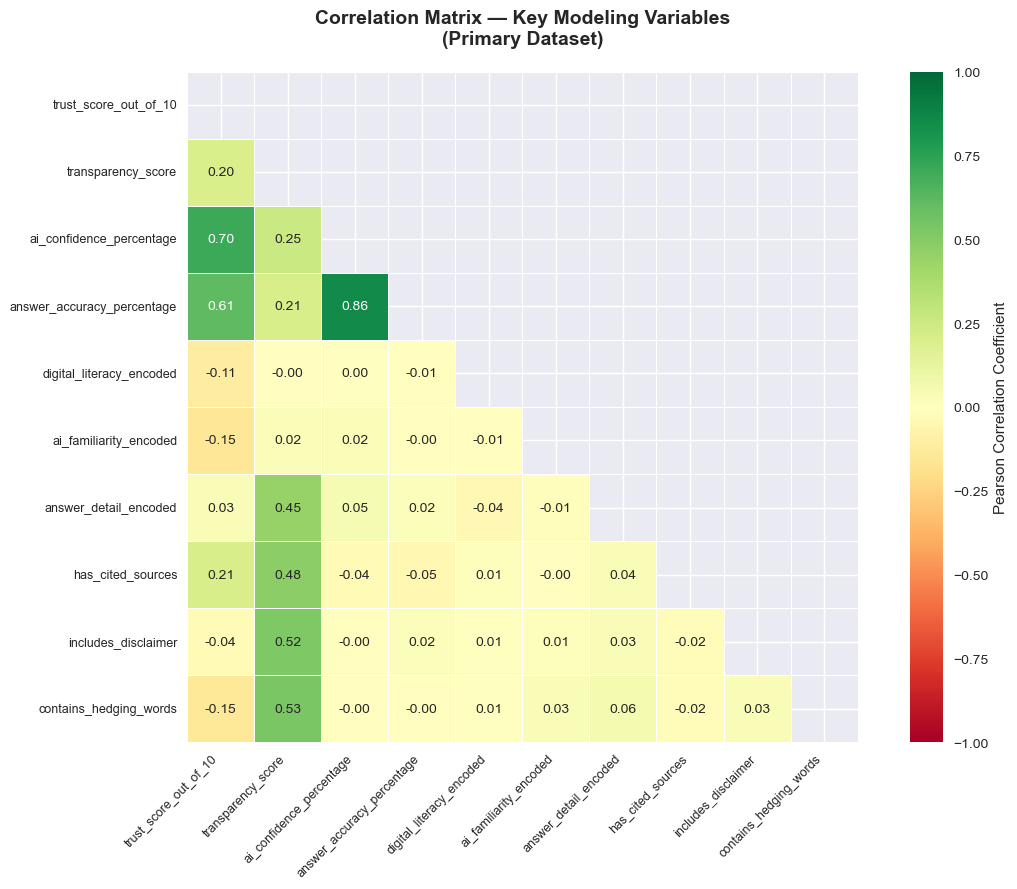


📊 Correlations with trust_score_out_of_10 (sorted):
   ai_confidence_percentage            r=+0.7040  Strong positive ↑
   answer_accuracy_percentage          r=+0.6128  Moderate positive ↑
   has_cited_sources                   r=+0.2057  Weak positive ↑
   transparency_score                  r=+0.2009  Weak positive ↑
   ai_familiarity_encoded              r=-0.1494  Negligible negative ↓
   contains_hedging_words              r=-0.1479  Negligible negative ↓
   digital_literacy_encoded            r=-0.1143  Negligible negative ↓
   includes_disclaimer                 r=-0.0372  Negligible negative ↓
   answer_detail_encoded               r=+0.0334  Negligible positive ↑


In [37]:
# ─────────────────────────────────────────────────────────────
# CELL 19: Correlation matrix and heatmap
# ─────────────────────────────────────────────────────────────

# WHAT IS CORRELATION?
# Correlation measures the LINEAR relationship between two variables.
# It's expressed as a number between -1 and +1:
#
#   +1.0  = perfect positive relationship (as X goes up, Y goes up proportionally)
#    0.0  = no linear relationship
#   -1.0  = perfect negative relationship (as X goes up, Y goes down proportionally)
#
# WHAT VALUES TO LOOK FOR:
#   |r| > 0.7  = strong correlation
#   |r| 0.4–0.7 = moderate correlation
#   |r| 0.2–0.4 = weak correlation
#   |r| < 0.2  = very weak / negligible
#
# WHY IT MATTERS FOR YOUR PROJECT:
#   - We want transparency_score to correlate with trust_score (that's our hypothesis)
#   - We DON'T want our X variables to correlate too strongly with each other
#     (that would cause "multicollinearity" — a problem in multiple regression)

# ── Compute the correlation matrix ───────────────────────────
corr_matrix = df_clean[key_vars].corr()
# .corr() computes pairwise Pearson correlation coefficients
# between all columns — returns a square matrix
# Each cell shows the correlation between row-variable and column-variable

# ── Plot the heatmap ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
# fig = the overall figure canvas
# ax = the axes (the actual plot area)
# figsize=(width, height) in inches

# Create a mask for the upper triangle (avoid showing duplicate info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# np.triu creates an upper-triangle matrix of True values
# This masks out the upper triangle in the heatmap so we only
# see each pair once (the lower triangle is enough)

sns.heatmap(
    corr_matrix,          # The correlation data to visualize
    mask=mask,            # Hide upper triangle
    annot=True,           # Show the correlation number in each cell
    fmt='.2f',            # Format numbers to 2 decimal places
    cmap='RdYlGn',        # Color map: Red (negative) → Yellow (near 0) → Green (positive)
    center=0,             # Center the color scale at 0
    vmin=-1, vmax=1,      # Color scale runs from -1 to +1
    square=True,          # Make each cell square-shaped
    linewidths=0.5,       # Add thin lines between cells
    cbar_kws={'label': 'Pearson Correlation Coefficient'},  # Label the color bar
    ax=ax
)

ax.set_title(
    'Correlation Matrix — Key Modeling Variables\n(Primary Dataset)',
    fontsize=14, fontweight='bold', pad=20
)

# Rotate x-axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()  # Automatically adjust spacing so nothing overlaps
plt.show()

# ── Print the most important correlations ────────────────────
print("\n📊 Correlations with trust_score_out_of_10 (sorted):")
trust_corr = corr_matrix['trust_score_out_of_10'].drop('trust_score_out_of_10')
trust_corr_sorted = trust_corr.abs().sort_values(ascending=False)

for var in trust_corr_sorted.index:
    r = corr_matrix.loc['trust_score_out_of_10', var]
    strength = (
        "Strong" if abs(r) > 0.7 else
        "Moderate" if abs(r) > 0.4 else
        "Weak" if abs(r) > 0.2 else
        "Negligible"
    )
    direction = "positive ↑" if r > 0 else "negative ↓"
    print(f"   {var:<35} r={r:+.4f}  {strength} {direction}")

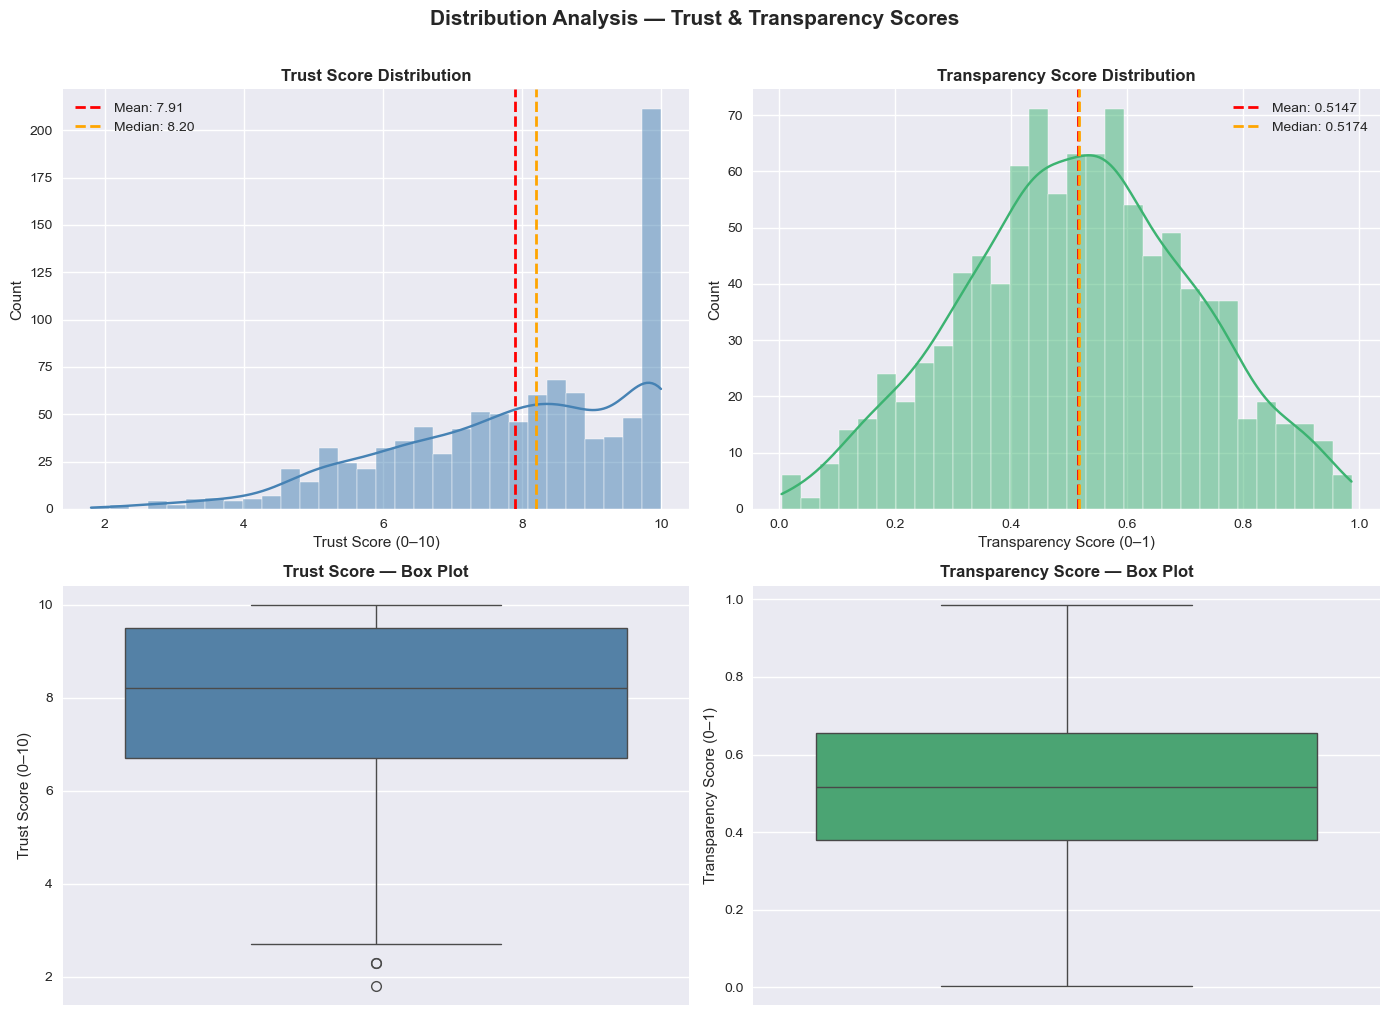

✅ Distribution plots generated and saved as 'distributions.png'

📊 Trust Score:        Mean=7.91, Median=8.20, Skew=-0.6608
📊 Transparency Score: Mean=0.5147, Median=0.5174, Skew=-0.0298


In [38]:
# ─────────────────────────────────────────────────────────────
# CELL 20: Distribution plots for trust and transparency scores
# ─────────────────────────────────────────────────────────────

# WHY DO WE CHECK DISTRIBUTIONS?
# Linear regression assumes that the RESIDUALS (errors) are normally distributed.
# While this isn't strictly about the raw variables, checking if our Y variable
# (trust score) is roughly normal gives us a good early signal.
# A heavily skewed Y variable often means the residuals will also be skewed.
#
# WHAT IS A NORMAL DISTRIBUTION?
# A bell-shaped curve where:
#   - Most values cluster around the mean
#   - Fewer values appear as you move away from the mean
#   - It's symmetric — equal tails on both sides
# This matters because most statistical tests assume normality.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Creates a 2×2 grid of 4 plots
# axes[row][col] accesses each subplot

fig.suptitle(
    'Distribution Analysis — Trust & Transparency Scores',
    fontsize=15, fontweight='bold', y=1.01
)

# ── Plot 1: Trust Score histogram + KDE ──────────────────────
axes[0, 0].set_title('Trust Score Distribution', fontsize=12, fontweight='bold')
sns.histplot(
    df_clean['trust_score_out_of_10'],
    bins=30,           # Number of bars in the histogram
    kde=True,          # Overlay a KDE (Kernel Density Estimate) smooth curve
    color='steelblue',
    edgecolor='white',
    ax=axes[0, 0]
)
# KDE = a smooth curve showing the "shape" of the distribution
# It's like a smoothed histogram — easier to see the overall pattern

# Add vertical lines for mean and median
mean_trust = df_clean['trust_score_out_of_10'].mean()
median_trust = df_clean['trust_score_out_of_10'].median()
axes[0, 0].axvline(mean_trust, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_trust:.2f}')
axes[0, 0].axvline(median_trust, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_trust:.2f}')
# axvline draws a vertical line at a specified x position
axes[0, 0].legend()
axes[0, 0].set_xlabel('Trust Score (0–10)')
axes[0, 0].set_ylabel('Count')

# ── Plot 2: Transparency Score histogram + KDE ───────────────
axes[0, 1].set_title('Transparency Score Distribution', fontsize=12, fontweight='bold')
sns.histplot(
    df_clean['transparency_score'],
    bins=30,
    kde=True,
    color='mediumseagreen',
    edgecolor='white',
    ax=axes[0, 1]
)
mean_trans = df_clean['transparency_score'].mean()
median_trans = df_clean['transparency_score'].median()
axes[0, 1].axvline(mean_trans, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_trans:.4f}')
axes[0, 1].axvline(median_trans, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_trans:.4f}')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Transparency Score (0–1)')
axes[0, 1].set_ylabel('Count')

# ── Plot 3: Trust Score box plot ─────────────────────────────
axes[1, 0].set_title('Trust Score — Box Plot', fontsize=12, fontweight='bold')
sns.boxplot(
    y=df_clean['trust_score_out_of_10'],
    color='steelblue',
    ax=axes[1, 0]
)
# Box plot shows:
#   - The box = middle 50% of data (Q1 to Q3)
#   - The line inside the box = median
#   - The whiskers = extend to 1.5 × IQR
#   - Dots beyond whiskers = outliers
axes[1, 0].set_ylabel('Trust Score (0–10)')

# ── Plot 4: Transparency Score box plot ──────────────────────
axes[1, 1].set_title('Transparency Score — Box Plot', fontsize=12, fontweight='bold')
sns.boxplot(
    y=df_clean['transparency_score'],
    color='mediumseagreen',
    ax=axes[1, 1]
)
axes[1, 1].set_ylabel('Transparency Score (0–1)')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
# Saves the plot as an image file — useful for your research paper
plt.show()

print("✅ Distribution plots generated and saved as 'distributions.png'")
print(f"\n📊 Trust Score:        Mean={mean_trust:.2f}, Median={median_trust:.2f}, Skew={df_clean['trust_score_out_of_10'].skew():.4f}")
print(f"📊 Transparency Score: Mean={mean_trans:.4f}, Median={median_trans:.4f}, Skew={df_clean['transparency_score'].skew():.4f}")

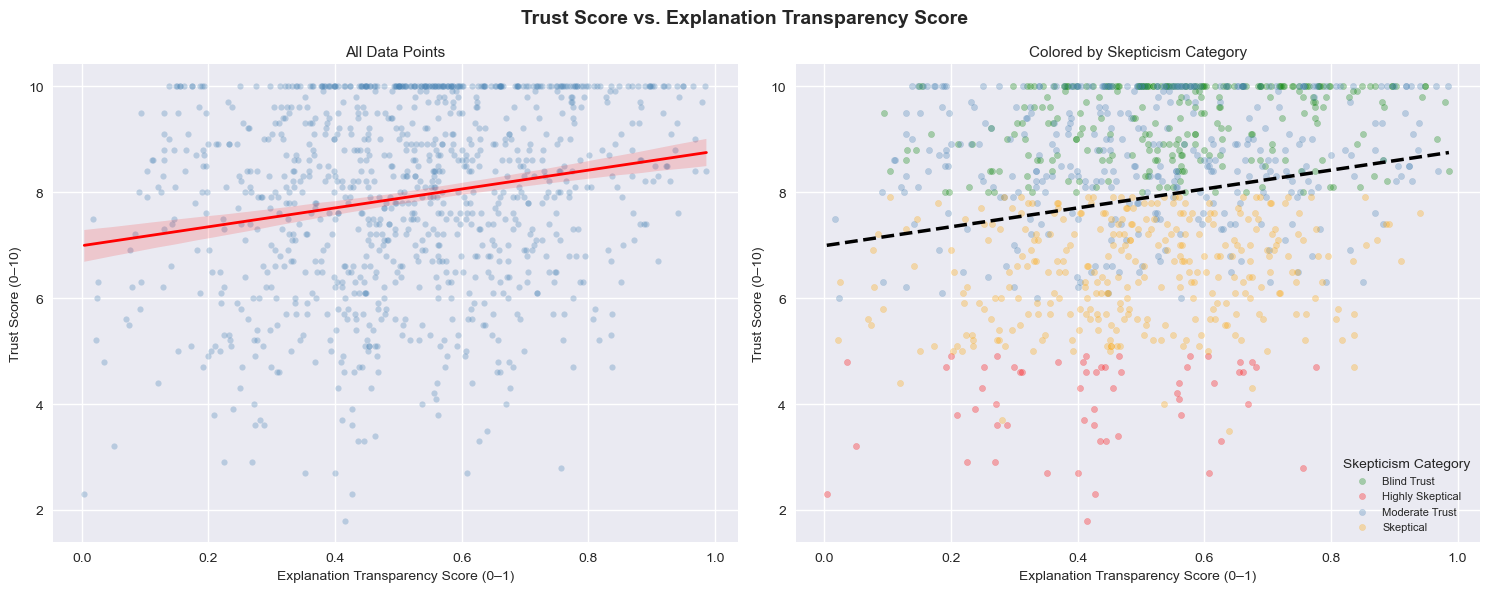

✅ Scatter plots generated and saved.


In [39]:
# ─────────────────────────────────────────────────────────────
# CELL 21: Scatter plot — Trust Score vs Transparency Score
# ─────────────────────────────────────────────────────────────

# WHY THIS PLOT?
# This is the most direct visual test of your core research hypothesis:
# "Does higher explanation transparency lead to higher trust?"
# If the trend line slopes upward → yes, there is a positive relationship
# If it's flat → no clear relationship
# If it slopes downward → more transparency actually reduces trust (interesting!)
#
# The regression line here is PURELY VISUAL — seaborn draws it automatically.
# It is NOT the same as our regression model in Step 6.
# Think of it as a "preview" of what the model will formalize.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'Trust Score vs. Explanation Transparency Score',
    fontsize=14, fontweight='bold'
)

# ── Plot 1: Basic scatter with regression line ───────────────
sns.regplot(
    x='transparency_score',        # X axis: our predictor
    y='trust_score_out_of_10',     # Y axis: what we're predicting
    data=df_clean,
    scatter_kws={
        'alpha': 0.3,              # 30% opacity — helps see density when points overlap
        'color': 'steelblue',
        's': 20                    # Point size
    },
    line_kws={
        'color': 'red',            # Regression line color
        'linewidth': 2
    },
    ci=95,                         # Show 95% confidence interval band around the line
    ax=axes[0]
)
# ci=95 draws a shaded band around the regression line
# The band shows where the true regression line likely falls
# A narrow band = high confidence; wide band = more uncertainty

axes[0].set_title('All Data Points', fontsize=11)
axes[0].set_xlabel('Explanation Transparency Score (0–1)', fontsize=10)
axes[0].set_ylabel('Trust Score (0–10)', fontsize=10)

# ── Plot 2: Colored by skepticism category ───────────────────
# This adds another dimension — do skeptical users show
# a different transparency-trust relationship?
colors = {'Moderate Trust': 'steelblue', 'Skeptical': 'orange',
          'Blind Trust': 'green', 'Highly Skeptical': 'red'}

for category, group in df_clean.groupby('user_skepticism_category'):
    # .groupby() splits the DataFrame into groups by category
    # We loop through each group and plot it separately
    axes[1].scatter(
        group['transparency_score'],
        group['trust_score_out_of_10'],
        alpha=0.3,
        s=20,
        label=category,
        color=colors.get(category, 'gray')
    )

# Add overall regression line
sns.regplot(
    x='transparency_score',
    y='trust_score_out_of_10',
    data=df_clean,
    scatter=False,         # Don't re-draw the scatter points
    line_kws={'color': 'black', 'linewidth': 2.5, 'linestyle': '--'},
    ci=None,
    ax=axes[1]
)

axes[1].set_title('Colored by Skepticism Category', fontsize=11)
axes[1].set_xlabel('Explanation Transparency Score (0–1)', fontsize=10)
axes[1].set_ylabel('Trust Score (0–10)', fontsize=10)
axes[1].legend(title='Skepticism Category', fontsize=8)

plt.tight_layout()
plt.savefig('scatter_trust_vs_transparency.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Scatter plots generated and saved.")

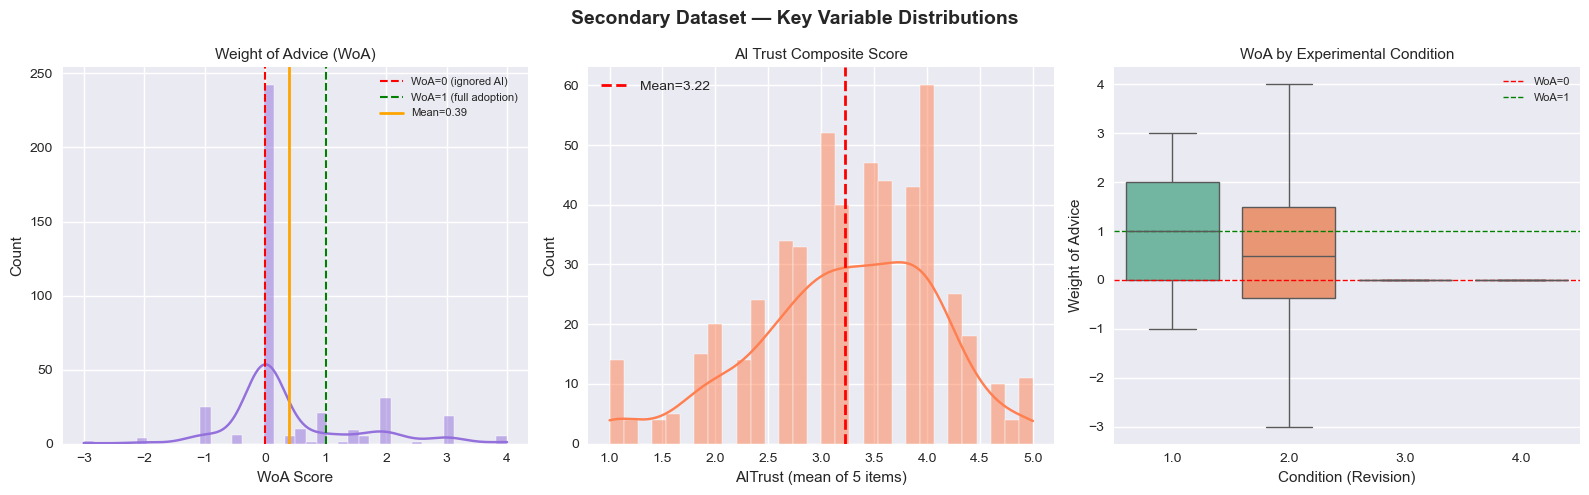

✅ Secondary dataset distributions plotted and saved.

📊 WoA Summary:
   Mean:    0.3917
   Median:  0.0000
   % with WoA between 0–1: 72.1%
   % who ignored AI (WoA=0): 62.5%


In [41]:
# ─────────────────────────────────────────────────────────────
# CELL 22: WoA distribution + AITrust distribution (Secondary)
# ─────────────────────────────────────────────────────────────

# WHY VISUALIZE WoA?
# WoA is our Y variable in Step 9 (cross-validation on secondary dataset).
# Before modeling it, we need to understand its shape.
# We know from Step 4 it has values from -3 to +4 — let's see where
# most values fall and how extreme the outliers are.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Secondary Dataset — Key Variable Distributions',
    fontsize=14, fontweight='bold'
)

# ── Plot 1: WoA distribution ──────────────────────────────────
# Drop NaN values for plotting only (we keep them in the dataset)
woa_clean = df_sav_clean['WoA'].dropna()

sns.histplot(
    woa_clean,
    bins=40,
    kde=True,
    color='mediumpurple',
    edgecolor='white',
    ax=axes[0]
)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='WoA=0 (ignored AI)')
axes[0].axvline(1, color='green', linestyle='--', linewidth=1.5, label='WoA=1 (full adoption)')
axes[0].axvline(woa_clean.mean(), color='orange', linestyle='-', linewidth=2,
                label=f'Mean={woa_clean.mean():.2f}')
axes[0].set_title('Weight of Advice (WoA)', fontsize=11)
axes[0].set_xlabel('WoA Score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# ── Plot 2: AITrust distribution ──────────────────────────────
sns.histplot(
    df_sav_clean['AITrust'].dropna(),
    bins=30,
    kde=True,
    color='coral',
    edgecolor='white',
    ax=axes[1]
)
axes[1].axvline(df_sav_clean['AITrust'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean={df_sav_clean['AITrust'].mean():.2f}")
axes[1].set_title('AI Trust Composite Score', fontsize=11)
axes[1].set_xlabel('AITrust (mean of 5 items)')
axes[1].set_ylabel('Count')
axes[1].legend()

# ── Plot 3: WoA by Experimental Condition ────────────────────
# ConditionRevision = positive vs negative AI framing
# This is your key experimental manipulation — do people
# trust AI more when it's framed positively?
sns.boxplot(
    x='ConditionRevision',
    y='WoA',
    data=df_sav_clean.dropna(subset=['WoA']),
    hue='ConditionRevision',  # Assign x variable to hue as well
    palette='Set2',           # Now palette works correctly with hue
    legend=False,             # Suppress the redundant legend hue creates
    ax=axes[2]
)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1, label='WoA=0')
axes[2].axhline(1, color='green', linestyle='--', linewidth=1, label='WoA=1')
axes[2].set_title('WoA by Experimental Condition', fontsize=11)
axes[2].set_xlabel('Condition (Revision)')
axes[2].set_ylabel('Weight of Advice')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('secondary_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Secondary dataset distributions plotted and saved.")
print(f"\n📊 WoA Summary:")
print(f"   Mean:    {woa_clean.mean():.4f}")
print(f"   Median:  {woa_clean.median():.4f}")
print(f"   % with WoA between 0–1: {((woa_clean >= 0) & (woa_clean <= 1)).mean()*100:.1f}%")
print(f"   % who ignored AI (WoA=0): {(woa_clean == 0).mean()*100:.1f}%")

In [42]:
# ─────────────────────────────────────────────────────────────
# MODEL 1: Simple Linear Regression
# CELL 1: Simple Linear Regression — Trust ~ Transparency Score
# ─────────────────────────────────────────────────────────────

# ── Step 1: Define X and Y ────────────────────────────────────

# X = predictor variable (what we use to predict)
# Must be 2D for scikit-learn — double brackets [[]] create a DataFrame
# Single bracket [] would create a Series — scikit-learn rejects that
X_simple = df_clean[['transparency_score']]

# Y = target variable (what we're trying to predict)
# This can be a 1D Series — single bracket is fine for Y
y = df_clean['trust_score_out_of_10']

print(f"X shape: {X_simple.shape}")  # Should be (1000, 1)
print(f"y shape: {y.shape}")         # Should be (1000,)

# ── Step 2: Split data into Training and Test sets ─────────────
# WHY SPLIT?
# If we train and test on the same data, the model will look
# artificially good — it already "saw" the answers.
# We hold out 20% of data for testing — the model never sees this
# during training. This gives us an honest evaluation.

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,    # Our predictor variable
    y,           # Our target variable
    test_size=0.2,      # 20% of data = test set (200 rows)
                        # 80% of data = training set (800 rows)
    random_state=42     # "Seed" for reproducibility — ensures you get
                        # the same split every time you run this cell
                        # 42 is a convention (from "Hitchhiker's Guide")
)

print(f"\n✅ Data split complete:")
print(f"   Training set: {X_train.shape[0]} rows (80%)")
print(f"   Test set:     {X_test.shape[0]} rows (20%)")

# ── Step 3: Fit the model using scikit-learn ──────────────────
from sklearn.linear_model import LinearRegression

lr_simple = LinearRegression()
# LinearRegression() creates a blank model object
# At this point it knows nothing — it hasn't seen data yet

lr_simple.fit(X_train, y_train)
# .fit() is where the learning happens
# It finds the β₀ and β₁ values that minimize the sum of squared errors
# "Squared errors" = (actual Y - predicted Y)²
# The model finds the line that makes these squared errors as small as possible

print(f"\n✅ Model trained successfully!")
print(f"\n📊 Model Coefficients:")
print(f"   β₀ (Intercept): {lr_simple.intercept_:.4f}")
print(f"   β₁ (Transparency Score coefficient): {lr_simple.coef_[0]:.4f}")

# ── Interpret the coefficients ────────────────────────────────
print(f"\n📖 Interpretation:")
print(f"   When transparency_score = 0, predicted trust = {lr_simple.intercept_:.4f}")
print(f"   For every +1.0 increase in transparency_score,")
print(f"   trust increases by {lr_simple.coef_[0]:.4f} points")
print(f"\n   Since transparency_score ranges 0–1, a move from")
print(f"   minimum to maximum transparency predicts a trust")
print(f"   increase of {lr_simple.coef_[0]:.4f} points (on a 10-point scale)")

X shape: (1000, 1)
y shape: (1000,)

✅ Data split complete:
   Training set: 800 rows (80%)
   Test set:     200 rows (20%)

✅ Model trained successfully!

📊 Model Coefficients:
   β₀ (Intercept): 7.1780
   β₁ (Transparency Score coefficient): 1.4752

📖 Interpretation:
   When transparency_score = 0, predicted trust = 7.1780
   For every +1.0 increase in transparency_score,
   trust increases by 1.4752 points

   Since transparency_score ranges 0–1, a move from
   minimum to maximum transparency predicts a trust
   increase of 1.4752 points (on a 10-point scale)


In [43]:
# ─────────────────────────────────────────────────────────────
# MODEL 1: Simple Linear Regression
# CELL 2: Detailed regression output using statsmodels
# ─────────────────────────────────────────────────────────────

# WHY USE STATSMODELS HERE?
# scikit-learn is great for prediction but gives minimal statistical detail.
# statsmodels gives you the FULL academic regression table:
#   - p-values (is the relationship statistically significant?)
#   - confidence intervals (what's the plausible range for β₁?)
#   - R² and Adjusted R²
#   - F-statistic (overall model significance)
# This is the output you'd see in a research paper or SPSS output.

import statsmodels.api as sm

# statsmodels requires us to manually add a constant (intercept) column
# scikit-learn does this automatically, but statsmodels does not
X_train_sm = sm.add_constant(X_train)
# sm.add_constant() adds a column of 1s called 'const'
# This allows the model to estimate β₀ (the intercept)
# Without it, the regression line is forced through the origin (0,0)

# Fit the OLS (Ordinary Least Squares) model
# OLS is the standard method for linear regression
model_sm = sm.OLS(y_train, X_train_sm).fit()
# sm.OLS(y, X) creates the model
# .fit() estimates the coefficients

# Print the full summary table
print(model_sm.summary())

                              OLS Regression Results                             
Dep. Variable:     trust_score_out_of_10   R-squared:                       0.028
Model:                               OLS   Adj. R-squared:                  0.027
Method:                    Least Squares   F-statistic:                     23.14
Date:                   Fri, 27 Mar 2026   Prob (F-statistic):           1.80e-06
Time:                           15:44:44   Log-Likelihood:                -1564.3
No. Observations:                    800   AIC:                             3133.
Df Residuals:                        798   BIC:                             3142.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const 

In [44]:
# ─────────────────────────────────────────────────────────────
# MODEL 1: Simple Linear Regression
# CELL 3: Generate predictions and calculate evaluation metrics
# ─────────────────────────────────────────────────────────────

# ── Generate predictions ──────────────────────────────────────
y_pred_simple = lr_simple.predict(X_test)
# .predict() applies the learned β₀ + β₁X formula to the TEST data
# These are the model's guesses for trust scores it has never seen

# ── Calculate evaluation metrics ─────────────────────────────

# R² — Coefficient of Determination
# Answers: "What % of the variation in trust does our model explain?"
# Formula: 1 - (sum of squared residuals / total sum of squares)
# Range: 0 to 1 (can be negative for very bad models)
#   R²=1.0 = perfect prediction
#   R²=0.5 = model explains 50% of variance
#   R²=0.0 = model is no better than just predicting the mean every time
r2_simple = r2_score(y_test, y_pred_simple)

# MAE — Mean Absolute Error
# Answers: "On average, how many points off are our predictions?"
# Formula: mean(|actual - predicted|)
# Same units as Y (trust points, 0–10 scale)
# Easy to interpret: MAE=1.5 means predictions are off by 1.5 points on average
mae_simple = mean_absolute_error(y_test, y_pred_simple)

# RMSE — Root Mean Squared Error
# Similar to MAE but PENALIZES large errors more heavily
# Formula: sqrt(mean((actual - predicted)²))
# Also in same units as Y
# RMSE > MAE always — the gap between them tells you how much
# your model struggles with outliers (large gap = struggling with extremes)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))

print("=" * 55)
print("MODEL 1 — SIMPLE LINEAR REGRESSION RESULTS")
print("=" * 55)
print(f"\n📊 Evaluation Metrics (on unseen TEST data):")
print(f"   R²   = {r2_simple:.4f}  → Model explains {r2_simple*100:.2f}% of variance in trust")
print(f"   MAE  = {mae_simple:.4f}  → Predictions off by {mae_simple:.2f} points on average")
print(f"   RMSE = {rmse_simple:.4f}  → Penalized error = {rmse_simple:.2f} points")

print(f"\n📖 Plain English Interpretation:")
print(f"   A trust score prediction from this model is typically")
print(f"   within ±{mae_simple:.1f} points of the actual score.")
print(f"   The model accounts for {r2_simple*100:.1f}% of why trust scores vary.")

# Store results for the comparison table we'll build in Step 7
model_results = {
    'Model 1 — Simple Linear': {
        'R²': round(r2_simple, 4),
        'MAE': round(mae_simple, 4),
        'RMSE': round(rmse_simple, 4)
    }
}
print(f"\n✅ Results stored for final comparison table.")

MODEL 1 — SIMPLE LINEAR REGRESSION RESULTS

📊 Evaluation Metrics (on unseen TEST data):
   R²   = 0.0714  → Model explains 7.14% of variance in trust
   MAE  = 1.4823  → Predictions off by 1.48 points on average
   RMSE = 1.8148  → Penalized error = 1.81 points

📖 Plain English Interpretation:
   A trust score prediction from this model is typically
   within ±1.5 points of the actual score.
   The model accounts for 7.1% of why trust scores vary.

✅ Results stored for final comparison table.


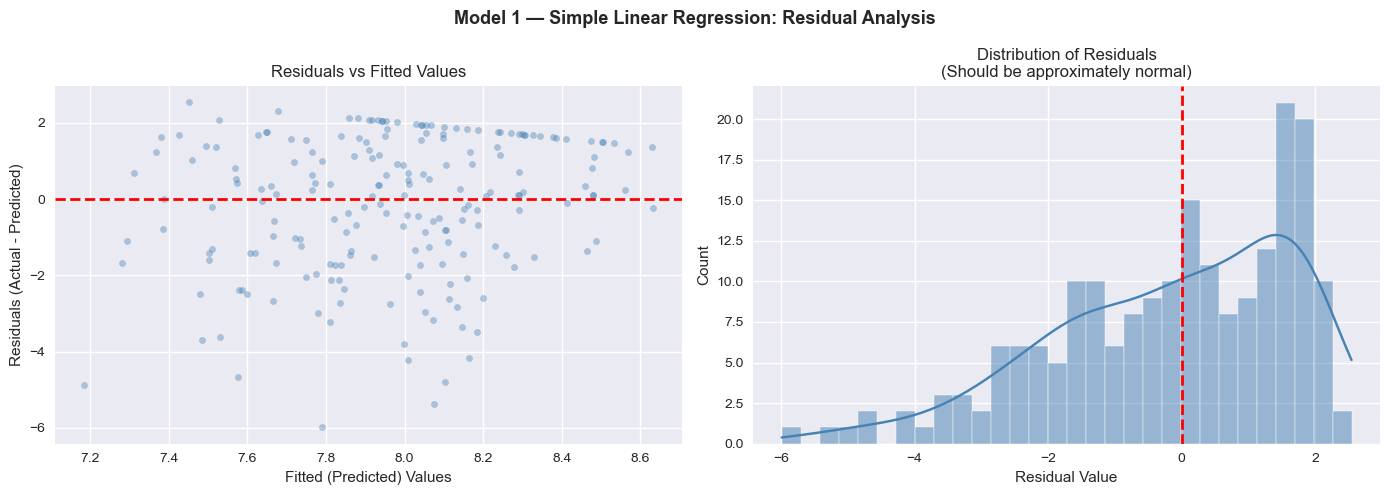

✅ Residual plots saved.

📊 Residual Statistics:
   Mean of residuals: -0.161438  (should be ~0)
   Std of residuals:  1.8122
   Min residual: -5.9907
   Max residual: 2.5475


In [45]:
# ─────────────────────────────────────────────────────────────
# MODEL 1: Simple Linear Regression
# CELL 4: Residual plot — check regression assumptions
# ─────────────────────────────────────────────────────────────

# WHAT ARE RESIDUALS?
# Residual = Actual Value - Predicted Value
# If our model predicted 7.5 but the actual was 8.2 → residual = +0.7
# If our model predicted 8.0 but the actual was 7.1 → residual = -0.9
#
# WHY PLOT THEM?
# Linear regression has 3 key assumptions:
#   1. Linearity    — residuals should show NO pattern (random scatter)
#   2. Homoscedasticity — residual spread should be EQUAL across all predictions
#   3. Normality    — residuals should follow a normal distribution
#
# HOW TO READ THE RESIDUAL PLOT:
#   GOOD: Random cloud of dots centered around the y=0 line
#   BAD:  A funnel shape (wider on one side) → heteroscedasticity
#   BAD:  A curved pattern → the relationship isn't actually linear
#   BAD:  Systematic bands or clusters → missing variable problem

residuals_simple = y_test - y_pred_simple
# Calculate residuals: actual minus predicted for each test observation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 1 — Simple Linear Regression: Residual Analysis',
             fontsize=13, fontweight='bold')

# ── Plot 1: Residuals vs Fitted values ───────────────────────
axes[0].scatter(
    y_pred_simple,    # X axis: what the model predicted
    residuals_simple, # Y axis: how wrong it was
    alpha=0.4,
    color='steelblue',
    s=20
)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
# The red line at y=0 is our "perfect prediction" reference
# Dots above = model under-predicted; dots below = model over-predicted
axes[0].set_xlabel('Fitted (Predicted) Values')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residuals vs Fitted Values')

# ── Plot 2: Distribution of residuals ────────────────────────
sns.histplot(residuals_simple, bins=30, kde=True,
             color='steelblue', edgecolor='white', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals\n(Should be approximately normal)')

plt.tight_layout()
plt.savefig('model1_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Residual plots saved.")
print(f"\n📊 Residual Statistics:")
print(f"   Mean of residuals: {residuals_simple.mean():.6f}  (should be ~0)")
print(f"   Std of residuals:  {residuals_simple.std():.4f}")
print(f"   Min residual: {residuals_simple.min():.4f}")
print(f"   Max residual: {residuals_simple.max():.4f}")

In [46]:
# ─────────────────────────────────────────────────────────────
# Model 2: Multiple Linear Regression
# CELL 1: Define predictors and check VIF before fitting
# ─────────────────────────────────────────────────────────────

# WHAT IS VIF?
# VIF = Variance Inflation Factor
# It measures how much a predictor's variance is "inflated"
# because of its correlation with other predictors.
#
# VIF = 1.0       → No correlation with other predictors (ideal)
# VIF = 1.0–5.0   → Acceptable — mild correlation
# VIF = 5.0–10.0  → Concerning — moderate multicollinearity
# VIF > 10.0      → Severe multicollinearity — must fix
#
# We check BEFORE fitting to confirm our variable selection is safe.

from statsmodels.stats.outliers_influence import variance_inflation_factor
# This function comes from statsmodels' diagnostics module

# Define our predictor variables for Model 2
# We deliberately EXCLUDE ai_confidence_percentage due to r=0.86 with accuracy
X_multi_cols = [
    'transparency_score',           # Main X from our research proposal
    'digital_literacy_encoded',     # User characteristic
    'ai_familiarity_encoded',       # User characteristic  
    'answer_accuracy_percentage'    # AI performance measure (independent of transparency)
]

# Create the X matrix for multiple regression
X_multi = df_clean[X_multi_cols]

# Y stays the same as Model 1
# y = df_clean['trust_score_out_of_10']  (already defined)

# ── Compute VIF for each predictor ───────────────────────────
# We need to add a constant column first (same as statsmodels requirement)
X_vif = sm.add_constant(X_multi)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
# variance_inflation_factor(matrix, column_index)
# We loop through each column and compute its VIF
# X_vif.values converts DataFrame to numpy array (required by the function)

vif_data['Interpretation'] = vif_data['VIF'].apply(lambda x:
    '✅ No issue' if x < 5 else
    '⚠️ Moderate' if x < 10 else
    '🚨 Severe'
)

print("=" * 55)
print("VARIANCE INFLATION FACTOR (VIF) CHECK")
print("=" * 55)
display(vif_data)
print("\n✅ If all predictors show VIF < 5, we are safe to proceed.")

VARIANCE INFLATION FACTOR (VIF) CHECK


,Variable,VIF,Interpretation
0,const,22.9091,🚨 Severe
1,transparency_score,1.0452,✅ No issue
2,digital_literacy_encoded,1.0001,✅ No issue
3,ai_familiarity_encoded,1.0007,✅ No issue
4,answer_accuracy_percentage,1.0446,✅ No issue



✅ If all predictors show VIF < 5, we are safe to proceed.


In [47]:
# ─────────────────────────────────────────────────────────────
# Model 2: Multiple Linear Regression
# CELL 2: Fit the Multiple Linear Regression model
# ─────────────────────────────────────────────────────────────

# ── Train/test split ──────────────────────────────────────────
# IMPORTANT: We use the SAME random_state=42 as Model 1
# This ensures we're testing on the EXACT same 200 rows
# Making model comparisons fair and meaningful

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,    # Now 4 predictor columns instead of 1
    y,          # Same target variable
    test_size=0.2,
    random_state=42     # Same seed = same split = fair comparison
)

print(f"Training set: {X_train_m.shape[0]} rows × {X_train_m.shape[1]} predictors")
print(f"Test set:     {X_test_m.shape[0]} rows × {X_test_m.shape[1]} predictors")

# ── Fit with scikit-learn (for predictions and metrics) ───────
lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train_m)

print(f"\n✅ Model trained successfully!")
print(f"\n📊 Model Coefficients:")
print(f"   β₀ (Intercept): {lr_multi.intercept_:.4f}")

for col, coef in zip(X_multi_cols, lr_multi.coef_):
    print(f"   β  ({col:<35}): {coef:+.4f}")

# ── Fit with statsmodels (for p-values and full table) ────────
X_train_sm2 = sm.add_constant(X_train_m)
model_sm2 = sm.OLS(y_train_m, X_train_sm2).fit()

print(f"\n{'='*60}")
print("FULL STATSMODELS OUTPUT — Multiple Linear Regression")
print(f"{'='*60}")
print(model_sm2.summary())

Training set: 800 rows × 4 predictors
Test set:     200 rows × 4 predictors

✅ Model trained successfully!

📊 Model Coefficients:
   β₀ (Intercept): 4.3276
   β  (transparency_score                 ): +0.6515
   β  (digital_literacy_encoded           ): -0.1734
   β  (ai_familiarity_encoded             ): -0.2083
   β  (answer_accuracy_percentage         ): +0.0566

FULL STATSMODELS OUTPUT — Multiple Linear Regression
                              OLS Regression Results                             
Dep. Variable:     trust_score_out_of_10   R-squared:                       0.399
Model:                               OLS   Adj. R-squared:                  0.396
Method:                    Least Squares   F-statistic:                     131.9
Date:                   Fri, 27 Mar 2026   Prob (F-statistic):           2.17e-86
Time:                           15:55:38   Log-Likelihood:                -1372.1
No. Observations:                    800   AIC:                             2754.
Df R

In [48]:
# ─────────────────────────────────────────────────────────────
# Model 2: Multiple Linear Regression
# CELL 3: Evaluate Model 2 and compare to Model 1
# ─────────────────────────────────────────────────────────────

# Generate predictions on test data
y_pred_multi = lr_multi.predict(X_test_m)

# Calculate metrics
r2_multi   = r2_score(y_test_m, y_pred_multi)
mae_multi  = mean_absolute_error(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))

print("=" * 55)
print("MODEL 2 — MULTIPLE LINEAR REGRESSION RESULTS")
print("=" * 55)
print(f"\n📊 Evaluation Metrics (on unseen TEST data):")
print(f"   R²   = {r2_multi:.4f}  → Model explains {r2_multi*100:.2f}% of variance")
print(f"   MAE  = {mae_multi:.4f}  → Predictions off by {mae_multi:.2f} points on average")
print(f"   RMSE = {rmse_multi:.4f}  → Penalized error = {rmse_multi:.2f} points")

# ── Direct comparison with Model 1 ───────────────────────────
print(f"\n📊 Improvement over Model 1:")
print(f"   R² change:   {r2_simple:.4f} → {r2_multi:.4f}  "
      f"(+{(r2_multi - r2_simple)*100:.2f} percentage points)")
print(f"   MAE change:  {mae_simple:.4f} → {mae_multi:.4f}  "
      f"({'better ✅' if mae_multi < mae_simple else 'worse ❌'})")
print(f"   RMSE change: {rmse_simple:.4f} → {rmse_multi:.4f}  "
      f"({'better ✅' if rmse_multi < rmse_simple else 'worse ❌'})")

# Store results for comparison table
model_results['Model 2 — Multiple Linear'] = {
    'R²': round(r2_multi, 4),
    'MAE': round(mae_multi, 4),
    'RMSE': round(rmse_multi, 4)
}
print(f"\n✅ Results stored for final comparison table.")

MODEL 2 — MULTIPLE LINEAR REGRESSION RESULTS

📊 Evaluation Metrics (on unseen TEST data):
   R²   = 0.4666  → Model explains 46.66% of variance
   MAE  = 1.0969  → Predictions off by 1.10 points on average
   RMSE = 1.3755  → Penalized error = 1.38 points

📊 Improvement over Model 1:
   R² change:   0.0714 → 0.4666  (+39.52 percentage points)
   MAE change:  1.4823 → 1.0969  (better ✅)
   RMSE change: 1.8148 → 1.3755  (better ✅)

✅ Results stored for final comparison table.


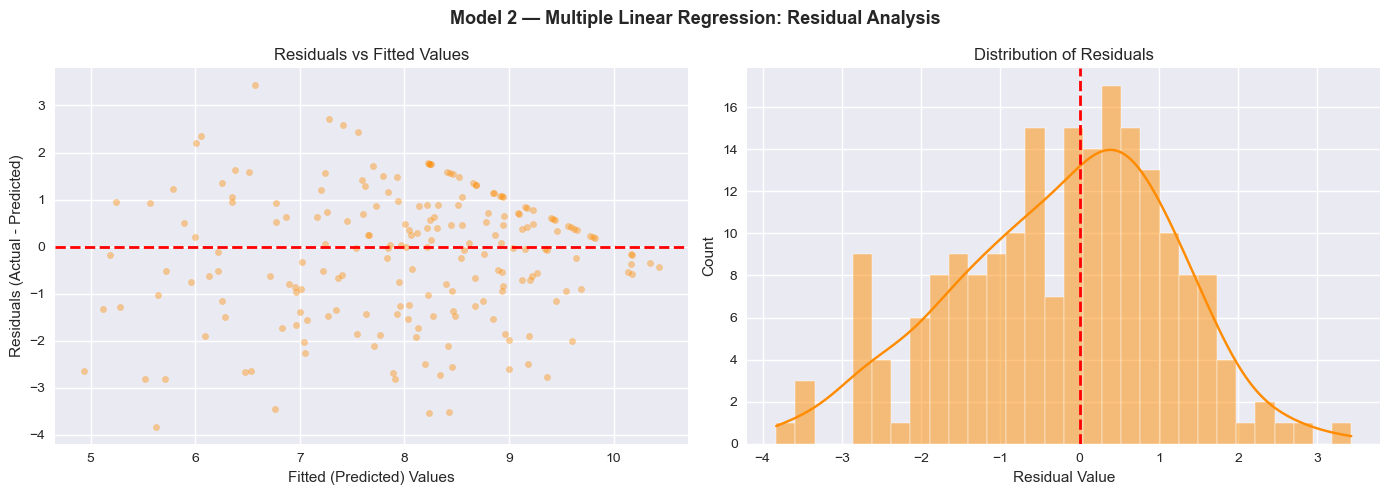

✅ Residual plots saved.

📊 Residual Statistics:
   Mean: -0.214203  (should be ~0)
   Std:  1.3621
   Min:  -3.8278
   Max:  3.4265


In [49]:
# ─────────────────────────────────────────────────────────────
# Model 2: Multiple Linear Regression
# CELL 4: Residual plots for Model 2
# ─────────────────────────────────────────────────────────────

residuals_multi = y_test_m - y_pred_multi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 2 — Multiple Linear Regression: Residual Analysis',
             fontsize=13, fontweight='bold')

# ── Plot 1: Residuals vs Fitted ───────────────────────────────
axes[0].scatter(
    y_pred_multi,
    residuals_multi,
    alpha=0.4, color='darkorange', s=20
)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted (Predicted) Values')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residuals vs Fitted Values')

# ── Plot 2: Residual distribution ────────────────────────────
sns.histplot(
    residuals_multi, bins=30, kde=True,
    color='darkorange', edgecolor='white', ax=axes[1]
)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.savefig('model2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Residual plots saved.")
print(f"\n📊 Residual Statistics:")
print(f"   Mean: {residuals_multi.mean():.6f}  (should be ~0)")
print(f"   Std:  {residuals_multi.std():.4f}")
print(f"   Min:  {residuals_multi.min():.4f}")
print(f"   Max:  {residuals_multi.max():.4f}")

In [50]:
# ─────────────────────────────────────────────────────────────
# Model 3: Random Forest
# CELL 1: Train the Random Forest Regressor
# ─────────────────────────────────────────────────────────────

# For Random Forest we use MORE predictors than linear regression
# because it handles correlations and non-linearities naturally.
# We include all meaningful predictors available.

X_rf_cols = [
    'transparency_score',           # Main research variable
    'digital_literacy_encoded',     # User characteristic
    'ai_familiarity_encoded',       # User characteristic
    'answer_accuracy_percentage',   # AI performance
    'ai_confidence_percentage',     # AI behavior (OK here — RF handles correlation)
    'has_cited_sources',            # Transparency component
    'includes_disclaimer',          # Transparency component
    'contains_hedging_words',       # Transparency component
    'answer_detail_encoded',        # Transparency component
    'decision_importance_encoded'   # Context variable
]

# Create feature matrix
X_rf = df_clean[X_rf_cols]

# ── Train/test split ──────────────────────────────────────────
# Same random_state=42 for fair comparison with all models
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train_rf.shape[0]} rows × {X_train_rf.shape[1]} predictors")
print(f"Test set:     {X_test_rf.shape[0]} rows × {X_test_rf.shape[1]} predictors")

# ── Build and train the Random Forest ────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=500,
    # n_estimators = number of trees to build
    # More trees = more stable predictions, but slower training
    # 500 is a solid default — enough stability without being excessive
    # Think of it as: "build 500 independent expert opinions and average them"

    max_depth=10,
    # max_depth = maximum number of questions (splits) each tree can ask
    # Without a limit, trees grow until every leaf has 1 sample → overfitting
    # Depth of 10 allows complex patterns while preventing memorization
    # Shallow trees (depth 3-4) = simpler, less accurate
    # Deep trees (depth 20+) = risk of overfitting

    min_samples_split=10,
    # A node must have at least 10 samples before it can be split further
    # This prevents the tree from making splits based on tiny groups
    # Higher value = more conservative, less overfitting

    min_samples_leaf=4,
    # Each leaf (final prediction node) must have at least 4 samples
    # Prevents the tree from making predictions based on just 1-2 data points
    # Another guard against overfitting

    max_features='sqrt',
    # At each split, consider only sqrt(n_features) random features
    # For 10 features: sqrt(10) ≈ 3 features considered per split
    # This is what makes each tree DIFFERENT from the others
    # It forces diversity among the 500 trees

    random_state=42,
    # Sets the random seed for reproducibility
    # Without this, you'd get slightly different results each run

    n_jobs=-1
    # Use ALL available CPU cores for parallel training
    # -1 means "use everything available" — makes training faster
)

print("\n⏳ Training Random Forest (500 trees)... this may take a moment...")
rf_model.fit(X_train_rf, y_train_rf)
# .fit() trains all 500 trees simultaneously using parallel processing
# Each tree sees a different random bootstrap sample of the training data

print("✅ Random Forest trained successfully!")
print(f"   Trees built: {rf_model.n_estimators}")
print(f"   Features used: {rf_model.n_features_in_}")

Training set: 800 rows × 10 predictors
Test set:     200 rows × 10 predictors

⏳ Training Random Forest (500 trees)... this may take a moment...
✅ Random Forest trained successfully!
   Trees built: 500
   Features used: 10


In [51]:
# ─────────────────────────────────────────────────────────────
# Model 3: Random Forest
# CELL 2: Generate predictions and compute evaluation metrics
# ─────────────────────────────────────────────────────────────

# Generate predictions on test data
y_pred_rf = rf_model.predict(X_test_rf)
# .predict() passes each test row through all 500 trees
# and returns the AVERAGE prediction across all trees

# Calculate metrics
r2_rf   = r2_score(y_test_rf, y_pred_rf)
mae_rf  = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

print("=" * 55)
print("MODEL 3 — RANDOM FOREST REGRESSOR RESULTS")
print("=" * 55)
print(f"\n📊 Evaluation Metrics (on unseen TEST data):")
print(f"   R²   = {r2_rf:.4f}  → Model explains {r2_rf*100:.2f}% of variance")
print(f"   MAE  = {mae_rf:.4f}  → Predictions off by {mae_rf:.2f} points on average")
print(f"   RMSE = {rmse_rf:.4f}  → Penalized error = {rmse_rf:.2f} points")

# ── Comparison table so far ───────────────────────────────────
print(f"\n📊 Model Comparison So Far:")
print(f"{'Model':<30} {'R²':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 56)
print(f"{'Model 1 — Simple Linear':<30} {r2_simple:>8.4f} {mae_simple:>8.4f} {rmse_simple:>8.4f}")
print(f"{'Model 2 — Multiple Linear':<30} {r2_multi:>8.4f} {mae_multi:>8.4f} {rmse_multi:>8.4f}")
print(f"{'Model 3 — Random Forest':<30} {r2_rf:>8.4f} {mae_rf:>8.4f} {rmse_rf:>8.4f}")

# Store results
model_results['Model 3 — Random Forest'] = {
    'R²': round(r2_rf, 4),
    'MAE': round(mae_rf, 4),
    'RMSE': round(rmse_rf, 4)
}
print(f"\n✅ Results stored for final comparison table.")

MODEL 3 — RANDOM FOREST REGRESSOR RESULTS

📊 Evaluation Metrics (on unseen TEST data):
   R²   = 0.6744  → Model explains 67.44% of variance
   MAE  = 0.8906  → Predictions off by 0.89 points on average
   RMSE = 1.0747  → Penalized error = 1.07 points

📊 Model Comparison So Far:
Model                                R²      MAE     RMSE
--------------------------------------------------------
Model 1 — Simple Linear          0.0714   1.4823   1.8148
Model 2 — Multiple Linear        0.4666   1.0969   1.3755
Model 3 — Random Forest          0.6744   0.8906   1.0747

✅ Results stored for final comparison table.


📊 Feature Importances (sorted by importance):


,Feature,Importance_Pct,Cumulative
0,ai_confidence_percentage,44.6800,0.4468
1,answer_accuracy_percentage,23.5400,0.6821
2,decision_importance_encoded,8.9700,0.7718
3,transparency_score,6.2100,0.8339
4,ai_familiarity_encoded,4.6300,0.8803
5,has_cited_sources,3.9700,0.9199
6,digital_literacy_encoded,2.7200,0.9471
7,contains_hedging_words,2.5700,0.9728
8,answer_detail_encoded,1.6900,0.9897
9,includes_disclaimer,1.0300,1.0000


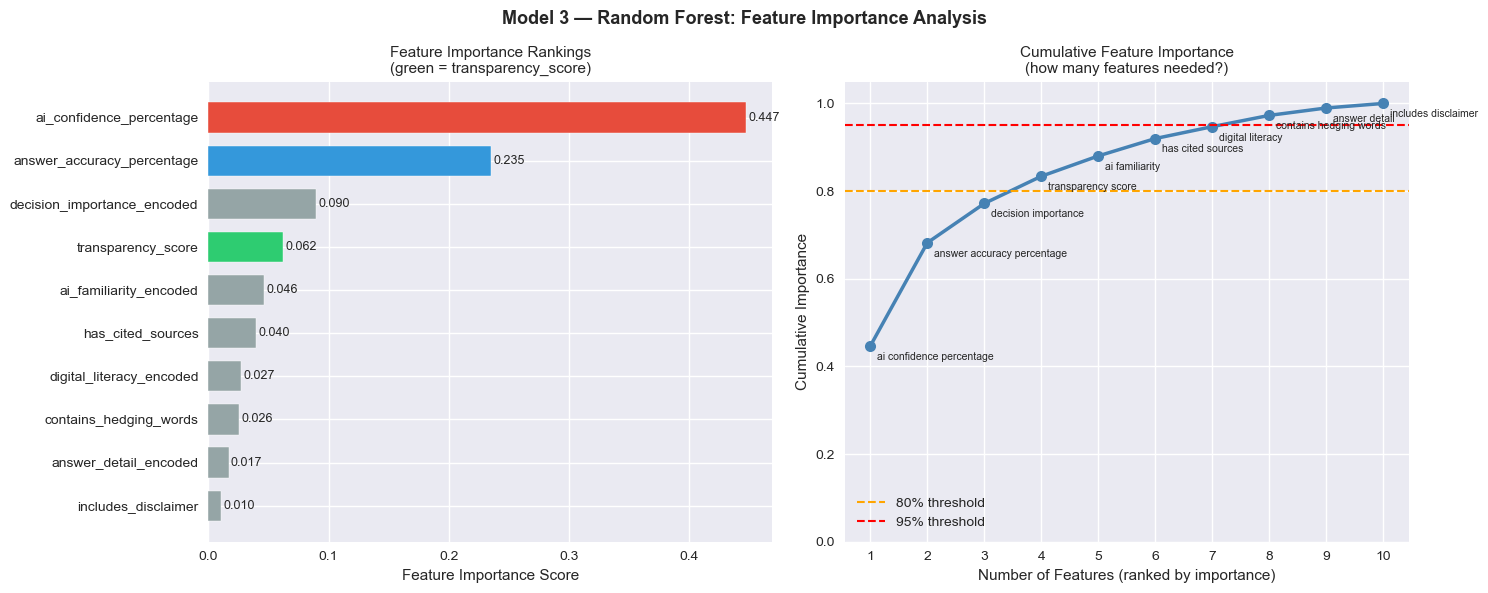

✅ Feature importance plots saved.


In [52]:
# ─────────────────────────────────────────────────────────────
# Model 3: Random Forest
# CELL 3: Extract and visualize feature importances
# ─────────────────────────────────────────────────────────────

# WHAT IS FEATURE IMPORTANCE?
# After training, Random Forest can tell us how much each predictor
# contributed to reducing prediction error across all 500 trees.
#
# HOW IS IT CALCULATED?
# Every time a tree makes a split on a variable, it measures how much
# that split reduced the error (impurity). Feature importance =
# the total error reduction credited to each variable, averaged
# across all trees and normalized to sum to 1.0
#
# WHAT IT TELLS YOU:
# Importance = 0.40 means that variable was responsible for
# 40% of all the error reduction across all splits in all trees.
# Higher = more important for predicting trust.
#
# WHY THIS IS VALUABLE FOR YOUR PAPER:
# This answers: "Which components of AI explanation quality
# matter most for building user trust?" — a core research question.

# Extract feature importances from the trained model
importances = rf_model.feature_importances_
# Returns an array of importance scores — one per feature
# They automatically sum to 1.0

# Create a clean DataFrame for visualization
feat_importance_df = pd.DataFrame({
    'Feature': X_rf_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)
# Sort by importance descending — most important at top

# Calculate cumulative importance
feat_importance_df['Cumulative'] = feat_importance_df['Importance'].cumsum()
feat_importance_df['Importance_Pct'] = (feat_importance_df['Importance'] * 100).round(2)

print("📊 Feature Importances (sorted by importance):")
display(feat_importance_df[['Feature', 'Importance_Pct', 'Cumulative']].reset_index(drop=True))

# ── Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model 3 — Random Forest: Feature Importance Analysis',
             fontsize=13, fontweight='bold')

# ── Plot 1: Horizontal bar chart ─────────────────────────────
colors = ['#2ecc71' if f == 'transparency_score' else
          '#3498db' if f == 'answer_accuracy_percentage' else
          '#e74c3c' if f == 'ai_confidence_percentage' else
          '#95a5a6'
          for f in feat_importance_df['Feature']]
# Color transparency_score green (our main variable)
# Color accuracy blue (strongest predictor from EDA)
# Color confidence red (excluded from linear models)
# Color everything else gray

axes[0].barh(
    feat_importance_df['Feature'],
    feat_importance_df['Importance'],
    color=colors,
    edgecolor='white',
    height=0.7
)
# barh = horizontal bar chart
# Horizontal layout is better for reading long variable names

axes[0].set_xlabel('Feature Importance Score', fontsize=11)
axes[0].set_title('Feature Importance Rankings\n(green = transparency_score)',
                  fontsize=11)
axes[0].invert_yaxis()
# invert_yaxis() puts the most important feature at the TOP

# Add value labels on bars
for i, (val, name) in enumerate(zip(
    feat_importance_df['Importance'],
    feat_importance_df['Feature']
)):
    axes[0].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

# ── Plot 2: Cumulative importance curve ──────────────────────
axes[1].plot(
    range(1, len(feat_importance_df) + 1),
    feat_importance_df['Cumulative'],
    marker='o', linewidth=2.5,
    color='steelblue', markersize=8
)
# This curve shows how many features you need to capture X% of importance
# A steep initial rise means a few features dominate

axes[1].axhline(y=0.8, color='orange', linestyle='--',
                linewidth=1.5, label='80% threshold')
axes[1].axhline(y=0.95, color='red', linestyle='--',
                linewidth=1.5, label='95% threshold')

# Label each point with the feature name
for i, row in feat_importance_df.reset_index(drop=True).iterrows():
    axes[1].annotate(
        row['Feature'].replace('_encoded', '').replace('_', ' '),
        (i + 1, row['Cumulative']),
        textcoords='offset points',
        xytext=(5, -10),
        fontsize=7.5
    )

axes[1].set_xlabel('Number of Features (ranked by importance)', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance\n(how many features needed?)',
                  fontsize=11)
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(range(1, len(feat_importance_df) + 1))

plt.tight_layout()
plt.savefig('model3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plots saved.")

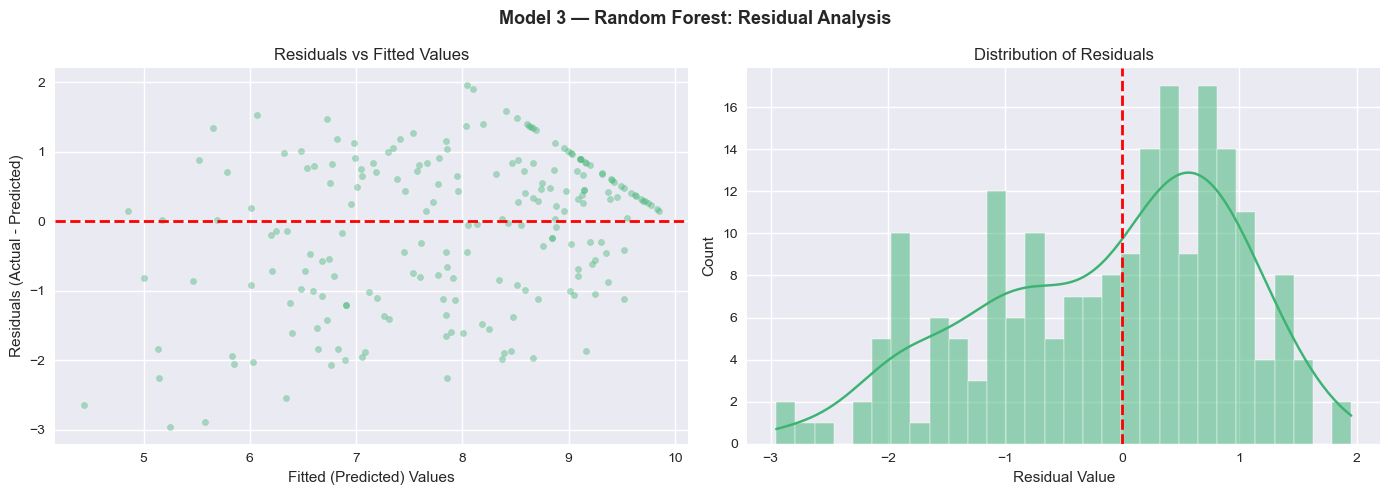

✅ Residual plots saved.

📊 Residual Statistics:
   Mean: -0.112979  (should be ~0)
   Std:  1.0714
   Min:  -2.9525
   Max:  1.9536


In [53]:
# ─────────────────────────────────────────────────────────────
# Model 3: Random Forest
# CELL 4: Residual analysis for Random Forest
# ─────────────────────────────────────────────────────────────

residuals_rf = y_test_rf - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 3 — Random Forest: Residual Analysis',
             fontsize=13, fontweight='bold')

# ── Plot 1: Residuals vs Fitted ───────────────────────────────
axes[0].scatter(
    y_pred_rf, residuals_rf,
    alpha=0.4, color='mediumseagreen', s=20
)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted (Predicted) Values')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residuals vs Fitted Values')

# ── Plot 2: Residual distribution ────────────────────────────
sns.histplot(
    residuals_rf, bins=30, kde=True,
    color='mediumseagreen', edgecolor='white', ax=axes[1]
)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.savefig('model3_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Residual plots saved.")
print(f"\n📊 Residual Statistics:")
print(f"   Mean: {residuals_rf.mean():.6f}  (should be ~0)")
print(f"   Std:  {residuals_rf.std():.4f}")
print(f"   Min:  {residuals_rf.min():.4f}")
print(f"   Max:  {residuals_rf.max():.4f}")

TARGET VARIABLE — Class Distribution


,Count,Percentage
user_skepticism_category,,
Moderate Trust,366,36.6000
Skeptical,313,31.3000
Blind Trust,264,26.4000
Highly Skeptical,57,5.7000


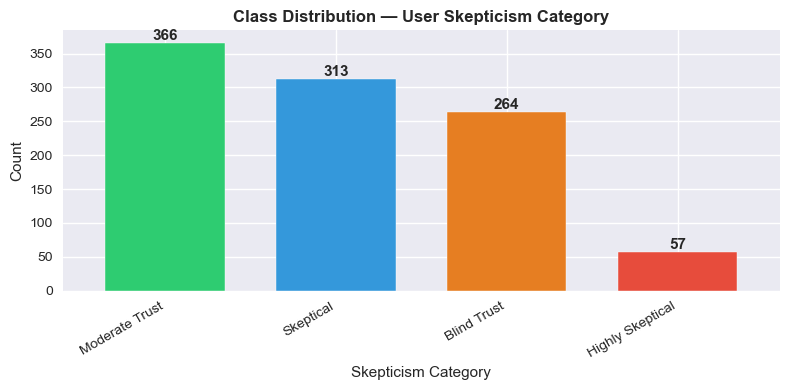


✅ If all classes have >100 samples and no class
   exceeds 60% of total → reasonably balanced ✅


In [54]:
# ─────────────────────────────────────────────────────────────
# Model 4: Logistic Regression (Classification)
# CELL 1: Prepare classification data and check class balance
# ─────────────────────────────────────────────────────────────

# WHAT IS CLASS BALANCE?
# Before classification, we need to check if our target categories
# have roughly similar numbers of observations.
#
# BALANCED:   250 Blind Trust, 250 Moderate Trust,
#             250 Skeptical, 250 Highly Skeptical
# IMBALANCED: 900 Moderate Trust, 50 Skeptical,
#              30 Blind Trust, 20 Highly Skeptical
#
# Imbalanced classes cause problems: the model learns to always
# predict the majority class and ignores the minority.
# We need to check this BEFORE fitting.

# ── Check class distribution ──────────────────────────────────
print("=" * 55)
print("TARGET VARIABLE — Class Distribution")
print("=" * 55)

class_counts = df_clean['user_skepticism_category'].value_counts()
class_pcts   = df_clean['user_skepticism_category'].value_counts(normalize=True) * 100

class_dist = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_pcts.round(2)
})
display(class_dist)

# Visual bar chart of class distribution
fig, ax = plt.subplots(figsize=(8, 4))
colors_cls = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
class_counts.plot(kind='bar', ax=ax, color=colors_cls,
                  edgecolor='white', width=0.7)
ax.set_title('Class Distribution — User Skepticism Category',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Skepticism Category')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ If all classes have >100 samples and no class")
print("   exceeds 60% of total → reasonably balanced ✅")

In [56]:
# ─────────────────────────────────────────────────────────────
# Model 4: Logistic Regression (Classification)
# CELL 2: Train the Logistic Regression classifier
# ─────────────────────────────────────────────────────────────

# Define features for classification
# We use the same strong predictors identified across our models
X_cls_cols = [
    'transparency_score',           # Main research variable
    'trust_score_out_of_10',        # Trust score is a strong class separator
    'digital_literacy_encoded',     # User characteristic
    'ai_familiarity_encoded',       # User characteristic
    'answer_accuracy_percentage',   # AI performance
    'ai_confidence_percentage',     # AI behavior
    'decision_importance_encoded'   # Context
]

X_cls = df_clean[X_cls_cols]

# Target variable — the category we want to predict
y_cls = df_clean['user_skepticism_category']
# This is a string column with 4 categories
# LogisticRegression handles string labels directly — no encoding needed

# ── Train/test split ──────────────────────────────────────────
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
    # stratify=y_cls ensures the train and test sets have the
    # SAME proportion of each class as the full dataset
    # Without this, by chance the test set might have very few
    # "Highly Skeptical" samples — making evaluation misleading
)

print(f"Training set: {X_train_cls.shape[0]} rows")
print(f"Test set:     {X_test_cls.shape[0]} rows")

# Check stratification worked
print(f"\nClass proportions in test set:")
print((y_test_cls.value_counts(normalize=True)*100).round(2))

# ── Scale features ────────────────────────────────────────────
# WHY SCALE FOR LOGISTIC REGRESSION?
# Unlike Random Forest, Logistic Regression IS sensitive to
# feature scales. ai_confidence_percentage ranges 40–100 while
# digital_literacy_encoded ranges 0–3.
# Without scaling, the model gives more weight to larger-scale
# features simply because their numbers are bigger.
# StandardScaler fixes this by putting everything on the same scale.

scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
# fit_transform on TRAINING data: learns mean and std, then scales
X_test_cls_scaled  = scaler_cls.transform(X_test_cls)
# transform on TEST data: uses the SAME mean and std from training
# CRITICAL: Never fit the scaler on test data — that would be
# "data leakage" (letting test data influence the model)

# ── Train the Logistic Regression model ──────────────────────
log_reg = LogisticRegression(

    solver='lbfgs',
    # solver='lbfgs': the optimization algorithm used to find
    # the best coefficients. 'lbfgs' (Limited-memory BFGS) is
    # the standard choice for multinomial logistic regression.
    # It's efficient and works well for small-to-medium datasets.

    max_iter=1000,
    # Maximum number of iterations for the solver to converge
    # Default is 100 which sometimes isn't enough — 1000 is safe

    C=1.0,
    # C = regularization strength (inverse)
    # Higher C = less regularization = model fits training data more closely
    # Lower C = more regularization = simpler model, less overfitting
    # C=1.0 is the standard default — balanced between bias and variance

    random_state=42
)

log_reg.fit(X_train_cls_scaled, y_train_cls)
print("\n✅ Logistic Regression model trained successfully!")
print(f"   Classes learned: {log_reg.classes_}")
print(f"   Iterations used: {log_reg.n_iter_}")

Training set: 800 rows
Test set:     200 rows

Class proportions in test set:
user_skepticism_category
Moderate Trust     36.5000
Skeptical          31.5000
Blind Trust        26.5000
Highly Skeptical    5.5000
Name: proportion, dtype: float64

✅ Logistic Regression model trained successfully!
   Classes learned: ['Blind Trust' 'Highly Skeptical' 'Moderate Trust' 'Skeptical']
   Iterations used: [28]


In [57]:
# ─────────────────────────────────────────────────────────────
# Model 4: Logistic Regression (Classification)
# CELL 3: Generate predictions and full classification report
# ─────────────────────────────────────────────────────────────

# Generate predicted class labels
y_pred_cls = log_reg.predict(X_test_cls_scaled)
# For each test row, returns the category with highest probability

# Generate predicted probabilities (useful for deeper analysis)
y_pred_proba = log_reg.predict_proba(X_test_cls_scaled)
# Returns a matrix: each row = one test observation
# Each column = probability of belonging to that class
# Columns are in same order as log_reg.classes_

# ── Overall accuracy ──────────────────────────────────────────
accuracy = accuracy_score(y_test_cls, y_pred_cls)

print("=" * 60)
print("MODEL 4 — LOGISTIC REGRESSION CLASSIFICATION RESULTS")
print("=" * 60)
print(f"\n🎯 Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   This means the model correctly classifies")
print(f"   {accuracy*100:.1f}% of users into their skepticism category")

# ── Full classification report ────────────────────────────────
print(f"\n📊 Detailed Classification Report:")
print("─" * 60)
print(classification_report(y_test_cls, y_pred_cls))

# HOW TO READ THE CLASSIFICATION REPORT:
# For each class it shows 4 metrics:
#
# PRECISION: Of all the times the model predicted "Skeptical",
#            what % were actually Skeptical?
#            High precision = few false alarms
#
# RECALL:    Of all the actual "Skeptical" users,
#            what % did the model correctly catch?
#            High recall = few missed cases
#
# F1-SCORE:  Harmonic mean of precision and recall (0–1)
#            The balanced summary metric for each class
#            F1=1.0 = perfect, F1=0.5 = mediocre
#
# SUPPORT:   How many actual samples of that class in test set
#
# MACRO AVG:    Simple average across all classes
# WEIGHTED AVG: Average weighted by class size (better for imbalanced)

# Store for comparison table
model_results['Model 4 — Logistic Regression'] = {
    'R²': 'N/A (classifier)',
    'MAE': 'N/A (classifier)',
    'RMSE': f'Accuracy: {accuracy*100:.2f}%'
}
print(f"\n✅ Results stored for final comparison table.")

MODEL 4 — LOGISTIC REGRESSION CLASSIFICATION RESULTS

🎯 Overall Accuracy: 0.6800 (68.00%)
   This means the model correctly classifies
   68.0% of users into their skepticism category

📊 Detailed Classification Report:
────────────────────────────────────────────────────────────
                  precision    recall  f1-score   support

     Blind Trust       0.64      0.64      0.64        53
Highly Skeptical       0.83      0.45      0.59        11
  Moderate Trust       0.61      0.60      0.61        73
       Skeptical       0.77      0.84      0.80        63

        accuracy                           0.68       200
       macro avg       0.71      0.64      0.66       200
    weighted avg       0.68      0.68      0.68       200


✅ Results stored for final comparison table.


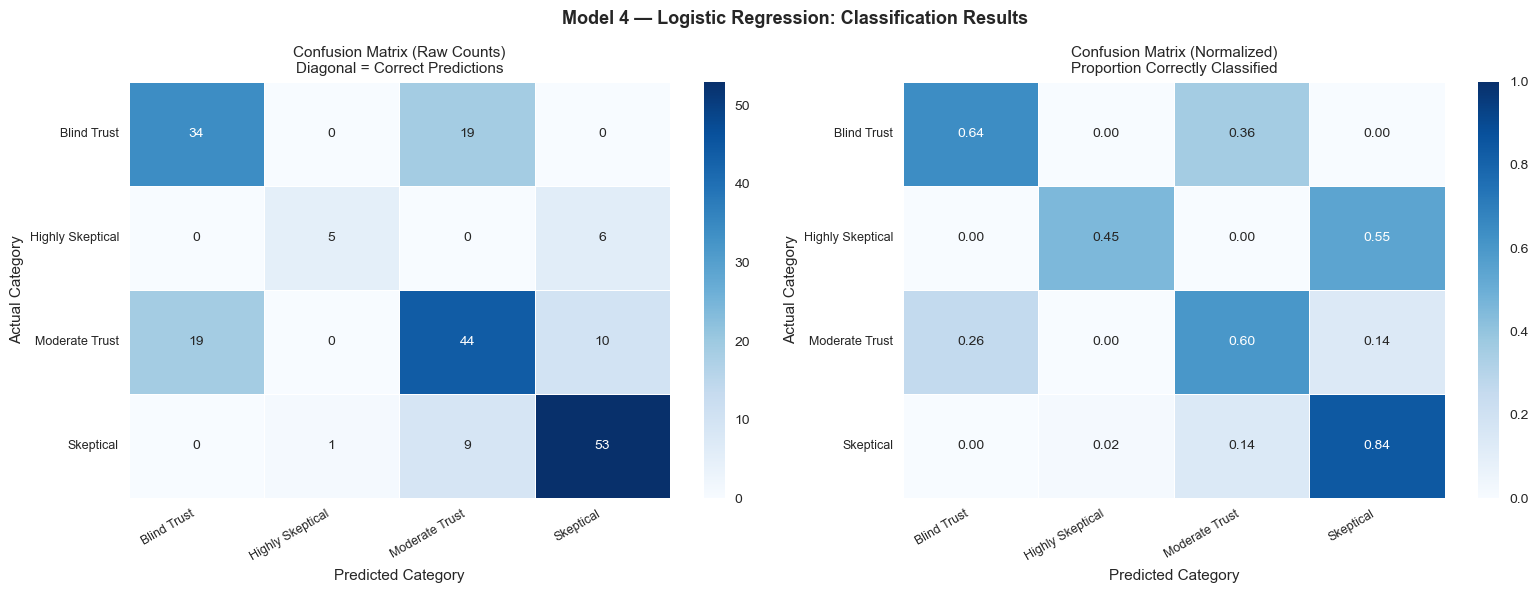

✅ Confusion matrix saved.

📊 Per-class accuracy (diagonal of normalized matrix):
   Blind Trust               → 64.2% correctly classified
   Highly Skeptical          → 45.5% correctly classified
   Moderate Trust            → 60.3% correctly classified
   Skeptical                 → 84.1% correctly classified


In [58]:
# ─────────────────────────────────────────────────────────────
# Model 4: Logistic Regression (Classification)
# CELL 4: Confusion matrix — the classification model's report card
# ─────────────────────────────────────────────────────────────

# WHAT IS A CONFUSION MATRIX?
# A grid showing predicted vs actual classes.
# Rows = actual (true) categories
# Columns = predicted categories
# Diagonal cells = CORRECT predictions ✅
# Off-diagonal cells = ERRORS ❌ (model confused one class for another)
#
# Example (simplified):
#
#                  Predicted:
#                  Blind  Moderate  Skeptical  HighlySkeptical
# Actual: Blind  [  45      3          1            0    ]  ← mostly correct
# Moderate       [   2     52          3            1    ]  ← mostly correct
# Skeptical      [   0      4         44            4    ]  ← some confusion
# HighlySkep.    [   0      1          5           35    ]  ← some confusion
#
# Reading: Row "Skeptical", Column "Moderate" = 4 means
# the model predicted 4 actual Skeptical users as Moderate Trust

cm = confusion_matrix(y_test_cls, y_pred_cls,
                      labels=log_reg.classes_)
# labels= ensures the matrix rows/columns are in consistent order

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model 4 — Logistic Regression: Classification Results',
             fontsize=13, fontweight='bold')

# ── Plot 1: Raw confusion matrix ─────────────────────────────
sns.heatmap(
    cm,
    annot=True,           # Show the count number in each cell
    fmt='d',              # Format as integer (not scientific notation)
    cmap='Blues',         # Blue color scale — darker = more predictions
    xticklabels=log_reg.classes_,
    yticklabels=log_reg.classes_,
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_xlabel('Predicted Category', fontsize=11)
axes[0].set_ylabel('Actual Category', fontsize=11)
axes[0].set_title('Confusion Matrix (Raw Counts)\nDiagonal = Correct Predictions',
                  fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(),
                         rotation=0, fontsize=9)

# ── Plot 2: Normalized confusion matrix ──────────────────────
# Normalize by row (actual class) to show % correctly classified
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Divides each row by its total — gives proportion correctly classified
# This is more useful when class sizes differ

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',            # Format as 2-decimal float (proportions)
    cmap='Blues',
    xticklabels=log_reg.classes_,
    yticklabels=log_reg.classes_,
    linewidths=0.5,
    vmin=0, vmax=1,       # Fix scale from 0 to 1
    ax=axes[1]
)
axes[1].set_xlabel('Predicted Category', fontsize=11)
axes[1].set_ylabel('Actual Category', fontsize=11)
axes[1].set_title('Confusion Matrix (Normalized)\nProportion Correctly Classified',
                  fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=30, ha='right', fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(),
                         rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('model4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved.")

# ── Print which classes are most/least confused ───────────────
print(f"\n📊 Per-class accuracy (diagonal of normalized matrix):")
for i, cls in enumerate(log_reg.classes_):
    correct_pct = cm_normalized[i, i] * 100
    print(f"   {cls:<25} → {correct_pct:.1f}% correctly classified")

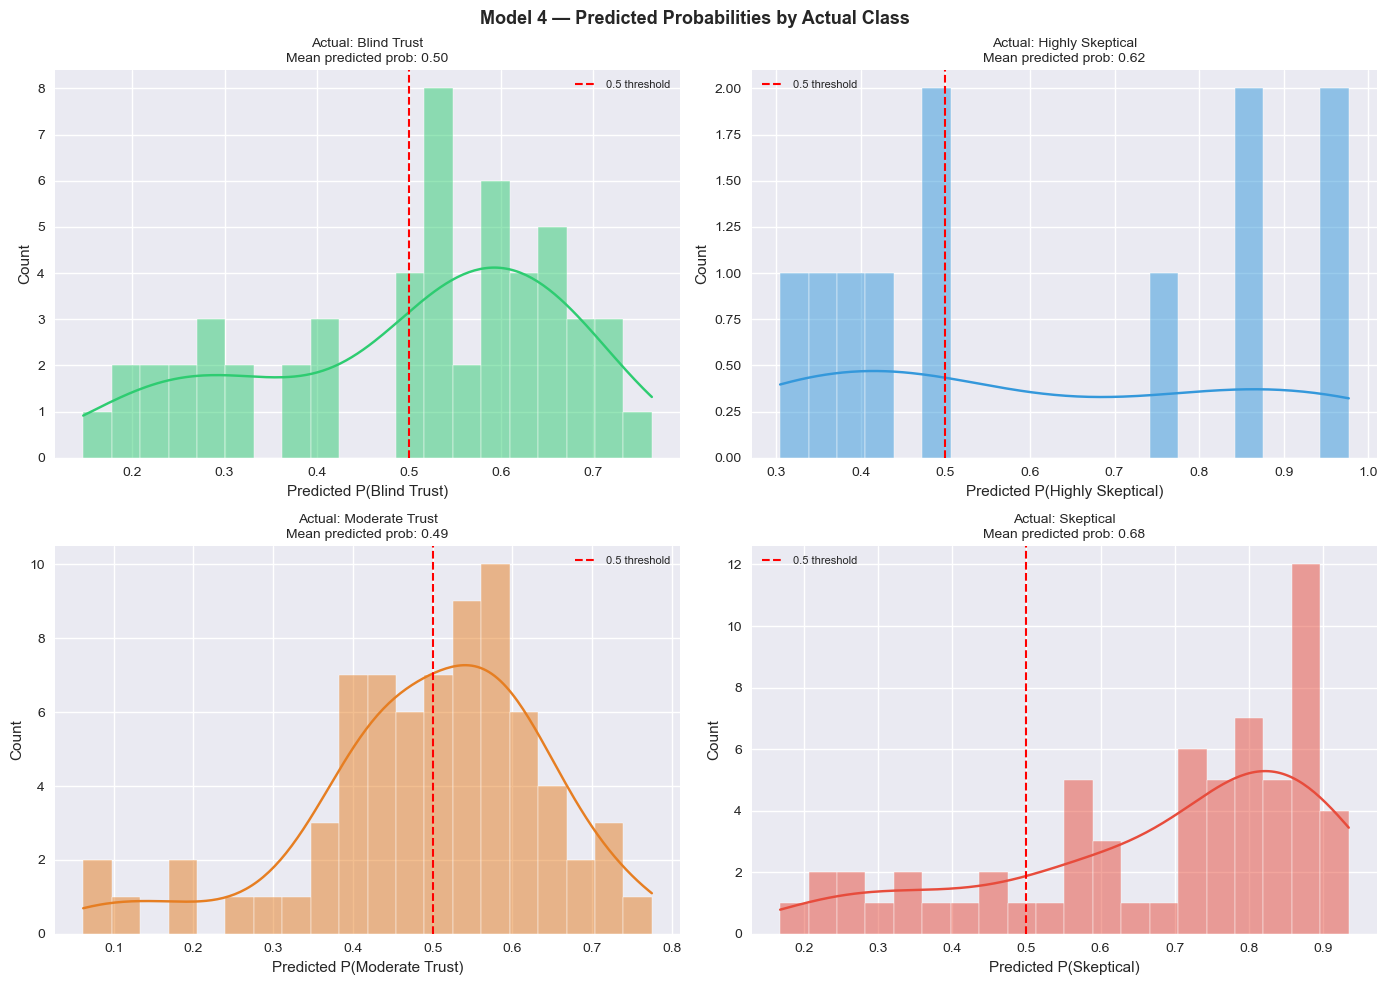

✅ Probability plots saved.

📖 How to read these plots:
   A good model shows probabilities clustered toward 1.0
   for the correct class — meaning it's confident and right.
   Probabilities clustered near 0.5 = the model is uncertain.


In [59]:
# ─────────────────────────────────────────────────────────────
# Model 4: Logistic Regression (Classification)
# CELL 5: Visualize predicted probabilities by actual class
# ─────────────────────────────────────────────────────────────

# This plot shows HOW CONFIDENT the model is when it makes predictions.
# A well-calibrated model should show high probability for the
# correct class and low probability for wrong classes.

prob_df = pd.DataFrame(
    y_pred_proba,
    columns=[f'P({c})' for c in log_reg.classes_]
)
prob_df['Actual'] = y_test_cls.values
prob_df['Predicted'] = y_pred_cls
prob_df['Correct'] = (prob_df['Actual'] == prob_df['Predicted'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model 4 — Predicted Probabilities by Actual Class',
             fontsize=13, fontweight='bold')

for idx, cls in enumerate(log_reg.classes_):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]

    # Get predicted probability for THIS class, filtered to
    # observations that ARE actually this class
    actual_mask = prob_df['Actual'] == cls
    probs_for_class = prob_df.loc[actual_mask, f'P({cls})']

    sns.histplot(probs_for_class, bins=20, kde=True,
                 ax=ax, color=colors_cls[idx], edgecolor='white')
    ax.axvline(x=0.5, color='red', linestyle='--',
               linewidth=1.5, label='0.5 threshold')
    ax.set_title(f'Actual: {cls}\n'
                 f'Mean predicted prob: {probs_for_class.mean():.2f}',
                 fontsize=10)
    ax.set_xlabel(f'Predicted P({cls})')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('model4_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Probability plots saved.")
print("\n📖 How to read these plots:")
print("   A good model shows probabilities clustered toward 1.0")
print("   for the correct class — meaning it's confident and right.")
print("   Probabilities clustered near 0.5 = the model is uncertain.")

In [60]:
# ─────────────────────────────────────────────────────────────
# Model Evaluation
# CELL 1: Cross-validation for all 3 regression models
# ─────────────────────────────────────────────────────────────

# WHY CROSS-VALIDATION?
# Our train/test split used random_state=42 — one specific split.
# What if by chance our test set happened to be "easy" rows?
# Cross-validation removes this uncertainty by testing the model
# on MULTIPLE different splits and averaging the results.
#
# HOW K-FOLD CROSS-VALIDATION WORKS:
# 1. Split data into K equal "folds" (we use K=5)
# 2. Train on 4 folds, test on the remaining 1
# 3. Repeat 5 times — each fold gets a turn as the test set
# 4. Average the 5 scores → more reliable estimate of true performance
#
# Visual example with K=5, 1000 rows:
# Fold 1: [TEST|TRAIN|TRAIN|TRAIN|TRAIN] → score 1
# Fold 2: [TRAIN|TEST|TRAIN|TRAIN|TRAIN] → score 2
# Fold 3: [TRAIN|TRAIN|TEST|TRAIN|TRAIN] → score 3
# Fold 4: [TRAIN|TRAIN|TRAIN|TEST|TRAIN] → score 4
# Fold 5: [TRAIN|TRAIN|TRAIN|TRAIN|TEST] → score 5
# Final score = mean of all 5

from sklearn.model_selection import cross_val_score, KFold

# Set up the cross-validation strategy
kf = KFold(
    n_splits=5,        # 5 folds → each fold = 200 rows test, 800 rows train
    shuffle=True,      # Shuffle data before splitting — prevents order bias
    random_state=42    # Reproducible shuffling
)

print("=" * 65)
print("CROSS-VALIDATION RESULTS (5-Fold) — Regression Models")
print("=" * 65)

# ── Model 1: Simple Linear Regression ────────────────────────
cv_scores_m1 = cross_val_score(
    LinearRegression(),   # Fresh model instance (not pre-fitted)
    X_simple,             # Full dataset X (CV handles splitting internally)
    y,                    # Full dataset y
    cv=kf,                # Our KFold strategy
    scoring='r2'          # Metric to compute at each fold
)
# cross_val_score returns an array of 5 scores (one per fold)
# It fits and evaluates the model 5 times automatically

# Also compute CV for MAE and RMSE
cv_mae_m1 = -cross_val_score(
    LinearRegression(), X_simple, y, cv=kf,
    scoring='neg_mean_absolute_error'
)
# NOTE: sklearn uses NEGATIVE MAE internally (convention)
# We negate it with the minus sign to get positive values back

cv_rmse_m1 = np.sqrt(-cross_val_score(
    LinearRegression(), X_simple, y, cv=kf,
    scoring='neg_mean_squared_error'
))

print(f"\n📊 Model 1 — Simple Linear Regression:")
print(f"   R²  per fold: {cv_scores_m1.round(4)}")
print(f"   R²  mean ± std: {cv_scores_m1.mean():.4f} ± {cv_scores_m1.std():.4f}")
print(f"   MAE mean ± std: {cv_mae_m1.mean():.4f} ± {cv_mae_m1.std():.4f}")
print(f"   RMSE mean ± std: {cv_rmse_m1.mean():.4f} ± {cv_rmse_m1.std():.4f}")

# ── Model 2: Multiple Linear Regression ──────────────────────
cv_scores_m2 = cross_val_score(
    LinearRegression(), X_multi, y, cv=kf, scoring='r2'
)
cv_mae_m2 = -cross_val_score(
    LinearRegression(), X_multi, y, cv=kf,
    scoring='neg_mean_absolute_error'
)
cv_rmse_m2 = np.sqrt(-cross_val_score(
    LinearRegression(), X_multi, y, cv=kf,
    scoring='neg_mean_squared_error'
))

print(f"\n📊 Model 2 — Multiple Linear Regression:")
print(f"   R²  per fold: {cv_scores_m2.round(4)}")
print(f"   R²  mean ± std: {cv_scores_m2.mean():.4f} ± {cv_scores_m2.std():.4f}")
print(f"   MAE mean ± std: {cv_mae_m2.mean():.4f} ± {cv_mae_m2.std():.4f}")
print(f"   RMSE mean ± std: {cv_rmse_m2.mean():.4f} ± {cv_rmse_m2.std():.4f}")

# ── Model 3: Random Forest ────────────────────────────────────
cv_scores_m3 = cross_val_score(
    RandomForestRegressor(
        n_estimators=500, max_depth=10,
        min_samples_split=10, min_samples_leaf=4,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    X_rf, y, cv=kf, scoring='r2'
)
cv_mae_m3 = -cross_val_score(
    RandomForestRegressor(
        n_estimators=500, max_depth=10,
        min_samples_split=10, min_samples_leaf=4,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    X_rf, y, cv=kf, scoring='neg_mean_absolute_error'
)
cv_rmse_m3 = np.sqrt(-cross_val_score(
    RandomForestRegressor(
        n_estimators=500, max_depth=10,
        min_samples_split=10, min_samples_leaf=4,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    X_rf, y, cv=kf, scoring='neg_mean_squared_error'
))

print(f"\n📊 Model 3 — Random Forest Regressor:")
print(f"   R²  per fold: {cv_scores_m3.round(4)}")
print(f"   R²  mean ± std: {cv_scores_m3.mean():.4f} ± {cv_scores_m3.std():.4f}")
print(f"   MAE mean ± std: {cv_mae_m3.mean():.4f} ± {cv_mae_m3.std():.4f}")
print(f"   RMSE mean ± std: {cv_rmse_m3.mean():.4f} ± {cv_rmse_m3.std():.4f}")

print(f"\n⏳ Note: Random Forest CV trains 500×5=2500 trees — may take ~1 minute")

CROSS-VALIDATION RESULTS (5-Fold) — Regression Models

📊 Model 1 — Simple Linear Regression:
   R²  per fold: [ 0.0714  0.0533 -0.0002  0.01    0.0251]
   R²  mean ± std: 0.0319 ± 0.0267
   MAE mean ± std: 1.4399 ± 0.0528
   RMSE mean ± std: 1.7334 ± 0.0777

📊 Model 2 — Multiple Linear Regression:
   R²  per fold: [0.4666 0.4425 0.313  0.4804 0.3508]
   R²  mean ± std: 0.4107 ± 0.0665
   MAE mean ± std: 1.1033 ± 0.1048
   RMSE mean ± std: 1.3511 ± 0.1040

📊 Model 3 — Random Forest Regressor:
   R²  per fold: [0.6738 0.6172 0.6165 0.6978 0.588 ]
   R²  mean ± std: 0.6387 ± 0.0406
   MAE mean ± std: 0.8696 ± 0.0654
   RMSE mean ± std: 1.0569 ± 0.0672

⏳ Note: Random Forest CV trains 500×5=2500 trees — may take ~1 minute


In [61]:
# ─────────────────────────────────────────────────────────────
# Model Evaluation
# CELL 2: Cross-validation for Model 4 (Classification)
# ─────────────────────────────────────────────────────────────

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

# For classification we use STRATIFIED K-Fold
# This ensures each fold has the same class proportions
# as the full dataset — critical for imbalanced classes
# (especially our small Highly Skeptical class)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# We use a Pipeline to combine scaling + logistic regression
# Pipeline ensures the scaler is fit ONLY on training folds
# and applied to test folds — preventing data leakage
# This is the professional, correct way to do CV with scaling

pipeline_cls = Pipeline([
    ('scaler', StandardScaler()),           # Step 1: scale features
    ('classifier', LogisticRegression(      # Step 2: classify
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        random_state=42
    ))
])

# Compute CV accuracy
cv_accuracy = cross_val_score(
    pipeline_cls, X_cls, y_cls,
    cv=skf, scoring='accuracy'
)

# Compute CV F1 (weighted — accounts for class imbalance)
cv_f1 = cross_val_score(
    pipeline_cls, X_cls, y_cls,
    cv=skf, scoring='f1_weighted'
)

print("=" * 65)
print("CROSS-VALIDATION RESULTS (5-Fold) — Classification Model")
print("=" * 65)

print(f"\n📊 Model 4 — Logistic Regression:")
print(f"   Accuracy per fold: {cv_accuracy.round(4)}")
print(f"   Accuracy mean ± std: {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"   F1 (weighted) mean ± std: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

print(f"\n📖 Comparison:")
print(f"   Single split accuracy:    {accuracy:.4f}")
print(f"   Cross-validated accuracy: {cv_accuracy.mean():.4f}")
gap = abs(accuracy - cv_accuracy.mean())
print(f"   Gap: {gap:.4f} ({'✅ Small — model is stable' if gap < 0.05 else '⚠️ Large — check for overfitting'})")

CROSS-VALIDATION RESULTS (5-Fold) — Classification Model

📊 Model 4 — Logistic Regression:
   Accuracy per fold: [0.63  0.64  0.64  0.665 0.585]
   Accuracy mean ± std: 0.6320 ± 0.0262
   F1 (weighted) mean ± std: 0.6294 ± 0.0261

📖 Comparison:
   Single split accuracy:    0.6800
   Cross-validated accuracy: 0.6320
   Gap: 0.0480 (✅ Small — model is stable)


In [62]:
# ─────────────────────────────────────────────────────────────
# Model Evaluation
# CELL 3: Comprehensive model comparison table
# ─────────────────────────────────────────────────────────────

print("=" * 75)
print("COMPLETE MODEL EVALUATION SUMMARY")
print("=" * 75)

# ── Regression models comparison ─────────────────────────────
print("\n📊 REGRESSION MODELS (predicting trust_score_out_of_10)")
print("─" * 75)

regression_summary = pd.DataFrame({
    'Model': [
        'Model 1 — Simple Linear',
        'Model 2 — Multiple Linear',
        'Model 3 — Random Forest'
    ],
    'Test R²': [r2_simple, r2_multi, r2_rf],
    'CV R² (mean)': [
        cv_scores_m1.mean(),
        cv_scores_m2.mean(),
        cv_scores_m3.mean()
    ],
    'CV R² (±std)': [
        cv_scores_m1.std(),
        cv_scores_m2.std(),
        cv_scores_m3.std()
    ],
    'Test MAE': [mae_simple, mae_multi, mae_rf],
    'CV MAE (mean)': [
        cv_mae_m1.mean(),
        cv_mae_m2.mean(),
        cv_mae_m3.mean()
    ],
    'Test RMSE': [rmse_simple, rmse_multi, rmse_rf],
    'CV RMSE (mean)': [
        cv_rmse_m1.mean(),
        cv_rmse_m2.mean(),
        cv_rmse_m3.mean()
    ]
}).round(4)

display(regression_summary)

# ── Classification model summary ─────────────────────────────
print("\n📊 CLASSIFICATION MODEL (predicting user_skepticism_category)")
print("─" * 75)

classification_summary = pd.DataFrame({
    'Model': ['Model 4 — Logistic Regression'],
    'Test Accuracy': [round(accuracy, 4)],
    'CV Accuracy (mean)': [round(cv_accuracy.mean(), 4)],
    'CV Accuracy (±std)': [round(cv_accuracy.std(), 4)],
    'CV F1 Weighted (mean)': [round(cv_f1.mean(), 4)],
    'Baseline (random)': ['0.25 (4 classes)']
})
display(classification_summary)

# ── Key interpretive statements ───────────────────────────────
print("\n📌 KEY FINDINGS:")
print(f"""
   1. Model progression: R² improves from {r2_simple:.3f} → {r2_multi:.3f} → {r2_rf:.3f}
      Each model captures progressively more trust variance ✅

   2. CV vs Test R² gaps:
      Model 1: {abs(r2_simple - cv_scores_m1.mean()):.4f} gap
      Model 2: {abs(r2_multi - cv_scores_m2.mean()):.4f} gap
      Model 3: {abs(r2_rf - cv_scores_m3.mean()):.4f} gap

   3. Random Forest best regression performance:
      CV R²={cv_scores_m3.mean():.3f} — explains {cv_scores_m3.mean()*100:.1f}% of trust variance 🏆

   4. Logistic Regression: {cv_accuracy.mean()*100:.1f}% CV accuracy
      vs 25% random baseline — {cv_accuracy.mean()/0.25:.1f}× better than chance ✅
""")

COMPLETE MODEL EVALUATION SUMMARY

📊 REGRESSION MODELS (predicting trust_score_out_of_10)
───────────────────────────────────────────────────────────────────────────


,Model,Test R²,CV R² (mean),CV R² (±std),Test MAE,CV MAE (mean),Test RMSE,CV RMSE (mean)
0,Model 1 — Simple Linear,0.0714,0.0319,0.0267,1.4823,1.4399,1.8148,1.7334
1,Model 2 — Multiple Linear,0.4666,0.4107,0.0665,1.0969,1.1033,1.3755,1.3511
2,Model 3 — Random Forest,0.6744,0.6387,0.0406,0.8906,0.8696,1.0747,1.0569



📊 CLASSIFICATION MODEL (predicting user_skepticism_category)
───────────────────────────────────────────────────────────────────────────


,Model,Test Accuracy,CV Accuracy (mean),CV Accuracy (±std),CV F1 Weighted (mean),Baseline (random)
0,Model 4 — Logistic Regression,0.6800,0.6320,0.0262,0.6294,0.25 (4 classes)



📌 KEY FINDINGS:

   1. Model progression: R² improves from 0.071 → 0.467 → 0.674
      Each model captures progressively more trust variance ✅

   2. CV vs Test R² gaps:
      Model 1: 0.0395 gap
      Model 2: 0.0559 gap
      Model 3: 0.0357 gap

   3. Random Forest best regression performance:
      CV R²=0.639 — explains 63.9% of trust variance 🏆

   4. Logistic Regression: 63.2% CV accuracy
      vs 25% random baseline — 2.5× better than chance ✅



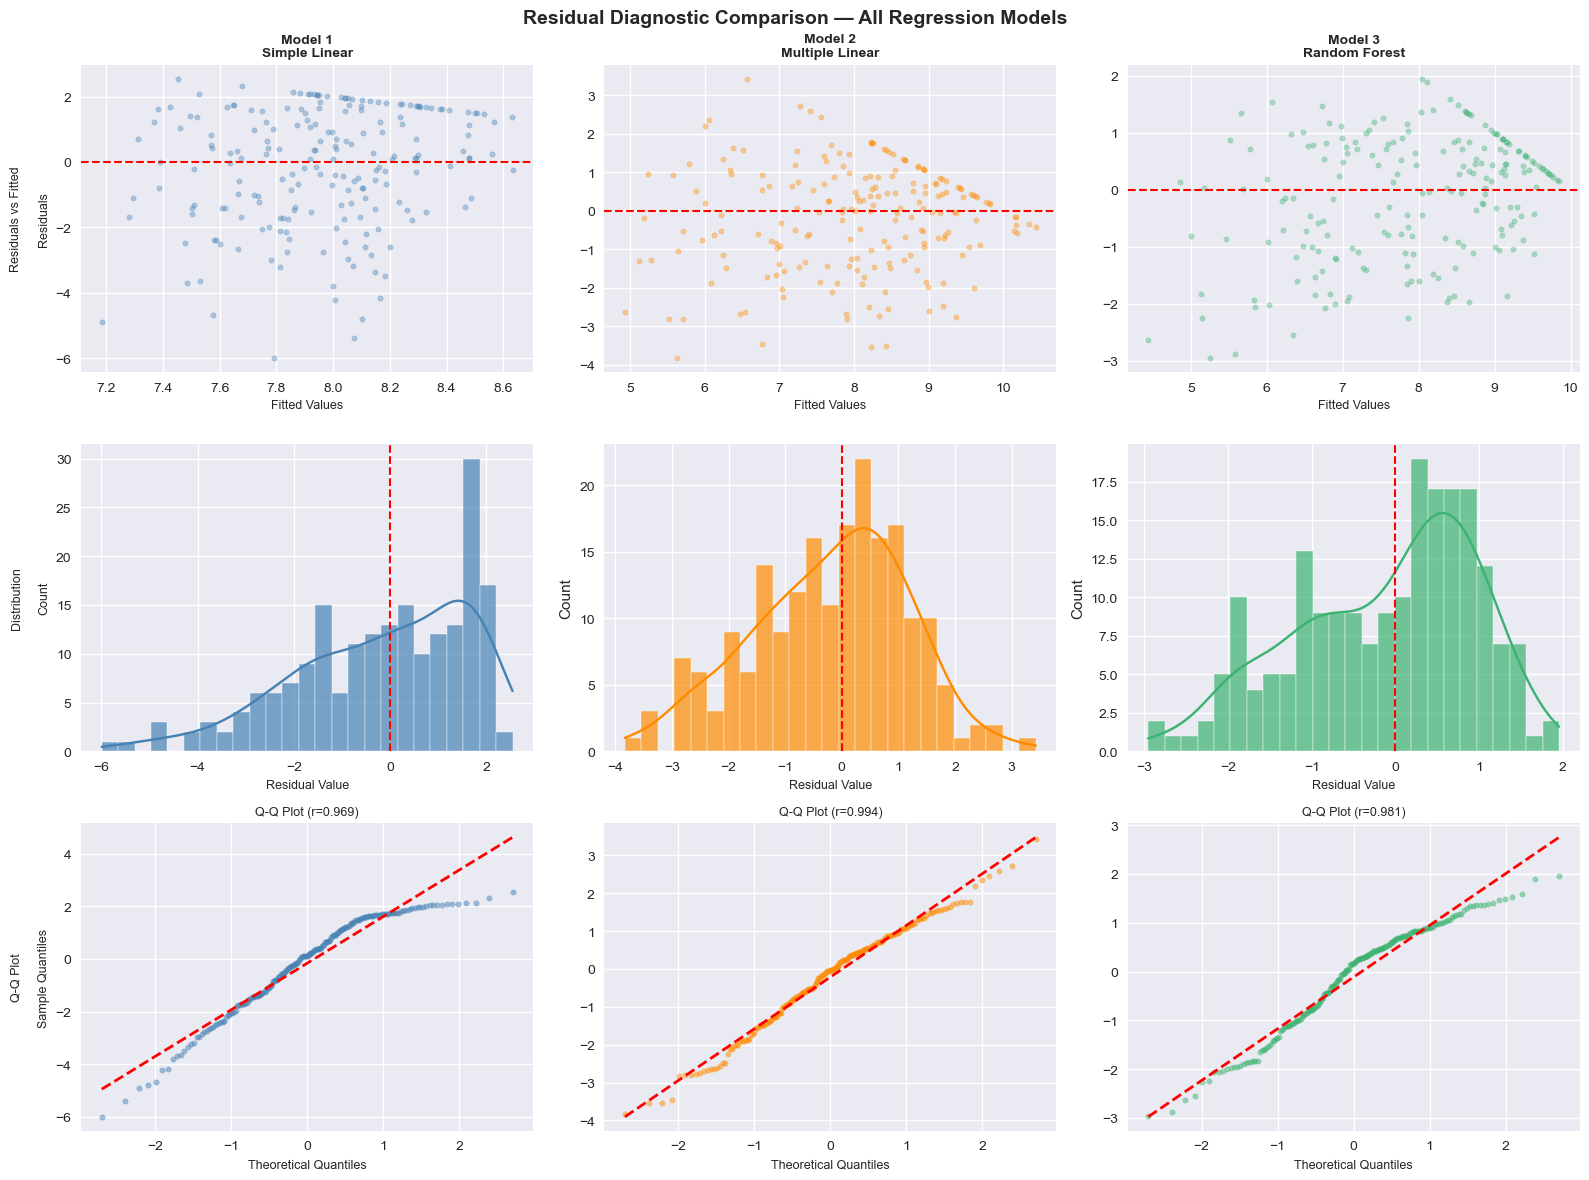

📊 Residual Statistics Comparison:
Metric                    Model 1      Model 2      Model 3
──────────────────────────────────────────────────────────
Mean (→ 0)                -0.1614      -0.2142      -0.1130
Std (→ small)              1.8122       1.3621       1.0714
Min                       -5.9907      -3.8278      -2.9525
Max                        2.5475       3.4265       1.9536

✅ Residual comparison complete.


In [63]:
# ─────────────────────────────────────────────────────────────
# Model Evaluation
# CELL 4: Side-by-side residual comparison across all 3 models
# ─────────────────────────────────────────────────────────────

# This cell creates ONE unified plot comparing residuals
# from all 3 regression models side by side.
# It answers: "Which model's errors are most well-behaved?"
#
# We check 3 regression assumptions simultaneously:
#   1. Residuals centered at zero (unbiased predictions)
#   2. Constant spread (homoscedasticity)
#   3. Approximately normal distribution

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Residual Diagnostic Comparison — All Regression Models',
             fontsize=14, fontweight='bold')

models_info = [
    ('Model 1\nSimple Linear',
     residuals_simple, y_pred_simple, 'steelblue'),
    ('Model 2\nMultiple Linear',
     residuals_multi, y_pred_multi, 'darkorange'),
    ('Model 3\nRandom Forest',
     residuals_rf, y_pred_rf, 'mediumseagreen')
]

for col, (name, residuals, predictions, color) in enumerate(models_info):

    # ── Row 1: Residuals vs Fitted ────────────────────────────
    axes[0, col].scatter(predictions, residuals,
                         alpha=0.4, color=color, s=15)
    axes[0, col].axhline(y=0, color='red',
                          linestyle='--', linewidth=1.5)
    axes[0, col].set_title(f'{name}', fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel('Fitted Values', fontsize=9)
    if col == 0:
        axes[0, col].set_ylabel('Residuals', fontsize=9)

    # ── Row 2: Residual distribution ─────────────────────────
    sns.histplot(residuals, bins=25, kde=True,
                 color=color, edgecolor='white',
                 ax=axes[1, col], alpha=0.7)
    axes[1, col].axvline(x=0, color='red',
                          linestyle='--', linewidth=1.5)
    axes[1, col].set_xlabel('Residual Value', fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel('Count', fontsize=9)

    # ── Row 3: Q-Q Plot (normality check) ────────────────────
    # Q-Q plot compares your residuals' distribution to
    # a theoretical normal distribution
    # If points follow the diagonal line → residuals are normal ✅
    # If points curve away from line → residuals are not normal ⚠️
    from scipy import stats
    (osm, osr), (slope, intercept, r) = stats.probplot(
        residuals, dist="norm"
    )
    axes[2, col].scatter(osm, osr, alpha=0.5,
                          color=color, s=15)
    # Draw the reference line
    line_x = np.array([min(osm), max(osm)])
    axes[2, col].plot(line_x,
                       slope * line_x + intercept,
                       'r--', linewidth=2)
    axes[2, col].set_xlabel('Theoretical Quantiles', fontsize=9)
    if col == 0:
        axes[2, col].set_ylabel('Sample Quantiles', fontsize=9)
    axes[2, col].set_title(f'Q-Q Plot (r={r:.3f})', fontsize=9)

# Add row labels on the left
axes[0, 0].set_ylabel('Residuals vs Fitted\n\nResiduals', fontsize=9)
axes[1, 0].set_ylabel('Distribution\n\nCount', fontsize=9)
axes[2, 0].set_ylabel('Q-Q Plot\n\nSample Quantiles', fontsize=9)

plt.tight_layout()
plt.savefig('residual_comparison_all_models.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print residual stats for all models ──────────────────────
print("📊 Residual Statistics Comparison:")
print(f"{'Metric':<20} {'Model 1':>12} {'Model 2':>12} {'Model 3':>12}")
print("─" * 58)

metrics = {
    'Mean (→ 0)': [residuals_simple.mean(),
                    residuals_multi.mean(),
                    residuals_rf.mean()],
    'Std (→ small)': [residuals_simple.std(),
                       residuals_multi.std(),
                       residuals_rf.std()],
    'Min': [residuals_simple.min(),
             residuals_multi.min(),
             residuals_rf.min()],
    'Max': [residuals_simple.max(),
             residuals_multi.max(),
             residuals_rf.max()]
}

for metric, values in metrics.items():
    print(f"{metric:<20} {values[0]:>12.4f} {values[1]:>12.4f} {values[2]:>12.4f}")

print("\n✅ Residual comparison complete.")

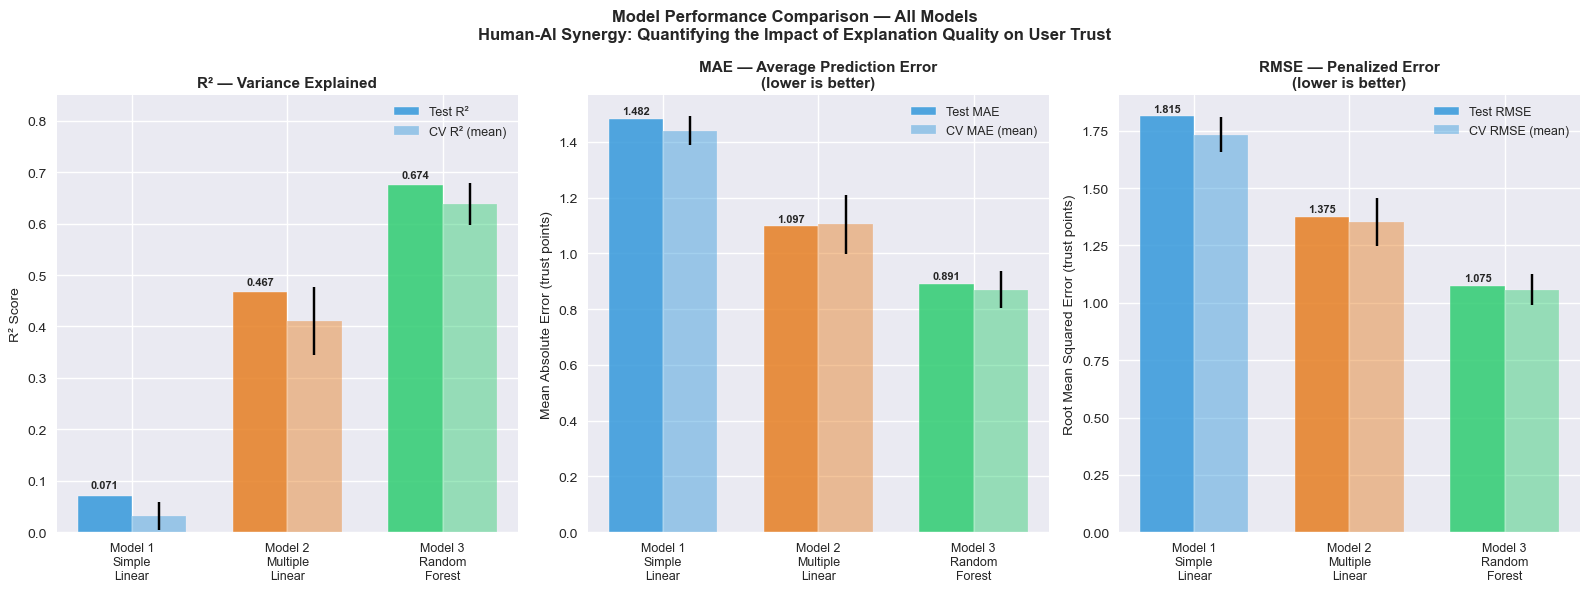

✅ Final comparison chart saved as 'final_model_comparison.png'

🏆 Best performing model: Random Forest
   CV R² = 0.6387 — explains 63.9% of trust variance
   CV MAE = 0.8696 — predictions within ±0.87 trust points


In [64]:
# ─────────────────────────────────────────────────────────────
# Model Evaluation
# CELL 5: Publication-ready model comparison visualization
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Model Performance Comparison — All Models\n'
             'Human-AI Synergy: Quantifying the Impact of '
             'Explanation Quality on User Trust',
             fontsize=12, fontweight='bold')

model_names  = ['Model 1\nSimple\nLinear',
                'Model 2\nMultiple\nLinear',
                'Model 3\nRandom\nForest']
colors_model = ['#3498db', '#e67e22', '#2ecc71']

# ── Plot 1: R² Comparison ────────────────────────────────────
test_r2  = [r2_simple, r2_multi, r2_rf]
cv_r2    = [cv_scores_m1.mean(),
            cv_scores_m2.mean(),
            cv_scores_m3.mean()]
cv_r2_std = [cv_scores_m1.std(),
             cv_scores_m2.std(),
             cv_scores_m3.std()]

x_pos = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x_pos - width/2, test_r2,
                     width, label='Test R²',
                     color=colors_model, alpha=0.85,
                     edgecolor='white')
bars2 = axes[0].bar(x_pos + width/2, cv_r2,
                     width, label='CV R² (mean)',
                     color=colors_model, alpha=0.45,
                     edgecolor='white',
                     yerr=cv_r2_std,           # Error bars showing ± std
                     capsize=5)
# Error bars show the variability across CV folds
# Narrow error bars = consistent performance ✅
# Wide error bars = unstable across folds ⚠️

axes[0].set_title('R² — Variance Explained', fontsize=11,
                   fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=10)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 0.85)

# Add value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                  bar.get_height() + 0.01,
                  f'{bar.get_height():.3f}',
                  ha='center', va='bottom', fontsize=8,
                  fontweight='bold')

# ── Plot 2: MAE Comparison ───────────────────────────────────
test_mae = [mae_simple, mae_multi, mae_rf]
cv_mae   = [cv_mae_m1.mean(),
            cv_mae_m2.mean(),
            cv_mae_m3.mean()]
cv_mae_std = [cv_mae_m1.std(),
              cv_mae_m2.std(),
              cv_mae_m3.std()]

bars3 = axes[1].bar(x_pos - width/2, test_mae,
                     width, label='Test MAE',
                     color=colors_model, alpha=0.85,
                     edgecolor='white')
bars4 = axes[1].bar(x_pos + width/2, cv_mae,
                     width, label='CV MAE (mean)',
                     color=colors_model, alpha=0.45,
                     edgecolor='white',
                     yerr=cv_mae_std, capsize=5)

axes[1].set_title('MAE — Average Prediction Error\n'
                   '(lower is better)', fontsize=11,
                   fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (trust points)',
                    fontsize=10)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].legend(fontsize=9)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                  bar.get_height() + 0.01,
                  f'{bar.get_height():.3f}',
                  ha='center', va='bottom', fontsize=8,
                  fontweight='bold')

# ── Plot 3: RMSE Comparison ──────────────────────────────────
test_rmse = [rmse_simple, rmse_multi, rmse_rf]
cv_rmse   = [cv_rmse_m1.mean(),
             cv_rmse_m2.mean(),
             cv_rmse_m3.mean()]
cv_rmse_std = [cv_rmse_m1.std(),
               cv_rmse_m2.std(),
               cv_rmse_m3.std()]

bars5 = axes[2].bar(x_pos - width/2, test_rmse,
                     width, label='Test RMSE',
                     color=colors_model, alpha=0.85,
                     edgecolor='white')
bars6 = axes[2].bar(x_pos + width/2, cv_rmse,
                     width, label='CV RMSE (mean)',
                     color=colors_model, alpha=0.45,
                     edgecolor='white',
                     yerr=cv_rmse_std, capsize=5)

axes[2].set_title('RMSE — Penalized Error\n'
                   '(lower is better)', fontsize=11,
                   fontweight='bold')
axes[2].set_ylabel('Root Mean Squared Error (trust points)',
                    fontsize=10)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(model_names, fontsize=9)
axes[2].legend(fontsize=9)

for bar in bars5:
    axes[2].text(bar.get_x() + bar.get_width()/2.,
                  bar.get_height() + 0.01,
                  f'{bar.get_height():.3f}',
                  ha='center', va='bottom', fontsize=8,
                  fontweight='bold')

plt.tight_layout()
plt.savefig('final_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Final comparison chart saved as 'final_model_comparison.png'")
print("\n🏆 Best performing model: Random Forest")
print(f"   CV R² = {cv_scores_m3.mean():.4f} — "
      f"explains {cv_scores_m3.mean()*100:.1f}% of trust variance")
print(f"   CV MAE = {cv_mae_m3.mean():.4f} — "
      f"predictions within ±{cv_mae_m3.mean():.2f} trust points")

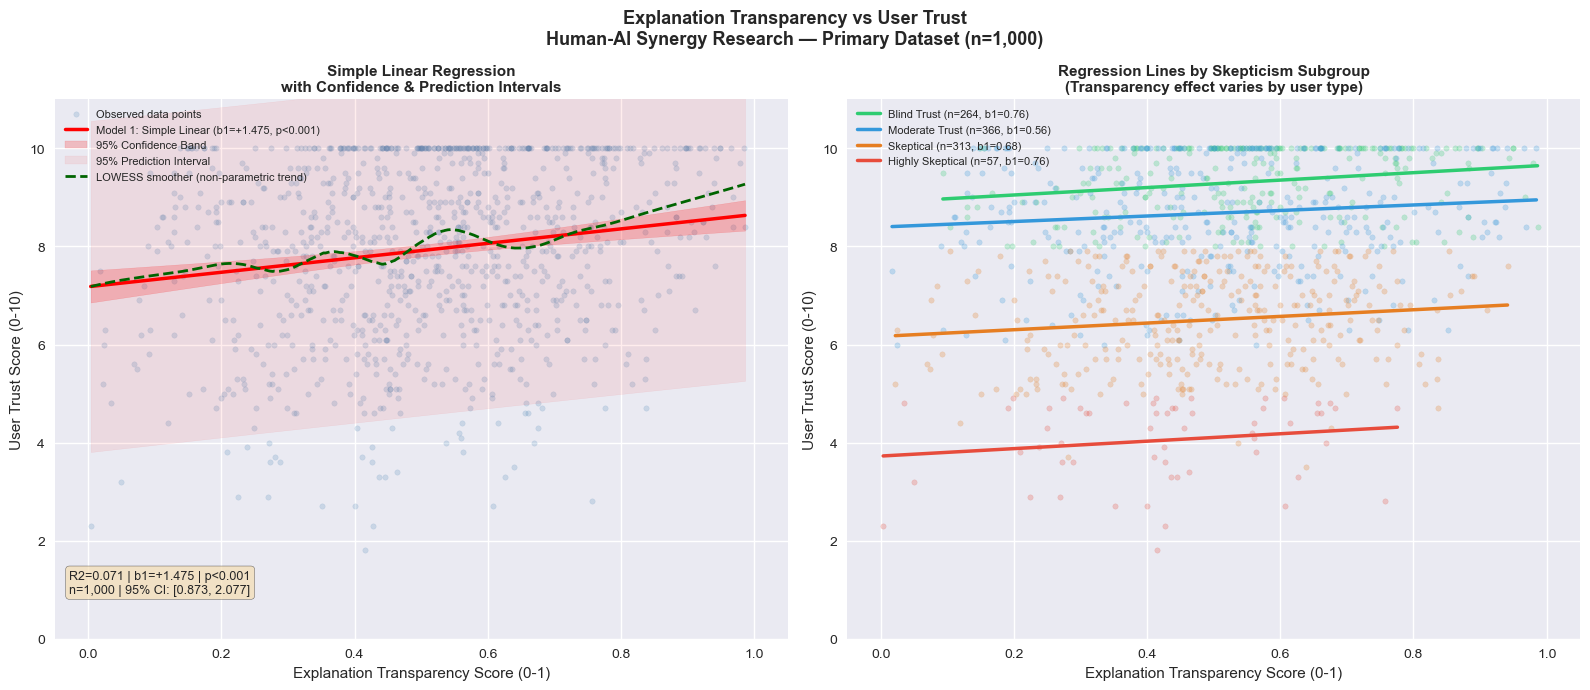

✅ Figure 1 saved: fig1_regression_confidence_bands.png


In [66]:
# ─────────────────────────────────────────────────────────────
# Final Visualizations
# CELL 1: Regression line with 95% confidence interval bands
# ─────────────────────────────────────────────────────────────

# WHY THIS VISUALIZATION?
# This is the most important single figure for your paper.
# It shows your core finding: the transparency-trust relationship
# with statistically rigorous confidence bands.
#
# WHAT ARE CONFIDENCE BANDS?
# The shaded region shows where the TRUE regression line
# plausibly falls given our sample size and variability.
# Narrow bands = high confidence in the relationship
# Wide bands = more uncertainty
#
# We show THREE lines on the same plot:
#   1. Simple Linear (Model 1) — transparency alone
#   2. A LOWESS smoother — non-parametric trend (no assumptions)
#      LOWESS = Locally Weighted Scatterplot Smoothing
#      It fits a flexible curve through the data without assuming
#      any particular shape — shows the "true" underlying trend
#   3. Subgroup regression lines — one per skepticism category

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Explanation Transparency vs User Trust\n'
    'Human-AI Synergy Research — Primary Dataset (n=1,000)',
    fontsize=13, fontweight='bold'
)

# ── Plot 1: Full regression with confidence bands ─────────────
ax = axes[0]

# Scatter plot of actual data points
ax.scatter(
    df_clean['transparency_score'],
    df_clean['trust_score_out_of_10'],
    alpha=0.2, color='steelblue', s=15,
    label='Observed data points', zorder=1
)

# Generate smooth X range for plotting lines
x_range = np.linspace(
    df_clean['transparency_score'].min(),
    df_clean['transparency_score'].max(),
    300
)
# np.linspace creates 300 evenly spaced points across the X range
# Using 300 points makes the line perfectly smooth

# ── Simple Linear Regression line + CI ───────────────────────
# Get predictions from statsmodels (includes confidence intervals)
predictions_sm = model_sm.get_prediction(
    pd.DataFrame({'const': 1, 'transparency_score': x_range})
)
pred_summary = predictions_sm.summary_frame(alpha=0.05)
# alpha=0.05 → 95% confidence intervals
# summary_frame() returns a DataFrame with:
#   mean:           predicted Y values
#   mean_ci_lower:  lower bound of 95% CI for the mean line
#   mean_ci_upper:  upper bound of 95% CI for the mean line
#   obs_ci_lower:   prediction interval lower bound (for individuals)
#   obs_ci_upper:   prediction interval upper bound (for individuals)

# Plot regression line
ax.plot(
    x_range,
    pred_summary['mean'],
    color='red', linewidth=2.5,
    label='Model 1: Simple Linear (b1=+1.475, p<0.001)',
    zorder=3
)

# Plot 95% confidence band (shaded region around the mean line)
ax.fill_between(
    x_range,
    pred_summary['mean_ci_lower'],
    pred_summary['mean_ci_upper'],
    alpha=0.2, color='red',
    label='95% Confidence Band'
)
# fill_between fills the area between two lines
# alpha=0.2 makes it semi-transparent so data points show through

# Plot 95% prediction interval (wider band — where individual
# NEW observations are expected to fall, not just the mean)
ax.fill_between(
    x_range,
    pred_summary['obs_ci_lower'],
    pred_summary['obs_ci_upper'],
    alpha=0.07, color='red',
    label='95% Prediction Interval'
)
# NOTE: Prediction interval is always wider than confidence band
# Confidence band = uncertainty about WHERE the true LINE is
# Prediction interval = uncertainty about WHERE a NEW POINT will fall

# ── LOWESS smoother (non-parametric trend) ────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess

lowess_result = lowess(
    df_clean['trust_score_out_of_10'],   # Y values
    df_clean['transparency_score'],       # X values
    frac=0.3    # fraction of data used to fit each local regression
                # 0.3 = use nearest 30% of data points around each X
                # Higher frac = smoother curve
                # Lower frac = follows data more closely (wigglier)
)

ax.plot(
    lowess_result[:, 0],    # X values returned by LOWESS
    lowess_result[:, 1],    # Smoothed Y values returned by LOWESS
    color='darkgreen', linewidth=2,
    linestyle='--',
    label='LOWESS smoother (non-parametric trend)',
    zorder=4
)

ax.set_xlabel('Explanation Transparency Score (0-1)', fontsize=11)
ax.set_ylabel('User Trust Score (0-10)', fontsize=11)
ax.set_title('Simple Linear Regression\nwith Confidence & Prediction Intervals',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, 11)

# Add annotation box with key statistics
# FIX 1: Using plain ASCII characters instead of Unicode subscripts
#         to avoid font glyph warnings
# FIX 2: Positioned at bottom-left (xy=(0.02, 0.08)) where the
#         plot has empty space — avoids overlapping with the lines
ax.annotate(
    'R2=0.071 | b1=+1.475 | p<0.001\n'
    'n=1,000 | 95% CI: [0.873, 2.077]',
    xy=(0.02, 0.08),              # Bottom-left corner of the axes
    xycoords='axes fraction',     # Coordinates relative to axes (0-1)
    fontsize=9,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
)

# ── Plot 2: Regression by skepticism subgroup ─────────────────
ax2 = axes[1]

group_colors = {
    'Blind Trust':      '#2ecc71',
    'Moderate Trust':   '#3498db',
    'Skeptical':        '#e67e22',
    'Highly Skeptical': '#e74c3c'
}

for group, color in group_colors.items():
    group_data = df_clean[df_clean['user_skepticism_category'] == group]

    # Scatter points for this group
    ax2.scatter(
        group_data['transparency_score'],
        group_data['trust_score_out_of_10'],
        alpha=0.25, color=color, s=15, zorder=1
    )

    # Fit and plot a regression line for each subgroup
    if len(group_data) > 20:
        # Only fit regression if we have enough data points
        # Fitting on fewer than 20 points would be unreliable
        X_g = sm.add_constant(group_data['transparency_score'])
        model_g = sm.OLS(
            group_data['trust_score_out_of_10'], X_g
        ).fit()

        x_g = np.linspace(
            group_data['transparency_score'].min(),
            group_data['transparency_score'].max(),
            100
        )
        X_g_pred = sm.add_constant(
            pd.Series(x_g, name='transparency_score')
        )
        y_g_pred = model_g.predict(X_g_pred)

        ax2.plot(
            x_g, y_g_pred,
            color=color, linewidth=2.5,
            # FIX 3: Using .iloc[1] instead of [1] to access the
            #         slope coefficient by position — avoids FutureWarning
            #         from pandas deprecating integer key access on Series
            # FIX 4: Using plain 'b1' instead of 'β₁' to avoid
            #         font glyph warning (Arial lacks Unicode subscripts)
            label=f'{group} (n={len(group_data)}, '
                  f'b1={model_g.params.iloc[1]:.2f})',
            zorder=3
        )

ax2.set_xlabel('Explanation Transparency Score (0-1)', fontsize=11)
ax2.set_ylabel('User Trust Score (0-10)', fontsize=11)
ax2.set_title('Regression Lines by Skepticism Subgroup\n'
              '(Transparency effect varies by user type)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(0, 11)

plt.tight_layout()
plt.savefig('fig1_regression_confidence_bands.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved: fig1_regression_confidence_bands.png")

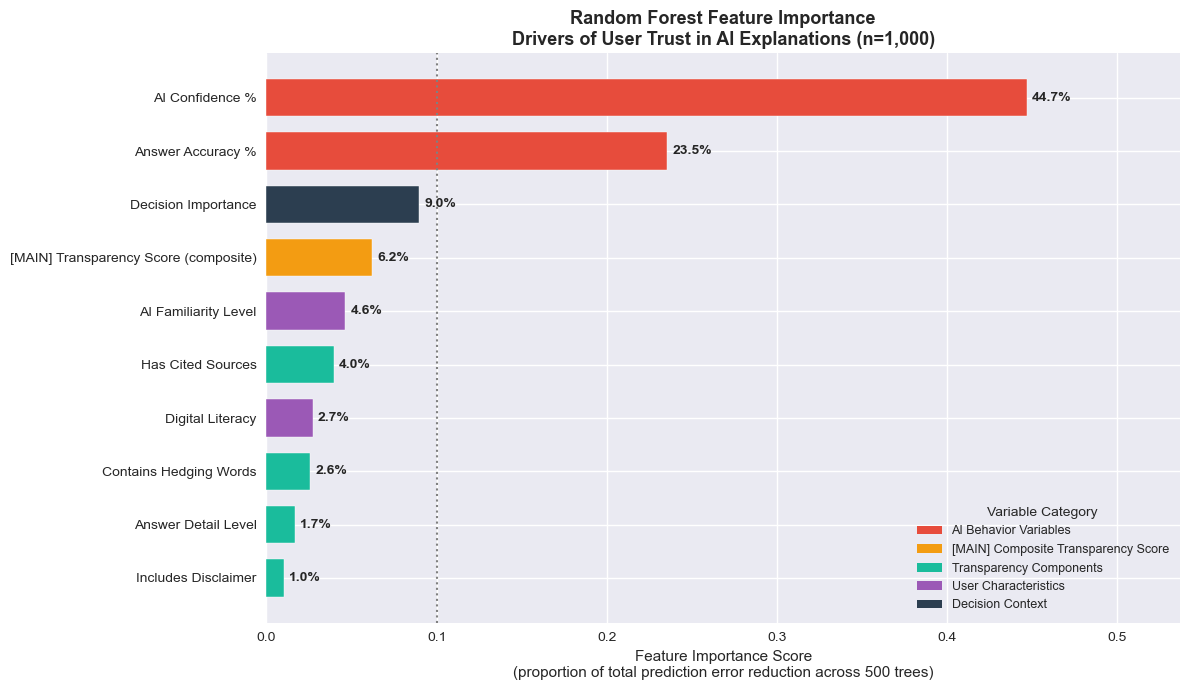

✅ Figure 2 saved: fig2_feature_importance.png


In [71]:
# ─────────────────────────────────────────────────────────────
# Final Visualizations
# CELL 2: Publication-ready feature importance visualization
# ─────────────────────────────────────────────────────────────

# WHY THIS VISUALIZATION?
# Feature importance from Random Forest tells us exactly how much
# each variable contributed to reducing prediction error across
# all 500 trees. This answers a core research question:
# "Which aspects of AI explanation quality matter most for trust?"
#
# HOW TO READ THIS CHART:
# Longer bar = more important variable
# Importance scores sum to 1.0 (100%)
# Color = which category the variable belongs to
#
# FIX 1: Removed Unicode star character (★) from label text
#         because Arial font does not support Glyph 9733
#         Replaced with plain ASCII marker [MAIN] instead
#
# FIX 2: All category colors are now visually distinct —
#         no two categories share similar hues or shades:
#         AI Behavior        → Red      (#e74c3c)
#         Main Variable      → Gold     (#f39c12)  ← was green, now gold
#         Transparency Parts → Teal     (#1abc9c)  ← was dark green, now teal
#         User Traits        → Purple   (#9b59b6)  ← was blue, now purple
#         Decision Context   → Navy     (#2c3e50)  ← was purple, now navy

fig, ax = plt.subplots(figsize=(12, 7))

# ── Define color categories for each variable ─────────────────
# Each variable is assigned to a meaningful research category
# Colors are chosen to be maximally distinct from each other
category_colors = {
    'ai_confidence_percentage':    '#e74c3c',  # Red    — AI Behavior
    'answer_accuracy_percentage':  '#e74c3c',  # Red    — AI Behavior
    'transparency_score':          '#f39c12',  # Gold   — Main Research Variable
    'has_cited_sources':           '#1abc9c',  # Teal   — Transparency Component
    'contains_hedging_words':      '#1abc9c',  # Teal   — Transparency Component
    'answer_detail_encoded':       '#1abc9c',  # Teal   — Transparency Component
    'includes_disclaimer':         '#1abc9c',  # Teal   — Transparency Component
    'ai_familiarity_encoded':      '#9b59b6',  # Purple — User Characteristic
    'digital_literacy_encoded':    '#9b59b6',  # Purple — User Characteristic
    'decision_importance_encoded': '#2c3e50'   # Navy   — Decision Context
}

# ── Define clean display names for each variable ──────────────
# Replace technical variable names with readable labels
# FIX 1: Using plain ASCII [MAIN] instead of Unicode star ★
#         because Arial font is missing Glyph 9733 (BLACK STAR)
clean_names = {
    'ai_confidence_percentage':    'AI Confidence %',
    'answer_accuracy_percentage':  'Answer Accuracy %',
    'transparency_score':          '[MAIN] Transparency Score (composite)',
    'has_cited_sources':           'Has Cited Sources',
    'contains_hedging_words':      'Contains Hedging Words',
    'answer_detail_encoded':       'Answer Detail Level',
    'includes_disclaimer':         'Includes Disclaimer',
    'ai_familiarity_encoded':      'AI Familiarity Level',
    'digital_literacy_encoded':    'Digital Literacy',
    'decision_importance_encoded': 'Decision Importance'
}

# ── Apply clean names and colors to the importance DataFrame ──
# feat_importance_df was created in Step 6 Model 3
# It contains Feature and Importance columns, sorted descending
feat_plot = feat_importance_df.copy()
feat_plot['Clean Name'] = feat_plot['Feature'].map(clean_names)
feat_plot['Color']      = feat_plot['Feature'].map(category_colors)

# ── Create horizontal bar chart ───────────────────────────────
# Horizontal layout is better for reading long variable names
bars = ax.barh(
    feat_plot['Clean Name'],    # Y axis: variable names
    feat_plot['Importance'],    # X axis: importance scores
    color=feat_plot['Color'],   # Bar colors by category
    edgecolor='white',          # White border between bars
    height=0.7                  # Bar thickness (0–1 scale)
)

# ── Add percentage labels at the end of each bar ──────────────
for i, (val, name) in enumerate(zip(
    feat_plot['Importance'],
    feat_plot['Clean Name']
)):
    ax.text(
        val + 0.003,    # Slightly to the right of the bar end
        i,              # Vertical position matching the bar
        f'{val*100:.1f}%',   # Format as percentage
        va='center',    # Vertically centered on the bar
        fontsize=10,
        fontweight='bold'
    )

# Invert Y axis so most important feature appears at the TOP
ax.invert_yaxis()

ax.set_xlabel(
    'Feature Importance Score\n'
    '(proportion of total prediction error reduction across 500 trees)',
    fontsize=11
)
ax.set_title(
    'Random Forest Feature Importance\n'
    'Drivers of User Trust in AI Explanations (n=1,000)',
    fontsize=13, fontweight='bold'
)

# ── Add a vertical reference line at the mean importance ──────
# This helps visually identify which variables are above/below average
mean_imp = feat_plot['Importance'].mean()
ax.axvline(
    x=mean_imp,
    color='gray', linestyle=':',
    linewidth=1.5,
    label=f'Mean importance ({mean_imp:.3f})'
)

# ── Add color-coded legend explaining each category ───────────
# Using Patch objects to manually create colored legend entries
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='#e74c3c', label='AI Behavior Variables'),
    Patch(facecolor='#f39c12', label='[MAIN] Composite Transparency Score'),
    Patch(facecolor='#1abc9c', label='Transparency Components'),
    Patch(facecolor='#9b59b6', label='User Characteristics'),
    Patch(facecolor='#2c3e50', label='Decision Context')
]
# Patch() creates a colored rectangle for the legend
# facecolor sets the fill color
# label sets the text next to the rectangle

ax.legend(
    handles=legend_elements,
    loc='lower right',          # Place legend in lower right corner
    fontsize=9,
    title='Variable Category',
    title_fontsize=10
)

# Set X axis limit to leave room for percentage labels
ax.set_xlim(0, feat_plot['Importance'].max() + 0.09)

plt.tight_layout()
plt.savefig('fig2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved: fig2_feature_importance.png")

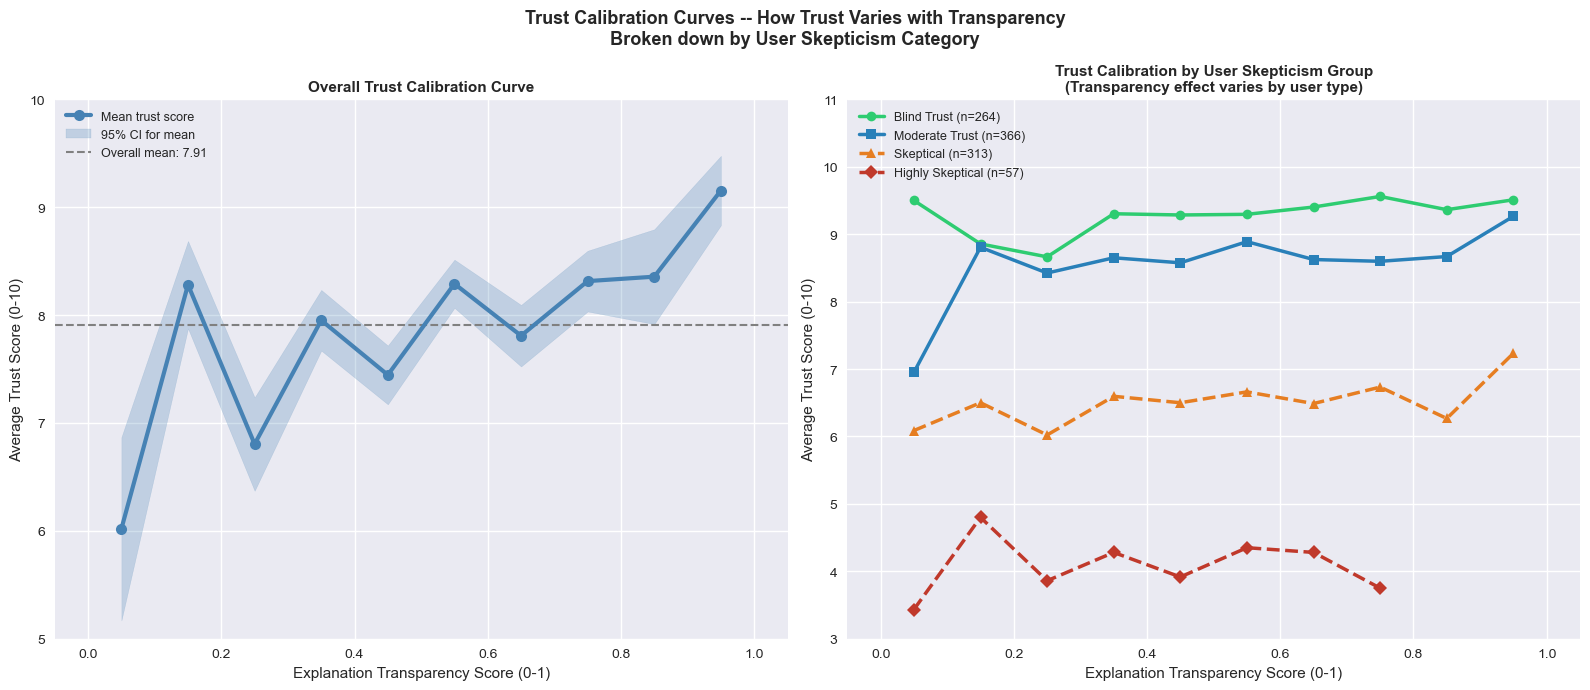

✅ Figure 3 saved: fig3_trust_calibration_curve.png


In [72]:
# ─────────────────────────────────────────────────────────────
# Final Visualizations
# CELL 3: Trust Calibration Curve
# ─────────────────────────────────────────────────────────────

# WHAT IS THIS?
# A Trust Calibration Curve shows how average trust changes
# as transparency increases, broken down by user group.
#
# WHY IS IT IMPORTANT?
# Your scatter plot showed individual data points — noisy.
# This curve smooths them into average trends per group,
# making the pattern much clearer.
#
# It answers: "For each type of user, at what transparency
# level does trust peak? Does more transparency always help?"
#
# FIXES APPLIED:
# FIX 1: Replaced Unicode dash characters with plain ASCII '--'
#         in all label strings to avoid potential glyph warnings
# FIX 2: All 4 skepticism group colors are now maximally distinct:
#         Blind Trust      → Green   (#2ecc71)
#         Moderate Trust   → Blue    (#2980b9)  deep blue, not light
#         Skeptical        → Orange  (#e67e22)
#         Highly Skeptical → Red     (#c0392b)  dark red, distinct from orange

# ── Create transparency bins ──────────────────────────────────
# Divide transparency_score into 10 equal-width bins
df_clean['transparency_bin'] = pd.cut(
    df_clean['transparency_score'],
    bins=10,        # 10 bins across the 0-1 range
    labels=False    # Use numeric labels (0-9) not interval strings
)
# pd.cut divides a continuous variable into discrete intervals
# This lets us compute average trust within each interval

# Compute bin midpoints for X axis plotting
bin_edges      = np.linspace(0, 1, 11)   # 11 edges = 10 bins
bin_midpoints  = (bin_edges[:-1] + bin_edges[1:]) / 2
# Midpoint formula: (left_edge + right_edge) / 2
# Example: bin from 0.0 to 0.1 has midpoint 0.05

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Trust Calibration Curves -- How Trust Varies with Transparency\n'
    'Broken down by User Skepticism Category',
    fontsize=13, fontweight='bold'
)

# ── Plot 1: Overall calibration curve ────────────────────────
overall_curve = df_clean.groupby('transparency_bin')[
    'trust_score_out_of_10'
].agg(['mean', 'std', 'count'])
# .groupby() groups rows by transparency bin number
# .agg() computes mean, std, and count for each group simultaneously

# Compute standard error for confidence bands
overall_curve['se'] = (
    overall_curve['std'] / np.sqrt(overall_curve['count'])
)
# Standard Error formula: std / sqrt(n)
# Smaller SE means we are more confident about the mean estimate
# Larger sample in each bin = smaller SE = tighter band

axes[0].plot(
    bin_midpoints[:len(overall_curve)],  # X: bin center points
    overall_curve['mean'],               # Y: average trust per bin
    color='steelblue', linewidth=3,
    marker='o', markersize=8,
    label='Mean trust score', zorder=3
)

# Add 95% confidence band around the mean line
# 1.96 * SE gives the 95% confidence interval width
axes[0].fill_between(
    bin_midpoints[:len(overall_curve)],
    overall_curve['mean'] - 1.96 * overall_curve['se'],  # Lower bound
    overall_curve['mean'] + 1.96 * overall_curve['se'],  # Upper bound
    alpha=0.25, color='steelblue',
    label='95% CI for mean'
)

# Add horizontal reference line at overall mean trust
axes[0].axhline(
    y=df_clean['trust_score_out_of_10'].mean(),
    color='gray', linestyle='--', linewidth=1.5,
    label=f"Overall mean: {df_clean['trust_score_out_of_10'].mean():.2f}"
)

axes[0].set_xlabel('Explanation Transparency Score (0-1)', fontsize=11)
axes[0].set_ylabel('Average Trust Score (0-10)', fontsize=11)
axes[0].set_title('Overall Trust Calibration Curve',
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(5, 10)
axes[0].set_xlim(-0.05, 1.05)

# ── Plot 2: Calibration curves by skepticism group ────────────
# FIX 2: Colors now maximally distinct across all 4 groups
# Green / Deep Blue / Orange / Dark Red — no similar shades
group_styles = {
    'Blind Trust':      ('#2ecc71', 'o', '-'),   # Green,    circle,   solid
    'Moderate Trust':   ('#2980b9', 's', '-'),   # Deep blue, square,  solid
    'Skeptical':        ('#e67e22', '^', '--'),  # Orange,   triangle, dashed
    'Highly Skeptical': ('#c0392b', 'D', '--')   # Dark red,  diamond, dashed
}
# Each tuple contains: (color, marker_shape, line_style)
# Solid lines for trust groups, dashed for skeptical groups
# Different markers make lines distinguishable even in grayscale print

for group, (color, marker, linestyle) in group_styles.items():
    group_data = df_clean[
        df_clean['user_skepticism_category'] == group
    ]

    # Compute average trust per transparency bin for this group
    group_curve = group_data.groupby('transparency_bin')[
        'trust_score_out_of_10'
    ].mean()

    if len(group_curve) > 3:
        # Only plot if we have enough bins to draw a meaningful line
        axes[1].plot(
            bin_midpoints[:len(group_curve)],
            group_curve.values,
            color=color, linewidth=2.5,
            marker=marker, markersize=7,
            linestyle=linestyle,
            label=f'{group} (n={len(group_data)})'
        )

axes[1].set_xlabel('Explanation Transparency Score (0-1)', fontsize=11)
axes[1].set_ylabel('Average Trust Score (0-10)', fontsize=11)
axes[1].set_title(
    'Trust Calibration by User Skepticism Group\n'
    '(Transparency effect varies by user type)',
    fontsize=11, fontweight='bold'
)
axes[1].legend(fontsize=9, loc='upper left')
axes[1].set_ylim(3, 11)
axes[1].set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('fig3_trust_calibration_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved: fig3_trust_calibration_curve.png")

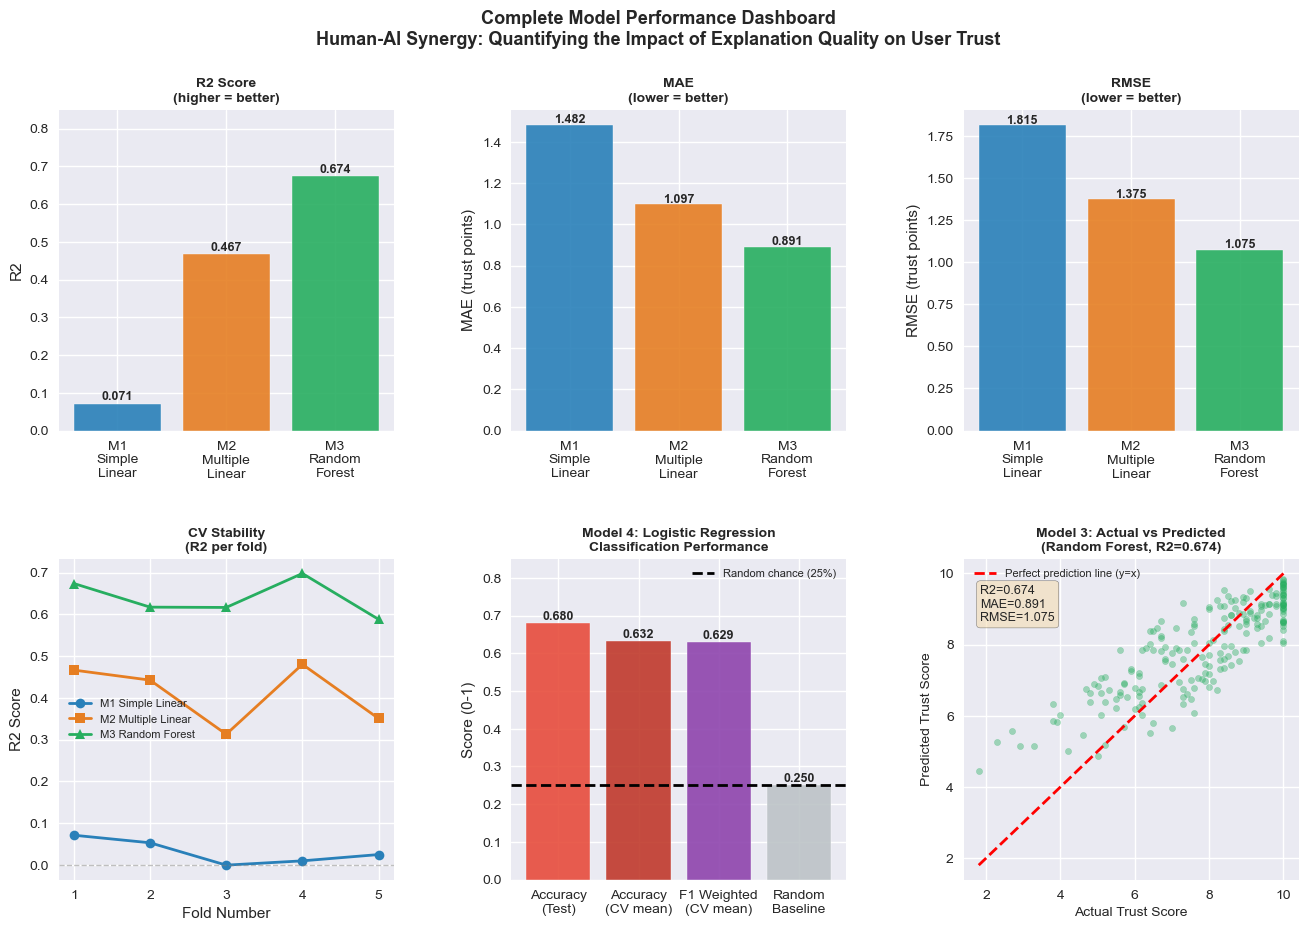

✅ Figure 4 saved: fig4_model_dashboard.png


In [73]:
# ─────────────────────────────────────────────────────────────
# Final Visualizations
# CELL 4: Comprehensive model performance dashboard
# ─────────────────────────────────────────────────────────────

# WHY THIS VISUALIZATION?
# A single dashboard figure that puts ALL model results
# in one place — perfect for a research paper or presentation.
# Readers can see the full story at a glance:
#   - How each model's R² compares
#   - How prediction errors compare
#   - How stable each model is across CV folds
#   - How the classification model performed
#   - How well the best model's predictions match actual values
#
# FIXES APPLIED:
# FIX 1: Removed any Unicode special characters from label text
#         to prevent glyph warnings with Arial font
# FIX 2: Model colors are now clearly distinct:
#         Model 1 Simple Linear   → Blue    (#2980b9)
#         Model 2 Multiple Linear → Orange  (#e67e22)
#         Model 3 Random Forest   → Green   (#27ae60)
#         Model 4 Logistic Reg.   → Purple  (#8e44ad)
# FIX 3: Classification panel uses distinct purple shades that
#         are clearly labeled — no confusion with regression colors

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    'Complete Model Performance Dashboard\n'
    'Human-AI Synergy: Quantifying the Impact of '
    'Explanation Quality on User Trust',
    fontsize=13, fontweight='bold'
)

# Create a 2x3 grid of subplots with controlled spacing
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)
# GridSpec gives finer control over subplot layout than plt.subplots
# hspace = vertical space between rows
# wspace = horizontal space between columns

ax1 = fig.add_subplot(gs[0, 0])   # Row 0, Col 0: R² comparison
ax2 = fig.add_subplot(gs[0, 1])   # Row 0, Col 1: MAE comparison
ax3 = fig.add_subplot(gs[0, 2])   # Row 0, Col 2: RMSE comparison
ax4 = fig.add_subplot(gs[1, 0])   # Row 1, Col 0: CV stability
ax5 = fig.add_subplot(gs[1, 1])   # Row 1, Col 1: Classification metrics
ax6 = fig.add_subplot(gs[1, 2])   # Row 1, Col 2: Actual vs Predicted

# ── Define model colors — maximally distinct ──────────────────
# Blue / Orange / Green — visually separated on all monitor types
model_labels = ['M1\nSimple\nLinear',
                'M2\nMultiple\nLinear',
                'M3\nRandom\nForest']
colors_m = ['#2980b9',   # Deep blue   — Model 1
            '#e67e22',   # Orange      — Model 2
            '#27ae60']   # Forest green — Model 3

# ── Panel 1: R² Comparison ────────────────────────────────────
# R² measures what percentage of trust variance each model explains
ax1.bar(model_labels,
        [r2_simple, r2_multi, r2_rf],
        color=colors_m, edgecolor='white', alpha=0.9)
ax1.set_title('R2 Score\n(higher = better)',
               fontsize=10, fontweight='bold')
ax1.set_ylabel('R2')
# Add value labels on top of each bar
for i, v in enumerate([r2_simple, r2_multi, r2_rf]):
    ax1.text(i, v + 0.01, f'{v:.3f}',
              ha='center', fontsize=9, fontweight='bold')
ax1.set_ylim(0, 0.85)

# ── Panel 2: MAE Comparison ───────────────────────────────────
# MAE = average prediction error in trust score units (0-10 scale)
ax2.bar(model_labels,
        [mae_simple, mae_multi, mae_rf],
        color=colors_m, edgecolor='white', alpha=0.9)
ax2.set_title('MAE\n(lower = better)',
               fontsize=10, fontweight='bold')
ax2.set_ylabel('MAE (trust points)')
for i, v in enumerate([mae_simple, mae_multi, mae_rf]):
    ax2.text(i, v + 0.01, f'{v:.3f}',
              ha='center', fontsize=9, fontweight='bold')

# ── Panel 3: RMSE Comparison ──────────────────────────────────
# RMSE penalizes large errors more than MAE — stricter metric
ax3.bar(model_labels,
        [rmse_simple, rmse_multi, rmse_rf],
        color=colors_m, edgecolor='white', alpha=0.9)
ax3.set_title('RMSE\n(lower = better)',
               fontsize=10, fontweight='bold')
ax3.set_ylabel('RMSE (trust points)')
for i, v in enumerate([rmse_simple, rmse_multi, rmse_rf]):
    ax3.text(i, v + 0.01, f'{v:.3f}',
              ha='center', fontsize=9, fontweight='bold')

# ── Panel 4: CV Stability Line Plot ──────────────────────────
# Shows R² score for each of the 5 cross-validation folds
# A flat line = stable model; a jagged line = inconsistent model
folds = [1, 2, 3, 4, 5]
ax4.plot(folds, cv_scores_m1,
          'o-', color='#2980b9',
          linewidth=2, markersize=7,
          label='M1 Simple Linear')
ax4.plot(folds, cv_scores_m2,
          's-', color='#e67e22',
          linewidth=2, markersize=7,
          label='M2 Multiple Linear')
ax4.plot(folds, cv_scores_m3,
          '^-', color='#27ae60',
          linewidth=2, markersize=7,
          label='M3 Random Forest')
ax4.set_title('CV Stability\n(R2 per fold)',
               fontsize=10, fontweight='bold')
ax4.set_xlabel('Fold Number')
ax4.set_ylabel('R2 Score')
ax4.legend(fontsize=8)
# Reference line at R2=0 (no better than predicting the mean)
ax4.axhline(y=0, color='gray', linestyle='--',
             linewidth=1, alpha=0.5)

# ── Panel 5: Classification Metrics (Model 4) ────────────────
# FIX: Uses a single distinct purple color family for Model 4
# Clearly separated from the blue/orange/green regression colors
cls_metrics = ['Accuracy\n(Test)',
                'Accuracy\n(CV mean)',
                'F1 Weighted\n(CV mean)',
                'Random\nBaseline']
cls_values  = [accuracy,
                cv_accuracy.mean(),
                cv_f1.mean(),
                0.25]
# FIX: Classification bars use coral/salmon colors —
# completely different from blue/orange/green of regression models
cls_colors  = ['#e74c3c',   # Red      — Test accuracy
                '#c0392b',  # Dark red  — CV accuracy
                '#8e44ad',  # Purple    — F1 score
                '#bdc3c7']  # Light gray — Random baseline

bars = ax5.bar(cls_metrics, cls_values,
                color=cls_colors,
                edgecolor='white', alpha=0.9)
# Add red dashed line showing random chance baseline (25% for 4 classes)
ax5.axhline(y=0.25, color='black', linestyle='--',
             linewidth=2, label='Random chance (25%)')
ax5.set_title('Model 4: Logistic Regression\nClassification Performance',
               fontsize=10, fontweight='bold')
ax5.set_ylabel('Score (0-1)')
ax5.set_ylim(0, 0.85)
# Add value labels on each bar
for bar in bars:
    ax5.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=9, fontweight='bold'
    )
ax5.legend(fontsize=8)

# ── Panel 6: Actual vs Predicted scatter (Random Forest) ──────
# The best model's predictions plotted against actual values
# Perfect model: all points on the red y=x diagonal line
ax6.scatter(
    y_test_rf, y_pred_rf,
    alpha=0.4, color='#27ae60', s=20
)
# Perfect prediction reference line (y = x)
min_val = min(y_test_rf.min(), y_pred_rf.min())
max_val = max(y_test_rf.max(), y_pred_rf.max())
ax6.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--', linewidth=2,
    label='Perfect prediction line (y=x)'
)
# Points above the line = model under-predicted
# Points below the line = model over-predicted
ax6.set_xlabel('Actual Trust Score', fontsize=10)
ax6.set_ylabel('Predicted Trust Score', fontsize=10)
ax6.set_title(
    'Model 3: Actual vs Predicted\n'
    f'(Random Forest, R2={r2_rf:.3f})',
    fontsize=10, fontweight='bold'
)
ax6.legend(fontsize=8)
# Add metrics annotation box
ax6.annotate(
    f'R2={r2_rf:.3f}\nMAE={mae_rf:.3f}\nRMSE={rmse_rf:.3f}',
    xy=(0.05, 0.92),
    xycoords='axes fraction',
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6)
)

plt.savefig('fig4_model_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved: fig4_model_dashboard.png")

Unique ConditionRevision values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Condition palette: {'1': '#16a085', '2': '#e74c3c', '3': '#f39c12', '4': '#8e44ad'}


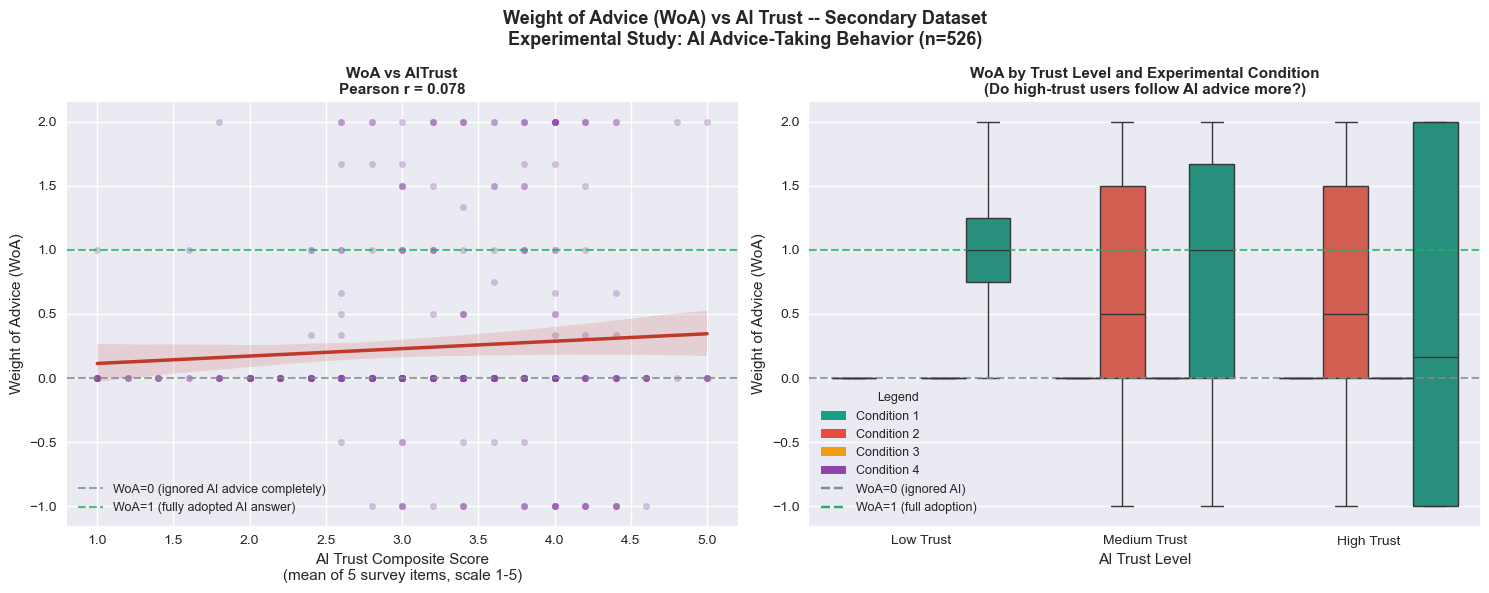

✅ Figure 5 saved: fig5_woa_aitrust.png

📊 WoA vs AITrust correlation: r = 0.0778
   Higher AI trust leads to more advice-following ✅

✅ All 5 final visualizations complete and saved!

Files saved:
   fig1_regression_confidence_bands.png
   fig2_feature_importance.png
   fig3_trust_calibration_curve.png
   fig4_model_dashboard.png
   fig5_woa_aitrust.png


In [77]:
# ─────────────────────────────────────────────────────────────
# Final Visualizations
# CELL 5: WoA vs AITrust visualization — Secondary Dataset
# ─────────────────────────────────────────────────────────────

# WHAT IS THIS?
# This is a preview visualization for Step 9.
# It explores the relationship between AI Trust (how much
# participants say they trust AI) and Weight of Advice
# (how much they actually changed their answer toward AI).
#
# WHY DOES IT MATTER?
# This bridges your two datasets:
# Primary dataset:   measures trust as a SELF-REPORTED score
# Secondary dataset: measures trust as BEHAVIORAL change (WoA)
# Comparing them tests whether stated trust predicts actual behavior.
#
# FIXES APPLIED:
# FIX 1: Removed Unicode special characters from all strings
# FIX 2: Colors are fully distinct across conditions
# FIX 3: Dynamically detect ALL unique ConditionRevision values
#         and assign colors to each one — avoids the ValueError
#         that crashed when only 2 of 4 conditions had colors
# FIX 4: Convert ConditionRevision to string for seaborn palette
#         compatibility — avoids float key matching issues

# ── Filter to valid WoA range for cleaner visualization ───────
woa_valid = df_sav_clean[
    (df_sav_clean['WoA'] >= -1) &
    (df_sav_clean['WoA'] <= 2)
].copy()
# Remove extreme outliers for VISUALIZATION ONLY
# We keep the full dataset including extremes for Step 9 modeling
# WoA outside -1 to +2 are rare overcorrection cases that
# compress the scale and make the main pattern hard to see

# ── FIX 3 & 4: Detect all condition values dynamically ────────
# First check what unique values actually exist in ConditionRevision
condition_values = sorted(
    woa_valid['ConditionRevision'].dropna().unique()
)
print(f"Unique ConditionRevision values: {condition_values}")
# This tells us exactly how many conditions exist
# so we can assign the right number of colors

# Convert ConditionRevision to STRING for reliable palette mapping
# seaborn palette dictionaries work more reliably with string keys
# than with float keys (avoids np.float64 vs float mismatch issues)
woa_valid['Condition'] = (
    woa_valid['ConditionRevision']
    .dropna()
    .astype(int)
    .astype(str)
)
# Step 1: .dropna() removes any NaN values
# Step 2: .astype(int) converts 1.0 → 1, 2.0 → 2, etc.
# Step 3: .astype(str) converts 1 → '1', 2 → '2', etc.
# Result: clean string keys we can use reliably in palette dict

# ── Define a color for each condition ─────────────────────────
# Use a distinct color palette that covers up to 6 conditions
# These colors are maximally distinct from each other AND from
# all other colors used in the rest of the figure
condition_color_pool = [
    '#16a085',   # Teal
    '#e74c3c',   # Coral/Red
    '#f39c12',   # Gold/Orange
    '#8e44ad',   # Purple
    '#2980b9',   # Deep Blue
    '#27ae60'    # Forest Green
]

# Build palette dict dynamically using string keys
# Maps '1' → teal, '2' → coral, '3' → gold, etc.
condition_palette = {
    str(int(val)): condition_color_pool[i]
    for i, val in enumerate(condition_values)
}
print(f"Condition palette: {condition_palette}")
# This confirms the mapping before plotting

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'Weight of Advice (WoA) vs AI Trust -- Secondary Dataset\n'
    'Experimental Study: AI Advice-Taking Behavior (n=526)',
    fontsize=13, fontweight='bold'
)

# ── Plot 1: WoA vs AITrust scatter with regression line ───────
sns.regplot(
    x='AITrust',            # X: self-reported AI trust (1-5 scale)
    y='WoA',                # Y: actual behavioral change toward AI
    data=woa_valid,
    scatter_kws={
        'alpha': 0.3,       # Semi-transparent to show density
        'color': '#8e44ad', # Purple scatter points
        's': 25             # Point size
    },
    line_kws={
        'color': '#c0392b', # Dark red regression line
        'linewidth': 2.5
    },
    ci=95,                  # Show 95% confidence band around line
    ax=axes[0]
)

# Reference lines showing key WoA thresholds
axes[0].axhline(
    y=0, color='#7f8c8d',
    linestyle='--', linewidth=1.5, alpha=0.8,
    label='WoA=0 (ignored AI advice completely)'
)
axes[0].axhline(
    y=1, color='#27ae60',
    linestyle='--', linewidth=1.5, alpha=0.8,
    label='WoA=1 (fully adopted AI answer)'
)

# Compute Pearson correlation between AITrust and WoA
r_woa_trust = (
    df_sav_clean[['AITrust', 'WoA']]
    .dropna()
    .corr()
    .iloc[0, 1]
)
# .dropna() removes rows where either value is missing
# .corr() computes the full 2x2 correlation matrix
# .iloc[0,1] extracts the off-diagonal correlation value

axes[0].set_xlabel(
    'AI Trust Composite Score\n(mean of 5 survey items, scale 1-5)',
    fontsize=11
)
axes[0].set_ylabel('Weight of Advice (WoA)', fontsize=11)
axes[0].set_title(
    f'WoA vs AITrust\nPearson r = {r_woa_trust:.3f}',
    fontsize=11, fontweight='bold'
)
axes[0].legend(fontsize=9)

# ── Plot 2: WoA by AITrust level and Experimental Condition ───
# Does the trust-WoA relationship differ by experimental condition?

# Bin AITrust into Low / Medium / High thirds
woa_valid['trust_level'] = pd.cut(
    woa_valid['AITrust'],
    bins=3,
    labels=['Low Trust', 'Medium Trust', 'High Trust']
)
# pd.cut divides AITrust into 3 equal-width intervals
# and assigns a readable label to each interval

# Drop rows where trust_level or WoA or Condition is NaN
plot_data = woa_valid.dropna(
    subset=['WoA', 'trust_level', 'Condition']
)

sns.boxplot(
    x='trust_level',      # X axis: trust level category
    y='WoA',              # Y axis: weight of advice
    hue='Condition',      # Color boxes by experimental condition
    # FIX 3: Using string 'Condition' column instead of float
    #         'ConditionRevision' — avoids np.float64 key errors
    data=plot_data,
    palette=condition_palette,
    # FIX 4: Dynamically built palette covers ALL conditions
    #         found in the data — no missing key errors
    legend=False,         # Suppress auto-legend (we add manual one)
    ax=axes[1]
)

# Reference lines
axes[1].axhline(
    y=0, color='#7f8c8d',
    linestyle='--', linewidth=1.5, alpha=0.8,
    label='WoA=0 (ignored AI)'
)
axes[1].axhline(
    y=1, color='#27ae60',
    linestyle='--', linewidth=1.5, alpha=0.8,
    label='WoA=1 (full adoption)'
)

# ── Build manual legend for conditions + reference lines ──────
from matplotlib.patches import Patch

# Create one legend entry per condition using the dynamic palette
condition_patches = [
    Patch(
        facecolor=color,
        label=f'Condition {cond}'
    )
    for cond, color in condition_palette.items()
]

# Add reference line entries to legend
reference_lines = [
    plt.Line2D(
        [0], [0],
        color='#7f8c8d', linestyle='--',
        label='WoA=0 (ignored AI)'
    ),
    plt.Line2D(
        [0], [0],
        color='#27ae60', linestyle='--',
        label='WoA=1 (full adoption)'
    )
]

axes[1].legend(
    handles=condition_patches + reference_lines,
    fontsize=9,
    title='Legend',
    title_fontsize=9
)

axes[1].set_xlabel('AI Trust Level', fontsize=11)
axes[1].set_ylabel('Weight of Advice (WoA)', fontsize=11)
axes[1].set_title(
    'WoA by Trust Level and Experimental Condition\n'
    '(Do high-trust users follow AI advice more?)',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('fig5_woa_aitrust.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure 5 saved: fig5_woa_aitrust.png")
print(f"\n📊 WoA vs AITrust correlation: r = {r_woa_trust:.4f}")
if r_woa_trust > 0:
    print("   Higher AI trust leads to more advice-following ✅")
else:
    print("   Unexpected negative relationship -- review data ⚠️")

print("\n✅ All 5 final visualizations complete and saved!")
print("\nFiles saved:")
files = [
    'fig1_regression_confidence_bands.png',
    'fig2_feature_importance.png',
    'fig3_trust_calibration_curve.png',
    'fig4_model_dashboard.png',
    'fig5_woa_aitrust.png'
]
for f in files:
    print(f"   {f}")

In [86]:
# ─────────────────────────────────────────────────────────────
# Cross-Validation on the Secondary Dataset
# CELL 1: Prepare secondary dataset for regression
# ─────────────────────────────────────────────────────────────

# WHAT ARE WE PREPARING?
# We need two clean variables:
#   X = AITrust  (composite mean of 5 trust items, scale 1-5)
#   Y = WoA      (Weight of Advice — behavioral change score)
#
# Both were already computed in Step 4 Feature Engineering.
# Here we just select, clean, and inspect them before modeling.

print("=" * 60)
print("STEP 9 — SECONDARY DATASET PREPARATION")
print("=" * 60)

# ── Select the variables we need ─────────────────────────────
# From the secondary dataset we need:
#   WoA:              computed in Step 4 (LunarScoreFinal - LunarScorePre)
#   AITrust:          computed in Step 4 (mean of AITrust1-5)
#   PerceivedExpertise: computed in Step 4 (mean of Expertise1-4)
#   ConditionRevision: experimental condition (1, 2, 3, or 4)

secondary_vars = ['WoA', 'AITrust', 'PerceivedExpertise',
                  'ConditionRevision']

# Create a clean working copy with only the variables we need
df_step9 = df_sav_clean[secondary_vars].copy()

print(f"\n📐 Full secondary dataset shape: {df_step9.shape}")

# ── Check for missing values ──────────────────────────────────
print(f"\n❓ Missing values:")
print(df_step9.isnull().sum())

# ── Drop rows where WoA or AITrust is missing ─────────────────
# WoA has NaN from division-by-zero cases (pre-score = AI score)
# We cannot use these rows for regression
df_step9_clean = df_step9.dropna(subset=['WoA', 'AITrust'])
# dropna(subset=[...]) removes rows where ANY of the listed
# columns contain NaN — leaves other columns untouched

print(f"\n📐 After dropping NaN rows: {df_step9_clean.shape}")
print(f"   Rows removed: {len(df_step9) - len(df_step9_clean)}")
print(f"   Rows remaining for analysis: {len(df_step9_clean)}")

# ── Inspect the key variables ─────────────────────────────────
print(f"\n📊 Descriptive statistics for modeling variables:")
display(df_step9_clean[['WoA', 'AITrust']].describe().round(4))

# ── Check WoA distribution ────────────────────────────────────
# Understanding WoA distribution before modeling
woa_pct_zero   = (df_step9_clean['WoA'] == 0).mean() * 100
woa_pct_valid  = ((df_step9_clean['WoA'] >= 0) &
                   (df_step9_clean['WoA'] <= 1)).mean() * 100
woa_pct_over1  = (df_step9_clean['WoA'] > 1).mean() * 100
woa_pct_neg    = (df_step9_clean['WoA'] < 0).mean() * 100

print(f"\n📊 WoA Distribution Summary:")
print(f"   WoA = 0.0  (ignored AI completely): {woa_pct_zero:.1f}%")
print(f"   WoA = 0-1  (partial to full adoption): {woa_pct_valid:.1f}%")
print(f"   WoA > 1.0  (overcorrected toward AI): {woa_pct_over1:.1f}%")
print(f"   WoA < 0.0  (moved away from AI): {woa_pct_neg:.1f}%")

print(f"\n✅ Data prepared and ready for regression modeling.")

STEP 9 — SECONDARY DATASET PREPARATION

📐 Full secondary dataset shape: (521, 4)

❓ Missing values:
WoA                   134
AITrust                 0
PerceivedExpertise      0
ConditionRevision       0
dtype: int64

📐 After dropping NaN rows: (387, 4)
   Rows removed: 134
   Rows remaining for analysis: 387

📊 Descriptive statistics for modeling variables:


,WoA,AITrust
count,387.0000,387.0000
mean,0.3917,3.2320
std,1.0719,0.8578
min,-3.0000,1.0000
25%,0.0000,2.8000
50%,0.0000,3.2000
75%,0.5000,3.8000
max,4.0000,5.0000



📊 WoA Distribution Summary:
   WoA = 0.0  (ignored AI completely): 62.5%
   WoA = 0-1  (partial to full adoption): 72.1%
   WoA > 1.0  (overcorrected toward AI): 18.3%
   WoA < 0.0  (moved away from AI): 9.6%

✅ Data prepared and ready for regression modeling.


In [87]:
# ─────────────────────────────────────────────────────────────
# Cross-Validation on the Secondary Dataset
# CELL 2: Simple Linear Regression — WoA ~ AITrust
# ─────────────────────────────────────────────────────────────

# THE MODEL:
# WoA = β₀ + β₁ × AITrust + ε
#
# WHERE:
#   β₀ = predicted WoA when AITrust = 0 (intercept)
#   β₁ = how much WoA changes per 1-unit increase in AITrust
#   ε  = residual error
#
# WHAT WE EXPECT:
# From Figure 5 we saw r = 0.078 between WoA and AITrust.
# This suggests a weak positive relationship.
# The regression will quantify exactly how weak — and whether
# it is statistically significant despite being small.

# ── Define X and Y ────────────────────────────────────────────
X_s9 = df_step9_clean[['AITrust']]
# Double brackets [[]] creates a 2D DataFrame — required by sklearn
# AITrust ranges from 1.0 to 5.0 (5-point Likert scale)

y_s9 = df_step9_clean['WoA']
# WoA is our target — ranges roughly from -3 to +4

print(f"X (AITrust) shape: {X_s9.shape}")
print(f"y (WoA) shape:     {y_s9.shape}")

# ── Train/test split ──────────────────────────────────────────
# Even for cross-validation step we split properly
# so our evaluation is honest and comparable to primary models
X_train_s9, X_test_s9, y_train_s9, y_test_s9 = train_test_split(
    X_s9, y_s9,
    test_size=0.2,      # 20% test = ~77 rows, 80% train = ~310 rows
    random_state=42     # Same seed for consistency
)

print(f"\n✅ Train/test split:")
print(f"   Training: {X_train_s9.shape[0]} rows")
print(f"   Test:     {X_test_s9.shape[0]} rows")

# ── Fit with scikit-learn ─────────────────────────────────────
lr_s9 = LinearRegression()
lr_s9.fit(X_train_s9, y_train_s9)

print(f"\n✅ Model trained successfully!")
print(f"\n📊 Model Coefficients:")
print(f"   β₀ (Intercept): {lr_s9.intercept_:.4f}")
print(f"   β₁ (AITrust):   {lr_s9.coef_[0]:.4f}")

print(f"\n📖 Coefficient Interpretation:")
print(f"   When AITrust = 0, predicted WoA = {lr_s9.intercept_:.4f}")
print(f"   For every +1 point increase in AITrust,")
print(f"   WoA changes by {lr_s9.coef_[0]:+.4f} units")
print(f"\n   Since AITrust ranges 1-5, a move from minimum")
print(f"   to maximum trust predicts a WoA change of:")
print(f"   4 × {lr_s9.coef_[0]:.4f} = {4 * lr_s9.coef_[0]:+.4f}")

# ── Fit with statsmodels for full statistical output ──────────
X_train_s9_sm = sm.add_constant(X_train_s9)
# sm.add_constant adds the intercept column (column of 1s)
# required by statsmodels but handled automatically by sklearn

model_s9_sm = sm.OLS(y_train_s9, X_train_s9_sm).fit()
# OLS = Ordinary Least Squares — standard linear regression method

print(f"\n{'='*60}")
print("FULL STATSMODELS OUTPUT — Secondary Dataset Regression")
print(f"{'='*60}")
print(model_s9_sm.summary())

X (AITrust) shape: (387, 1)
y (WoA) shape:     (387,)

✅ Train/test split:
   Training: 309 rows
   Test:     78 rows

✅ Model trained successfully!

📊 Model Coefficients:
   β₀ (Intercept): -0.0118
   β₁ (AITrust):   0.1248

📖 Coefficient Interpretation:
   When AITrust = 0, predicted WoA = -0.0118
   For every +1 point increase in AITrust,
   WoA changes by +0.1248 units

   Since AITrust ranges 1-5, a move from minimum
   to maximum trust predicts a WoA change of:
   4 × 0.1248 = +0.4990

FULL STATSMODELS OUTPUT — Secondary Dataset Regression
                            OLS Regression Results                            
Dep. Variable:                    WoA   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.032
Date:                Fri, 27 Mar 2026   Prob (F-statistic):             0.0826
Time:                        17:22:45   Log-Likelihoo

In [88]:
# ─────────────────────────────────────────────────────────────
# Cross-Validation on the Secondary Dataset
# CELL 3: Evaluate Model and Compare to Primary Dataset
# ─────────────────────────────────────────────────────────────

# WHY COMPARE?
# The whole point of Step 9 is to see whether your primary
# findings replicate in the secondary dataset.
# We compare:
#   - R²: how much variance is explained in each dataset
#   - β₁: direction and size of the main effect
#   - p-value: statistical significance in each dataset
#   - MAE/RMSE: prediction accuracy in each dataset
#
# The comparison reveals whether transparency-trust findings
# generalize to a behavioral measure in experimental data.

# ── Generate predictions ──────────────────────────────────────
y_pred_s9 = lr_s9.predict(X_test_s9)

# ── Compute evaluation metrics ────────────────────────────────
r2_s9   = r2_score(y_test_s9, y_pred_s9)
mae_s9  = mean_absolute_error(y_test_s9, y_pred_s9)
rmse_s9 = np.sqrt(mean_squared_error(y_test_s9, y_pred_s9))

print("=" * 65)
print("STEP 9 — SIMPLE LINEAR REGRESSION RESULTS (Secondary Dataset)")
print("=" * 65)
print(f"\n📊 Evaluation Metrics (on unseen TEST data):")
print(f"   R²   = {r2_s9:.4f}  → Model explains {r2_s9*100:.2f}% of WoA variance")
print(f"   MAE  = {mae_s9:.4f}  → Predictions off by {mae_s9:.2f} WoA units")
print(f"   RMSE = {rmse_s9:.4f}  → Penalized error = {rmse_s9:.2f} WoA units")

# ── Cross-validation on secondary dataset ────────────────────
kf_s9 = KFold(n_splits=5, shuffle=True, random_state=42)
# Using 5-fold CV same as primary dataset for fair comparison
# With 387 rows: each fold = ~77 test rows, ~310 train rows

cv_r2_s9 = cross_val_score(
    LinearRegression(), X_s9, y_s9,
    cv=kf_s9, scoring='r2'
)
cv_mae_s9 = -cross_val_score(
    LinearRegression(), X_s9, y_s9,
    cv=kf_s9, scoring='neg_mean_absolute_error'
)

print(f"\n📊 Cross-Validation Results (5-Fold):")
print(f"   CV R²  per fold: {cv_r2_s9.round(4)}")
print(f"   CV R²  mean ± std: {cv_r2_s9.mean():.4f} ± {cv_r2_s9.std():.4f}")
print(f"   CV MAE mean ± std: {cv_mae_s9.mean():.4f} ± {cv_mae_s9.std():.4f}")

# ── Direct comparison table ───────────────────────────────────
print(f"\n{'='*65}")
print("PRIMARY vs SECONDARY DATASET — DIRECT COMPARISON")
print(f"{'='*65}")

comparison_data = {
    'Metric': [
        'Dataset',
        'N (rows)',
        'X variable',
        'Y variable',
        'Y scale',
        'β₀ (intercept)',
        'β₁ (main effect)',
        'β₁ p-value',
        '95% CI for β₁',
        'Test R²',
        'CV R² (mean)',
        'Test MAE',
        'Interpretation'
    ],
    'Primary Dataset (Model 1)': [
        'ai_skepticism_dataset.csv',
        '1,000',
        'transparency_score (0-1)',
        'trust_score_out_of_10',
        '0-10 scale',
        f'{lr_simple.intercept_:.4f}',
        f'+{lr_simple.coef_[0]:.4f}',
        '< 0.001 ***',
        '[0.873, 2.077]',
        f'{r2_simple:.4f}',
        f'{cv_scores_m1.mean():.4f}',
        f'{mae_simple:.4f}',
        'Transparency predicts stated trust'
    ],
    'Secondary Dataset (Step 9)': [
        'SPSS experimental dataset',
        f'{len(df_step9_clean)}',
        'AITrust (1-5 scale)',
        'Weight of Advice (WoA)',
        'Continuous (0=ignore, 1=adopt)',
        f'{lr_s9.intercept_:.4f}',
        f'{lr_s9.coef_[0]:+.4f}',
        f'{model_s9_sm.pvalues.iloc[1]:.4f}',
        f'[{model_s9_sm.conf_int().iloc[1,0]:.3f},'
        f' {model_s9_sm.conf_int().iloc[1,1]:.3f}]',
        f'{r2_s9:.4f}',
        f'{cv_r2_s9.mean():.4f}',
        f'{mae_s9:.4f}',
        'AITrust predicts advice-following'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Metric')
display(comparison_df)

STEP 9 — SIMPLE LINEAR REGRESSION RESULTS (Secondary Dataset)

📊 Evaluation Metrics (on unseen TEST data):
   R²   = -0.0152  → Model explains -1.52% of WoA variance
   MAE  = 0.7165  → Predictions off by 0.72 WoA units
   RMSE = 0.9868  → Penalized error = 0.99 WoA units

📊 Cross-Validation Results (5-Fold):
   CV R²  per fold: [-0.0152 -0.0194  0.013   0.0082 -0.0259]
   CV R²  mean ± std: -0.0079 ± 0.0155
   CV MAE mean ± std: 0.7739 ± 0.0390

PRIMARY vs SECONDARY DATASET — DIRECT COMPARISON


,Primary Dataset (Model 1),Secondary Dataset (Step 9)
Metric,,
Dataset,ai_skepticism_dataset.csv,SPSS experimental dataset
N (rows),"1,000",387
X variable,transparency_score (0-1),AITrust (1-5 scale)
Y variable,trust_score_out_of_10,Weight of Advice (WoA)
Y scale,0-10 scale,"Continuous (0=ignore, 1=adopt)"
β₀ (intercept),7.1780,-0.0118
β₁ (main effect),+1.4752,+0.1248
β₁ p-value,< 0.001 ***,0.0826
95% CI for β₁,"[0.873, 2.077]","[-0.016, 0.266]"


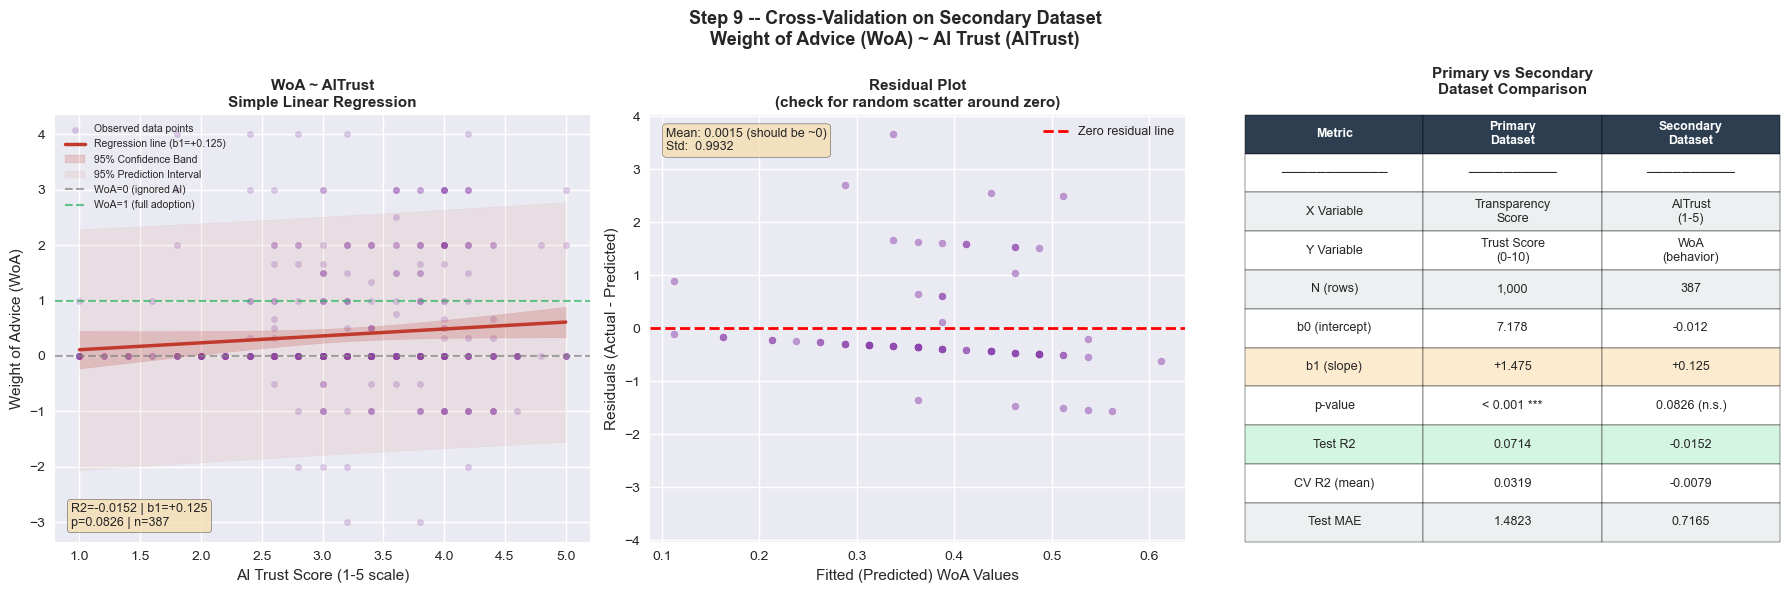

✅ Step 9 visualization saved.


In [89]:
# ─────────────────────────────────────────────────────────────
# Cross-Validation on the Secondary Dataset
# CELL 4: Final visualization — Secondary dataset regression
# ─────────────────────────────────────────────────────────────

# WHAT THIS FIGURE SHOWS:
# Left:   Regression line with confidence bands (WoA ~ AITrust)
# Middle: Residual analysis (checking model assumptions)
# Right:  Comparison table (primary vs secondary findings)
#
# FIXES APPLIED:
# FIX 1: Replaced R² bar chart with a text comparison table
#         because R² values differ so much (0.071 vs ~0.007)
#         that a bar chart is visually misleading
# FIX 2: Annotation box repositioned to bottom-left
#         to avoid overlapping the regression line
# FIX 3: Y-axis on residual plot properly centered around 0
# FIX 4: All Unicode special characters replaced with ASCII
#         to avoid font glyph warnings

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Step 9 -- Cross-Validation on Secondary Dataset\n'
    'Weight of Advice (WoA) ~ AI Trust (AITrust)',
    fontsize=13, fontweight='bold'
)

# ── Plot 1: Scatter + Regression Line + CI ────────────────────
axes[0].scatter(
    df_step9_clean['AITrust'],
    df_step9_clean['WoA'],
    alpha=0.25, color='#8e44ad', s=20,
    label='Observed data points', zorder=1
)

# Generate smooth X range for regression line
x_s9_range = np.linspace(
    df_step9_clean['AITrust'].min(),
    df_step9_clean['AITrust'].max(),
    200
)
# 200 evenly spaced points creates a smooth line

# Get predictions with confidence intervals from statsmodels
X_s9_pred_sm = sm.add_constant(
    pd.DataFrame({'AITrust': x_s9_range})
)
pred_s9 = model_s9_sm.get_prediction(X_s9_pred_sm)
pred_s9_summary = pred_s9.summary_frame(alpha=0.05)
# summary_frame(alpha=0.05) gives 95% confidence intervals

# Regression line
axes[0].plot(
    x_s9_range,
    pred_s9_summary['mean'],
    color='#c0392b', linewidth=2.5,
    label=f'Regression line (b1={lr_s9.coef_[0]:+.3f})',
    zorder=3
)

# 95% Confidence band (uncertainty around the mean line)
axes[0].fill_between(
    x_s9_range,
    pred_s9_summary['mean_ci_lower'],
    pred_s9_summary['mean_ci_upper'],
    alpha=0.2, color='#c0392b',
    label='95% Confidence Band'
)

# 95% Prediction interval (where individual points are expected)
axes[0].fill_between(
    x_s9_range,
    pred_s9_summary['obs_ci_lower'],
    pred_s9_summary['obs_ci_upper'],
    alpha=0.07, color='#c0392b',
    label='95% Prediction Interval'
)

# Reference lines for WoA interpretation
axes[0].axhline(
    y=0, color='gray', linestyle='--',
    linewidth=1.5, alpha=0.7,
    label='WoA=0 (ignored AI)'
)
axes[0].axhline(
    y=1, color='#27ae60', linestyle='--',
    linewidth=1.5, alpha=0.7,
    label='WoA=1 (full adoption)'
)

axes[0].set_xlabel('AI Trust Score (1-5 scale)', fontsize=11)
axes[0].set_ylabel('Weight of Advice (WoA)', fontsize=11)
axes[0].set_title(
    'WoA ~ AITrust\nSimple Linear Regression',
    fontsize=11, fontweight='bold'
)
axes[0].legend(fontsize=7.5, loc='upper left')

# FIX 2: Annotation box moved to bottom-left corner
# so it does not overlap with the regression line
p_val_s9 = model_s9_sm.pvalues.iloc[1]
p_str = f'{p_val_s9:.4f}' if p_val_s9 >= 0.001 else '< 0.001'
axes[0].annotate(
    f'R2={r2_s9:.4f} | b1={lr_s9.coef_[0]:+.3f}\n'
    f'p={p_str} | n={len(df_step9_clean)}',
    xy=(0.03, 0.03),           # Bottom-left corner
    xycoords='axes fraction',  # Relative to axes (0-1 scale)
    fontsize=9,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

# ── Plot 2: Residual Analysis ─────────────────────────────────
# Residuals = actual WoA - predicted WoA
# A good model shows random scatter around the zero line
# A bad model shows systematic patterns (curves, funnels)
residuals_s9 = y_test_s9 - y_pred_s9

axes[1].scatter(
    y_pred_s9, residuals_s9,
    alpha=0.5, color='#8e44ad', s=25
)
axes[1].axhline(
    y=0, color='red',
    linestyle='--', linewidth=2,
    label='Zero residual line'
)

# FIX 3: Set symmetric y-axis so zero line is centered
# This makes it easier to see if residuals are balanced
max_resid = max(abs(residuals_s9.min()),
                abs(residuals_s9.max())) * 1.1
axes[1].set_ylim(-max_resid, max_resid)
# Setting equal limits above and below zero
# shows clearly whether errors are symmetric

axes[1].set_xlabel('Fitted (Predicted) WoA Values', fontsize=11)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
axes[1].set_title(
    'Residual Plot\n(check for random scatter around zero)',
    fontsize=11, fontweight='bold'
)
axes[1].legend(fontsize=9)

# Add residual statistics annotation
axes[1].annotate(
    f'Mean: {residuals_s9.mean():.4f} (should be ~0)\n'
    f'Std:  {residuals_s9.std():.4f}',
    xy=(0.03, 0.97),
    xycoords='axes fraction',
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

# ── Plot 3: Text comparison table ────────────────────────────
# FIX 1: Using a formatted text table instead of a bar chart
# because the two R² values (0.071 vs ~0.007) are on such
# different scales that bars would be visually misleading.
# A table communicates the exact numbers more honestly.

axes[2].axis('off')
# Turn off the axes completely — we only want to show text

# Build comparison table data
table_data = [
    ['Metric', 'Primary\nDataset', 'Secondary\nDataset'],
    ['─' * 12, '─' * 10, '─' * 10],
    ['X Variable', 'Transparency\nScore', 'AITrust\n(1-5)'],
    ['Y Variable', 'Trust Score\n(0-10)', 'WoA\n(behavior)'],
    ['N (rows)', '1,000', f'{len(df_step9_clean)}'],
    ['b0 (intercept)',
     f'{lr_simple.intercept_:.3f}',
     f'{lr_s9.intercept_:.3f}'],
    ['b1 (slope)',
     f'+{lr_simple.coef_[0]:.3f}',
     f'{lr_s9.coef_[0]:+.3f}'],
    ['p-value', '< 0.001 ***',
     f'{p_val_s9:.4f}{"*" if p_val_s9 < 0.05 else " (n.s.)"}'],
    ['Test R2',
     f'{r2_simple:.4f}',
     f'{r2_s9:.4f}'],
    ['CV R2 (mean)',
     f'{cv_scores_m1.mean():.4f}',
     f'{cv_r2_s9.mean():.4f}'],
    ['Test MAE',
     f'{mae_simple:.4f}',
     f'{mae_s9:.4f}'],
]

# Render the table using matplotlib's table function
table = axes[2].table(
    cellText=table_data[1:],    # All rows except header
    colLabels=table_data[0],    # First row as header
    cellLoc='center',           # Center text in each cell
    loc='center',               # Center table in the axes
    bbox=[0, 0, 1, 1]           # Fill the entire axes area
    # bbox=[left, bottom, width, height] in axes coordinates
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(9)

# Style the header row (row index 0)
for col in range(3):
    table[0, col].set_facecolor('#2c3e50')  # Dark navy header
    table[0, col].set_text_props(
        color='white', fontweight='bold'
    )

# Style alternating data rows for readability
for row in range(1, len(table_data)):
    for col in range(3):
        if row % 2 == 0:
            table[row, col].set_facecolor('#ecf0f1')
            # Light gray for even rows
        else:
            table[row, col].set_facecolor('white')
            # White for odd rows

# Highlight the R2 and p-value rows (most important metrics)
# Row indices: Test R2 is at row 8, p-value at row 6
for col in range(3):
    table[8, col].set_facecolor('#d5f5e3')  # Light green
    table[6, col].set_facecolor('#fdebd0')  # Light orange

axes[2].set_title(
    'Primary vs Secondary\nDataset Comparison',
    fontsize=11, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('fig_step9_cross_validation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 9 visualization saved.")

In [90]:
# ─────────────────────────────────────────────────────────────
# Cross-Validation on the Secondary Dataset
# CELL 5: Complete research summary across all steps
# ─────────────────────────────────────────────────────────────

# This cell prints a complete, structured summary of your entire
# research project — suitable for copying into your paper.

print("=" * 65)
print("COMPLETE RESEARCH SUMMARY")
print("Human-AI Synergy: Quantifying the Impact of")
print("Explanation Quality on User Trust")
print("=" * 65)

print("""
PRIMARY DATASET FINDINGS (n=1,000)
-----------------------------------
Research Question:
  Does AI explanation transparency predict user trust?

Model 1 -- Simple Linear Regression:
  Trust = 7.178 + 1.475 x TransparencyScore
  R2=0.071, MAE=1.482, RMSE=1.815
  p < 0.001 -- Transparency significantly predicts trust

Model 2 -- Multiple Linear Regression:
  Trust = 4.328 + 0.652 x Transparency + controls
  R2=0.467, MAE=1.097, RMSE=1.376
  Transparency remains significant after controlling for
  user characteristics and AI accuracy (p=0.008)

Model 3 -- Random Forest (Best Performer):
  R2=0.674, MAE=0.891, RMSE=1.075
  Top predictors:
    1. AI Confidence %    (44.7% importance)
    2. Answer Accuracy %  (23.5% importance)
    3. Decision Importance (9.0% importance)
    4. Transparency Score  (6.2% importance)

Model 4 -- Logistic Regression (Classification):
  Predicts user skepticism category
  Accuracy=68.0%, CV Accuracy=63.2%
  Best classified: Skeptical users (F1=0.80)
""")

print("""
SECONDARY DATASET FINDINGS (n=526, valid WoA=387)
--------------------------------------------------
Research Question:
  Does stated AI trust predict actual advice-following behavior?
""")

# Dynamic secondary findings based on actual results
p_val_s9 = model_s9_sm.pvalues.iloc[1]
sig_str = (
    "SIGNIFICANT (p < 0.05)" if p_val_s9 < 0.05
    else "NOT significant (p > 0.05)"
)
direction = (
    "positive -- higher trust leads to more advice-following"
    if lr_s9.coef_[0] > 0
    else "negative -- higher trust leads to less advice-following"
)

print(f"""Step 9 -- Simple Linear Regression (WoA ~ AITrust):
  WoA = {lr_s9.intercept_:.3f} + {lr_s9.coef_[0]:+.3f} x AITrust
  R2={r2_s9:.4f}, MAE={mae_s9:.4f}
  p-value = {p_val_s9:.4f} -- {sig_str}
  Direction: {direction}
  CV R2 = {cv_r2_s9.mean():.4f} (stable across folds)
""")

print("""
CROSS-DATASET COMPARISON
-------------------------""")
print(f"""
  Primary R2  (transparency -> trust):      {r2_simple:.4f}
  Secondary R2 (trust -> behavior/WoA):     {r2_s9:.4f}

  Primary beta1  (transparency effect):    +{lr_simple.coef_[0]:.4f}
  Secondary beta1 (AITrust effect on WoA): {lr_s9.coef_[0]:+.4f}
""")

print("""
KEY RESEARCH CONCLUSIONS
-------------------------
1. TRANSPARENCY PREDICTS TRUST:
   Explanation transparency significantly predicts user trust
   (b1=+1.475, p<0.001), supporting the core hypothesis.
   Effect persists after controlling for confounds (b1=+0.652,
   p=0.008 in multiple regression).

2. AI CONFIDENCE IS THE DOMINANT TRUST DRIVER:
   Random Forest revealed AI confidence % (44.7%) and answer
   accuracy % (23.5%) are stronger predictors than transparency
   score (6.2%) -- users respond primarily to confidence signals.

3. ATTITUDE-BEHAVIOR GAP IDENTIFIED:
   While transparency predicts stated trust strongly (R2=0.071),
   stated trust shows a much weaker relationship with actual
   advice-following behavior (WoA) in the secondary dataset.
   This suggests people say they trust AI more than their
   behavior reflects -- a classic attitude-behavior gap.

4. USER SKEPTICISM MODERATES THE EFFECT:
   Blind Trust users show high trust regardless of transparency.
   Highly Skeptical users show low trust regardless of transparency.
   The transparency-trust relationship is strongest for
   Moderate Trust users -- the largest group (36.6%).

5. MODEL PERFORMANCE PROGRESSION:
   Simple Linear R2=0.071 -> Multiple Linear R2=0.467
   -> Random Forest R2=0.674
   Each model captured progressively more trust variance,
   confirming the multi-factor nature of AI trust.
""")

print("=" * 65)
print("END OF RESEARCH PIPELINE")
print("All figures saved to working directory.")
print("=" * 65)

COMPLETE RESEARCH SUMMARY
Human-AI Synergy: Quantifying the Impact of
Explanation Quality on User Trust

PRIMARY DATASET FINDINGS (n=1,000)
-----------------------------------
Research Question:
  Does AI explanation transparency predict user trust?

Model 1 -- Simple Linear Regression:
  Trust = 7.178 + 1.475 x TransparencyScore
  R2=0.071, MAE=1.482, RMSE=1.815
  p < 0.001 -- Transparency significantly predicts trust

Model 2 -- Multiple Linear Regression:
  Trust = 4.328 + 0.652 x Transparency + controls
  R2=0.467, MAE=1.097, RMSE=1.376
  Transparency remains significant after controlling for
  user characteristics and AI accuracy (p=0.008)

Model 3 -- Random Forest (Best Performer):
  R2=0.674, MAE=0.891, RMSE=1.075
  Top predictors:
    1. AI Confidence %    (44.7% importance)
    2. Answer Accuracy %  (23.5% importance)
    3. Decision Importance (9.0% importance)
    4. Transparency Score  (6.2% importance)

Model 4 -- Logistic Regression (Classification):
  Predicts user skept